# 2026-09-08 Corrected H$\alpha$ surface density in SF, NSF, and ND regions

## Question

Does the increasing inner **NSF occupancy** reveal emission that was already
present, or is the H$\alpha$ emission itself enhanced/created as galaxies move
through the three infall stages?

This notebook keeps three observables separate in bins of
$\log_{10}\Sigma_\star$ and $R/R_e$:

For category $c\in\{\mathrm{SF},\mathrm{NSF},\mathrm{ND}\}$, these are:

1. usable-area fraction $F_c=N_c/N_{\rm usable}$; and
2. mean H$\alpha$ luminosity surface density within that category,
   $I_c=\sum_{p\in c}\Sigma_{L(\mathrm{H}\alpha),p}/N_c$; and
3. occupancy-weighted H$\alpha$ luminosity surface density per usable area,
   $J_c=F_c I_c=\sum_{p\in c}\Sigma_{L(\mathrm{H}\alpha),p}/N_{\rm usable}$.

Galaxies are the independent units; all stage summaries are
galaxy-equal and uncertainty intervals resample whole galaxies.

> **Treat ND H$\alpha$ as an upper limit.** A Balmer non-detection has no
> defensible Balmer-decrement dust correction, and the pipeline all-spaxel map
> substitutes `max(NOISE, raw Halpha flux)` wherever either Balmer line fails.


## 1. Configuration and inherited provenance

The sample, geometry, exact SF/NSF/ND masks, and strict finite
`SNR_POSTFIT > 25` retained footprint are inherited from
`20260908_check_combined_SF_fraction_categories_by_stage_SNR_postfit.ipynb`.
The source notebooks remain unchanged.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.wcs import WCS
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / "v3tk_v7.6.8"
CATALOG_PATH = PROJECT_ROOT / "mauve_master_wiki_newclass.fits"
GEOMETRY_PATH = PROJECT_ROOT / "MAUVE_effective_radii.csv"

MASS_FILE_PATTERN = "{galid}_spatial_binning_maps_further.fits"
SFR_FILE_PATTERNS = (
    "{galid}_gas_bin_maps_further.fits",
    "{galid}_gas_BIN_maps_further.fits",
)
EW_FILE_PATTERNS = (
    "{galid}_proxy_EW_maps_further.fits",
    "{galid}_proxy_EW_maps.fits",
)
MASK_FILE_PATTERN = "{galid}_mask.fits"
SFH_FILE_PATTERN = "{galid}_sfh_maps.fits"

MASS_HDU = "LOGMASS_SURFACE_DENSITY"
BIN_HDU_MASS = "BINID"
BIN_HDU_GAS = "BIN_ID"
SFR_HDU = "LOGSFR_SURFACE_DENSITY_HII"
# All-spaxel ordinate only; SFR_HDU remains the original SF-selection map.
ALL_SFR_HDU = "LOGSFR_SURFACE_DENSITY"
EW_HDU = "PROXY_EWHA"
HALPHA_SIGMA_OBS_HDU = "HA6562_SIGMA"
HALPHA_SIGMA_CORR_HDU = "HA6562_SIGMA_CORR"
MASK_TABLE_HDU = "MASKFILE"
MASK_COLUMN = "MASK"
SFH_SNR_POSTFIT_HDU = "SNR_POSTFIT"

EW_HA_MIN = 6.0
HALPHA_SIGMA_MAX = 45.0
SFH_SNR_POSTFIT_MIN = 25.0
I_MAX_PRIMARY = 80.0
MIN_VALID_PIXELS_PER_BIN = 50
MIN_SF_PIXELS_PER_BIN = 20
WCS_TOLERANCE_ARCSEC = 0.05

SIGMA_BIN_WIDTH = 0.25
RADIUS_BIN_WIDTH = 0.25
FIXED_RELIABLE_RANGES = {"log_sigma_star": (7.0, 9.5), "radius_re": (0.0, 2.5)}
MASS_CONTOUR_LEVEL = 7.5

mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print("Scope: corrected Halpha luminosity surface density across SF, NSF, and ND in all three infall stages")
print("No additional inclination correction is applied to either surface-density map.")

# Keep category colours fixed across galaxies; these encode categories, not identity.
BALMER_LINES = ("HB4861", "HA6562")
LINE_LABELS = (r"H$\beta$", r"H$\alpha$")
CATEGORY_COLORS = {"SF": "#2166ac", "ND": "#e69f00", "NSF": "#b2182b"}
REASON_LABELS = (
    "BPT: stable non-HII", "BPT: weak/ambiguous/unavailable", "HII SFR unavailable",
    "EW unavailable", "EW <= 6", "Dispersion unavailable", "Dispersion >= 45",
)
REASON_COLORS = ("#b2182b", "#984ea3", "#999999", "#a6cee3", "#33a02c", "#cab2d6", "#e66101")


N_BOOTSTRAP = 10_000
RANDOM_SEED = 42
MIN_SUPPORT_GALAXIES = 3
MIN_SF_PIXELS_FOR_SUPPORT = MIN_SF_PIXELS_PER_BIN
STAGE_COLORS = {
    "pre-peak": "#2166ac",
    "close-to-peak": "#1a9850",
    "post-peak": "#d73027",
}
COMPONENT_COLORS = {
    "occupancy": "#2166ac",
    "survivor_intensity": "#e69f00",
    "total_hii": "#111111",
}


import warnings

COLOR_TABLE_PATH = PROJECT_ROOT / "MAUVE_galaxy_colors.dat"
CATEGORY_ORDER = ("SF", "NSF", "ND")
MIN_CATEGORY_PIXELS_PER_BIN = 20
DIAGNOSTIC_MIN_PIXELS_PER_BIN = 20
DIAGNOSTIC_ORDER = ("log_OIII_Hb", "log_NII_Ha", "log_SII_Ha", "log_OI_Ha", "sigma_Ha")
DIAGNOSTIC_LABELS = {
    "log_OIII_Hb": r"$\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)$",
    "log_NII_Ha": r"$\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$",
    "log_SII_Ha": r"$\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$",
    "log_OI_Ha": r"$\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$",
    "sigma_Ha": r"$\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$]",
}
BPT_LINE_ORDER = ("HA6562", "OIII5006", "NII6583", "SII_SUM")
BPT_LINE_LABELS = {
    "HA6562": r"H$\alpha$",
    "OIII5006": r"[O III]$\lambda5007$",
    "NII6583": r"[N II]$\lambda6583$",
    "SII_SUM": r"[S II]$\lambda\lambda6716,6731$",
}


Project root: /Users/Igniz/Desktop/ICRAR/further
Scope: corrected Halpha luminosity surface density across SF, NSF, and ND in all three infall stages
No additional inclination correction is applied to either surface-density map.


## 2. Exact shared masks and geometry

The inherited partition is

$$
\begin{aligned}
\mathrm{SF} &= \mathrm{valid}\cap\mathrm{finite}(\Sigma_{\rm SFR,HII})
\cap[\mathrm{EW}(\mathrm{H}\alpha)>6\,\AA]
\cap[\sigma_{\mathrm{H}\alpha,\rm intr}<45\,\mathrm{km\,s^{-1}}],\\
\mathrm{ND} &= \mathrm{valid}\cap\neg(\mathrm{H}\alpha\ \mathrm{detected}
\cap\mathrm{H}\beta\ \mathrm{detected}),\\
\mathrm{NSF} &= \mathrm{valid}\cap(\mathrm{H}\alpha\ \mathrm{detected}
\cap\mathrm{H}\beta\ \mathrm{detected})\cap\neg\mathrm{SF}.
\end{aligned}
$$

Detection means raw line `flux/error >= CUT_SN` and `flux >= NOISE`, with the
thresholds read from each gas FITS primary header. These observational
categories are mutually exclusive and exhaustive on the valid disc; NSF is not
a unique physical mechanism.


In [2]:
def normalise_stage_label(value) -> str:
    mapping = {
        1: "pre-peak", 1.0: "pre-peak", "1": "pre-peak",
        2: "close-to-peak", 2.0: "close-to-peak", "2": "close-to-peak",
        3: "post-peak", 3.0: "post-peak", "3": "post-peak",
        "prepeak": "pre-peak", "pre-peak": "pre-peak",
        "close-to-peak": "close-to-peak", "closetopeak": "close-to-peak",
        "near-peak": "close-to-peak", "postpeak": "post-peak", "post-peak": "post-peak",
    }
    key = value if isinstance(value, (int, float)) else str(value).strip().lower().replace(" ", "")
    if key not in mapping:
        raise ValueError(f"Unrecognised RPS/infall stage label: {value!r}")
    return mapping[key]


def first_existing(paths):
    for path in paths:
        for candidate in (path, Path(str(path) + ".gz")):
            if candidate.exists():
                return candidate
    return None


def load_fits_map(path: Path, hdu_name: str, *, return_header: bool = False):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper() for hdu in hdul}
        if hdu_name.upper() not in names:
            raise KeyError(f"{path}: missing HDU {hdu_name}; available={sorted(names)}")
        hdu = hdul[hdu_name]
        data = np.asarray(hdu.data, dtype=float).copy()
        header = hdu.header.copy()
    return (data, header) if return_header else data


def load_ngist_mask(path: Path, shape):
    with fits.open(path, memmap=True) as hdul:
        if MASK_TABLE_HDU not in hdul:
            raise KeyError(f"{path}: missing table HDU {MASK_TABLE_HDU}")
        table = hdul[MASK_TABLE_HDU].data
        if MASK_COLUMN not in table.names:
            raise KeyError(f"{path}: missing mask column {MASK_COLUMN}; available={table.names}")
        flat = np.asarray(table[MASK_COLUMN], dtype=int)
    if flat.size != int(np.prod(shape)):
        raise ValueError(f"{path}: mask length {flat.size} cannot reshape to {shape}")
    return flat.reshape(shape)


def celestial_wcs_separation_arcsec(header_a, header_b, shape):
    wa, wb = WCS(header_a).celestial, WCS(header_b).celestial
    if not wa.has_celestial or not wb.has_celestial:
        return np.inf
    ny, nx = shape
    x = np.array([0, nx - 1, 0, nx - 1, (nx - 1) / 2])
    y = np.array([0, 0, ny - 1, ny - 1, (ny - 1) / 2])
    raa, deca = wa.pixel_to_world_values(x, y)
    rab, decb = wb.pixel_to_world_values(x, y)
    cosd = np.cos(np.deg2rad((deca + decb) / 2))
    return float(np.nanmax(np.hypot((raa - rab) * cosd, deca - decb)) * 3600.0)


def tangent_offsets_arcsec(ra_deg, dec_deg, ra0_deg, dec0_deg):
    ra, dec = np.deg2rad(ra_deg), np.deg2rad(dec_deg)
    ra0, dec0 = np.deg2rad(float(ra0_deg)), np.deg2rad(float(dec0_deg))
    dra = (ra - ra0 + np.pi) % (2 * np.pi) - np.pi
    cosc = np.sin(dec0) * np.sin(dec) + np.cos(dec0) * np.cos(dec) * np.cos(dra)
    with np.errstate(divide="ignore", invalid="ignore"):
        east = np.cos(dec) * np.sin(dra) / cosc
        north = (np.cos(dec0) * np.sin(dec) - np.sin(dec0) * np.cos(dec) * np.cos(dra)) / cosc
    return east * 206264.806247, north * 206264.806247


def calculate_deprojected_radius(shape, header, component_rows: pd.DataFrame):
    # Minimum elliptical R/Re over the physical components of one product.
    wcs = WCS(header).celestial
    if not wcs.has_celestial:
        raise ValueError("No celestial WCS available for radius calculation")
    yy, xx = np.indices(shape, dtype=float)
    ra, dec = wcs.pixel_to_world_values(xx, yy)
    radius = np.full(shape, np.inf, dtype=float)
    for _, component in component_rows.iterrows():
        east, north = tangent_offsets_arcsec(
            ra, dec, component.center_ra_deg, component.center_dec_deg
        )
        pa = np.deg2rad(float(component.pa_deg_east_of_north))
        major = east * np.sin(pa) + north * np.cos(pa)
        minor = east * np.cos(pa) - north * np.sin(pa)
        component_radius = np.sqrt(
            (major / float(component.a_re_arcsec)) ** 2
            + (minor / float(component.b_re_arcsec)) ** 2
        )
        radius = np.minimum(radius, component_radius)
    radius[~np.isfinite(radius)] = np.nan
    return radius


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr):
    sigma2 = np.asarray(sigma_obs, dtype=float) ** 2 - np.asarray(sigma_corr, dtype=float) ** 2
    result = np.full(sigma2.shape, np.nan, dtype=float)
    valid = np.isfinite(sigma2) & (sigma2 > 0)
    result[valid] = np.sqrt(sigma2[valid])
    return result


def load_galaxy_maps(row, geometry):
    mass, mass_header = load_fits_map(row.mass_path, MASS_HDU, return_header=True)
    mass_bin = load_fits_map(row.mass_path, BIN_HDU_MASS)
    gas_bin, gas_header = load_fits_map(row.sfr_path, BIN_HDU_GAS, return_header=True)
    sfr = load_fits_map(row.sfr_path, SFR_HDU)
    ew_ha = load_fits_map(row.ew_path, EW_HDU)
    sigma_obs = load_fits_map(row.sfr_path, HALPHA_SIGMA_OBS_HDU)
    sigma_corr = load_fits_map(row.sfr_path, HALPHA_SIGMA_CORR_HDU)
    snr_postfit = load_fits_map(row.sfh_path, SFH_SNR_POSTFIT_HDU)
    shapes = {a.shape for a in (
        mass, mass_bin, gas_bin, sfr, ew_ha, sigma_obs, sigma_corr, snr_postfit
    )}
    if len(shapes) != 1:
        raise ValueError(f"{row.GALID}: map shape mismatch {sorted(shapes)}")
    wcs_sep = celestial_wcs_separation_arcsec(mass_header, gas_header, mass.shape)
    if not np.isfinite(wcs_sep) or wcs_sep > WCS_TOLERANCE_ARCSEC:
        raise ValueError(f"{row.GALID}: mass/gas WCS mismatch {wcs_sep:.4f} arcsec")
    ngist_mask = load_ngist_mask(row.mask_path, mass.shape)
    components = geometry.loc[geometry.notebook_product_id.eq(row.GALID)].copy()
    radius_re = calculate_deprojected_radius(mass.shape, mass_header, components)
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    valid = (
        np.isfinite(mass) & np.isfinite(gas_bin) & (ngist_mask == 0) & np.isfinite(radius_re)
    )
    sf = (
        valid & np.isfinite(sfr) & np.isfinite(ew_ha) & (ew_ha > EW_HA_MIN)
        & np.isfinite(sigma_intrinsic) & (sigma_intrinsic < HALPHA_SIGMA_MAX)
    )
    maps = {
        "log_sigma_star": mass,
        "log_sigma_sfr": sfr,
        "radius_re": radius_re,
        "snr_postfit": snr_postfit,
        "valid_disc_mask": valid,
        "sf_mask": sf,
        "mass_header": mass_header,
        "wcs_separation_arcsec": wcs_sep,
    }
    return add_detection_categories(maps, row, ew_ha, sigma_intrinsic)


def binned_fraction(values, valid_mask, selected_mask, edges, min_valid=MIN_VALID_PIXELS_PER_BIN):
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
        n_valid = int((valid_mask & in_bin).sum())
        n_selected = int((selected_mask & in_bin).sum())
        rows.append({
            "center": (lo + hi) / 2,
            "N_valid": n_valid,
            "N_SF": n_selected,
            "f_SF": n_selected / n_valid if n_valid >= min_valid else np.nan,
        })
    return pd.DataFrame(rows)


def radial_mass_trends(maps, edges):
    radius = maps["radius_re"]
    mass = maps["log_sigma_star"]
    rows = []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = np.isfinite(radius) & (radius >= lo) & (radius < hi)
        all_pixels = maps["valid_disc_mask"] & in_bin
        sf_pixels = maps["sf_mask"] & in_bin
        n_all, n_sf = int(all_pixels.sum()), int(sf_pixels.sum())
        rows.append({
            "radius_center": (lo + hi) / 2,
            "N_all": n_all,
            "N_SF": n_sf,
            "all_median": np.nanmedian(mass[all_pixels]) if n_all >= MIN_VALID_PIXELS_PER_BIN else np.nan,
            "sf_median": np.nanmedian(mass[sf_pixels]) if n_sf >= MIN_SF_PIXELS_PER_BIN else np.nan,
        })
    return pd.DataFrame(rows)

def add_detection_categories(maps, row, ew_ha, sigma_intrinsic):
    """Use Balmer-only ND and preserve the original SF selection exactly."""
    valid, sf = maps["valid_disc_mask"], maps["sf_mask"]
    detected = {}
    invalid_any = np.zeros(valid.shape, dtype=bool)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header
        sn_cut, flux_floor = float(header["CUT_SN"]), float(header["NOISE"])
        if not (np.isfinite(sn_cut) and sn_cut > 0 and np.isfinite(flux_floor) and flux_floor > 0):
            raise ValueError(f"{row.GALID}: invalid detection thresholds")
        if str(header["BPTMODE"]).strip().lower() != "both":
            raise ValueError(f"{row.GALID}: expected the original both-BPT selection")
        for line in BALMER_LINES:
            flux = np.asarray(hdul[line + "_FLUX"].data, dtype=float)
            error = np.asarray(hdul[line + "_FLUX_ERR"].data, dtype=float)
            if flux.shape != valid.shape or error.shape != valid.shape:
                raise ValueError(f"{row.GALID}: {line} shape mismatch")
            measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
            invalid_any |= ~measurable
            with np.errstate(divide="ignore", invalid="ignore"):
                detected[line] = measurable & (flux / error >= sn_cut) & (flux >= flux_floor)
        # Do not use the old NII_HA_BPT / SII_HA_BPT ratio HDUs as class maps.
        nii = np.asarray(hdul["NII_BPT"].data).copy()
        sii = np.asarray(hdul["SII_BPT"].data).copy()
        for name, arr in (("NII_BPT", nii), ("SII_BPT", sii)):
            if arr.shape != valid.shape or not np.isin(arr[valid], [-1, 0, 1, 2, 3]).all():
                raise ValueError(f"{row.GALID}: invalid {name} class map")
        provenance = {key: header.get(key, "not recorded")
                      for key in ("CUT_SN", "NOISE", "BPTMODE", "BPTLIMIT", "DUSTLAW")}
    balmer_detected = detected["HA6562"] & detected["HB4861"]
    if np.any(sf & ~balmer_detected):
        raise AssertionError(f"{row.GALID}: original SF includes a Balmer non-detection")
    nd = valid & ~balmer_detected
    nsf = valid & balmer_detected & ~sf
    # Exclusive bookkeeping, in this order: HII gate -> EW gate -> sigma gate.
    # This is a first-failed-gate decomposition, not a unique physical cause.
    has_sfr = np.isfinite(maps["log_sigma_sfr"])
    stable_non_hii = np.isin(nii, [2, 3]) | np.isin(sii, [2, 3])
    both_hii = (nii == 1) & (sii == 1)
    conditions = (
        ~has_sfr & stable_non_hii,
        ~has_sfr & ~both_hii,
        ~has_sfr,
        ~np.isfinite(ew_ha),
        ew_ha <= EW_HA_MIN,
        ~np.isfinite(sigma_intrinsic),
        sigma_intrinsic >= HALPHA_SIGMA_MAX,
    )
    remainder = nsf.copy()
    reasons = {}
    for label, condition in zip(REASON_LABELS, conditions):
        reasons[label] = remainder & condition
        remainder &= ~condition
    if remainder.any():
        raise AssertionError(f"{row.GALID}: unexplained detected non-SF pixels")
    category_sum = sf.astype(np.int8) + nd + nsf
    assert np.array_equal(category_sum, valid.astype(np.int8))
    assert np.array_equal(np.sum(list(reasons.values()), axis=0), nsf.astype(int))
    maps.update({
        "nd_mask": nd, "nsf_mask": nsf, "balmer_detected_mask": balmer_detected,
        "line_detected": detected, "nsf_reasons": reasons,
        "nd_invalid_mask": nd & invalid_any,
        "nd_measured_below_cut_mask": nd & ~invalid_any,
        "detection_provenance": provenance,
    })
    return maps


def binned_categories(values, maps, edges):
    result = binned_fraction(values, maps["valid_disc_mask"], maps["sf_mask"], edges)
    for label, key in (("ND", "nd_mask"), ("NSF", "nsf_mask")):
        extra = binned_fraction(values, maps["valid_disc_mask"], maps[key], edges)
        result["N_" + label] = extra.N_SF
        result["f_" + label] = extra.f_SF
    assert np.array_equal(result.N_SF + result.N_ND + result.N_NSF, result.N_valid)
    shown = result.N_valid >= MIN_VALID_PIXELS_PER_BIN
    assert np.allclose(result.loc[shown, ["f_SF", "f_ND", "f_NSF"]].sum(axis=1), 1)
    assert int(result.N_valid.sum()) == int(maps["valid_disc_mask"].sum())
    return result


def plot_category_fractions(axis, table):
    for label, linestyle in (("SF", "-"), ("ND", "--"), ("NSF", "-.")):
        axis.plot(table.center, table["f_" + label], marker="o", ms=3, lw=1.8,
                  ls=linestyle, color=CATEGORY_COLORS[label], label=r"$f_{\rm " + label + "}$")
    axis.legend(fontsize=8, ncol=3, loc="best")


## 3. Live three-stage sample and product QC

The same primary-sample cut ($i<80^\circ$), combined-system handling, WCS test,
and dynamic product discovery are rerun against the live tree.


In [3]:
def read_master_catalogue(path):
    with fits.open(path) as hdul:
        table = hdul[1].data
        frame = pd.DataFrame({
            "galaxy": [str(value).strip() for value in table["Galaxy"]],
            "logMstar": np.asarray(table["logMstar"], dtype=float),
            "stage_code": np.asarray(table["class"], dtype=float),
        })
    frame["stage"] = frame.stage_code.map(normalise_stage_label)
    return frame


def discover_products(data_root):
    rows = []
    for folder in sorted(path for path in data_root.iterdir()
                         if path.is_dir() and not path.name.endswith("_logs")):
        galid = folder.name
        rows.append({
            "GALID": galid,
            "mass_path": folder / MASS_FILE_PATTERN.format(galid=galid),
            "sfr_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in SFR_FILE_PATTERNS
            ]),
            "ew_path": first_existing([
                folder / pattern.format(galid=galid) for pattern in EW_FILE_PATTERNS
            ]),
            "mask_path": folder / MASK_FILE_PATTERN.format(galid=galid),
            "sfh_path": first_existing([
                folder / SFH_FILE_PATTERN.format(galid=galid)
            ]),
        })
    return pd.DataFrame(rows)


STAGE_ORDER = ("pre-peak", "close-to-peak", "post-peak")
PANEL_ORDER = STAGE_ORDER + ("all stages",)
STAGE_LABELS = {
    "pre-peak": "Pre-peak",
    "close-to-peak": "Close-to-peak",
    "post-peak": "Post-peak",
    "all stages": "All stages",
}

master = read_master_catalogue(CATALOG_PATH)
geometry = pd.read_csv(GEOMETRY_PATH)
required_geometry = {
    "galaxy", "notebook_product_id", "mauve_infall_stage", "center_ra_deg",
    "center_dec_deg", "inclination_deg", "pa_deg_east_of_north",
    "a_re_arcsec", "b_re_arcsec",
}
missing_geometry = required_geometry - set(geometry.columns)
if missing_geometry:
    raise KeyError(f"{GEOMETRY_PATH}: missing columns {sorted(missing_geometry)}")

geometry = geometry.merge(
    master[["galaxy", "logMstar", "stage"]], on="galaxy", how="left",
    validate="one_to_one",
)
geometry["stage_from_geometry"] = geometry.mauve_infall_stage.map(normalise_stage_label)
if not geometry.stage.eq(geometry.stage_from_geometry).all():
    raise RuntimeError("Stage disagreement between the master and effective-radius catalogues")

product_meta = []
for galid, group in geometry.groupby("notebook_product_id", sort=False):
    if group.stage.nunique() != 1:
        raise RuntimeError(f"{galid}: physical components have inconsistent stages")
    product_meta.append({
        "GALID": galid,
        "components": ",".join(group.galaxy),
        "stage": group.stage.iloc[0],
        "inclination": float(group.inclination_deg.max()),
    })

inventory = pd.DataFrame(product_meta).merge(
    discover_products(DATA_ROOT), on="GALID", how="left", validate="one_to_one"
)
candidates = inventory.loc[
    inventory.stage.isin(STAGE_ORDER) & inventory.inclination.lt(I_MAX_PRIMARY)
].sort_values(["stage", "GALID"]).reset_index(drop=True)

# This first pass performs full live QC and records only range/count summaries.
# Maps are not cached so the combined notebook does not retain all galaxies in memory.
qc_rows = []
for row in candidates.itertuples(index=False):
    flags = []
    for label, path in (("mass", row.mass_path), ("sfr", row.sfr_path),
                        ("ew", row.ew_path), ("mask", row.mask_path),
                        ("sfh", row.sfh_path)):
        if not isinstance(path, Path) or not path.exists():
            flags.append(f"missing_{label}_product")
    maps = None
    if not flags:
        try:
            maps = load_galaxy_maps(row, geometry)
            valid = maps["valid_disc_mask"]
            if np.any(maps["sf_mask"] & ~valid):
                flags.append("sf_not_subset_of_valid")
        except Exception as exc:
            flags.append(f"load_error:{type(exc).__name__}:{exc}")
    if maps is not None and not flags:
        valid = maps["valid_disc_mask"]
        category_total = (
            maps["sf_mask"].astype(np.int8)
            + maps["nd_mask"].astype(np.int8)
            + maps["nsf_mask"].astype(np.int8)
        )
        if not np.array_equal(category_total, valid.astype(np.int8)):
            flags.append("category_accounting_failure")
    qc_rows.append({
        "GALID": row.GALID,
        "components": row.components,
        "stage": row.stage,
        "inclination_deg": row.inclination,
        "N_valid": int(valid.sum()) if maps is not None and not flags else 0,
        "N_SF": int(maps["sf_mask"].sum()) if maps is not None and not flags else 0,
        "sigma_min": float(np.nanmin(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "sigma_max": float(np.nanmax(maps["log_sigma_star"][valid]))
                     if maps is not None and not flags else np.nan,
        "radius_min": float(np.nanmin(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "radius_max": float(np.nanmax(maps["radius_re"][valid]))
                      if maps is not None and not flags else np.nan,
        "wcs_separation_arcsec": maps["wcs_separation_arcsec"]
                                if maps is not None and not flags else np.nan,
        "QC_flag": ";".join(flags) if flags else "OK",
    })
    del maps

SAMPLE_QC = pd.DataFrame(qc_rows)
passed_ids = set(SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK"), "GALID"])
sample = candidates.loc[candidates.GALID.isin(passed_ids)].copy()

display(SAMPLE_QC)
display(SAMPLE_QC.groupby(["stage", "QC_flag"], observed=True).size().rename("N_galaxies"))
for stage in STAGE_ORDER:
    n_pass = int(sample.stage.eq(stage).sum())
    n_candidate = int(candidates.stage.eq(stage).sum())
    print(f"{STAGE_LABELS[stage]}: {n_pass}/{n_candidate} products pass QC")
    if n_pass == 0:
        raise RuntimeError(f"No {stage} galaxies passed the live product QC")
print(f"Total passing products: {len(sample)}/{len(candidates)}")


,GALID,components,stage,inclination_deg,N_valid,N_SF,sigma_min,sigma_max,radius_min,radius_max,wcs_separation_arcsec,QC_flag
0,NGC4298,NGC4298,close-to-peak,52.0,498540,144157,6.476232,9.372817,0.002597,2.927309,0.0,OK
1,NGC4424,NGC4424,close-to-peak,61.0,172561,8994,7.113861,9.027295,0.002721,2.533259,0.0,OK
2,NGC4501,NGC4501,close-to-peak,65.0,664236,251936,6.926827,10.916401,0.002436,2.862775,0.0,OK
3,NGC4654,NGC4654,close-to-peak,61.0,659231,345036,6.043689,9.750619,0.000637,2.836630,0.0,OK
4,NGC4694,NGC4694,close-to-peak,62.0,94538,1058,6.934593,9.479634,0.004544,3.796772,0.0,OK
5,IC3392,IC3392,post-peak,68.0,94575,13897,6.969276,9.253759,0.004326,3.084733,0.0,OK
6,NGC4064,NGC4064,post-peak,70.0,179882,3273,6.811374,9.428892,0.002945,1.939061,0.0,OK
7,NGC4293,NGC4293,post-peak,67.0,261523,471,7.243091,10.336573,0.001645,1.842599,0.0,OK
8,NGC4380,NGC4380,post-peak,61.0,502065,64097,6.694095,10.141226,0.001755,2.963534,0.0,OK
9,NGC4394,NGC4394,post-peak,32.0,180654,31915,7.352380,10.783341,0.001999,1.488715,0.0,OK


stage          QC_flag                                                                                             
close-to-peak  OK                                                                                                       5
post-peak      OK                                                                                                      13
               missing_mass_product;missing_sfr_product;missing_ew_product;missing_mask_product;missing_sfh_product     3
pre-peak       OK                                                                                                       8
Name: N_galaxies, dtype: int64

Pre-peak: 8/8 products pass QC
Close-to-peak: 5/5 products pass QC
Post-peak: 13/16 products pass QC
Total passing products: 26/29


## 4. H$\alpha$ luminosity surface density and diagnostic maps

The pipeline uses

$$
\Sigma_{L(\mathrm{H}\alpha)}
=\frac{\Sigma_{\rm SFR,H\alpha}}{C_{\rm H\alpha}},\qquad
C_{\rm H\alpha}=\mathrm{SFRCOEF},
$$

so that

$$
\log_{10}\Sigma_{L(\mathrm{H}\alpha)}
=\mathrm{LOGSFR\_SURFACE\_DENSITY}-\log_{10}(C_{\rm H\alpha}),
$$

in erg s$^{-1}$ kpc$^{-2}$. This is only a unit conversion: no H$\alpha$
luminosity is interpreted as star formation in NSF. For SF/NSF, both Balmer
lines are detected and the ordinate uses the Calzetti Balmer-decrement
correction. For ND, the same stored all-spaxel ordinate is retained.

The supporting line ratios use dust-corrected fluxes but require the raw
pipeline detection threshold for every numerator and denominator line; both
[S II] lines must pass. These diagnostics are supplementary because BPT,
EW(H$\alpha$), and H$\alpha$ dispersion participate in the SF/NSF selection.


In [4]:
def read_galaxy_colors(path):
    colors = {}
    for raw in path.read_text().splitlines():
        line = raw.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split()
        if parts[0].isdigit() or parts[0] == "alias":
            colors[parts[1]] = parts[3]
    return colors


GALAXY_COLORS = read_galaxy_colors(COLOR_TABLE_PATH)


def raw_line_detected(flux, error, cut_sn, noise):
    measurable = np.isfinite(flux) & np.isfinite(error) & (error > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        return measurable & (flux / error >= cut_sn) & (flux >= noise)


def safe_log_ratio(numerator, denominator, usable):
    result = np.full(np.asarray(numerator).shape, np.nan, dtype=float)
    good = usable & np.isfinite(numerator) & np.isfinite(denominator)
    good &= (numerator > 0) & (denominator > 0)
    with np.errstate(divide="ignore", invalid="ignore"):
        result[good] = np.log10(numerator[good] / denominator[good])
    return result


def bpt_line_surface_densities(log_lha_surface, corrected, common_valid):
    ha_corrected = np.asarray(corrected["HA6562"], dtype=float)
    line_fluxes = {
        "HA6562": ha_corrected,
        "OIII5006": np.asarray(corrected["OIII5006"], dtype=float),
        "NII6583": np.asarray(corrected["NII6583"], dtype=float),
        "SII_SUM": (
            np.asarray(corrected["SII6716"], dtype=float)
            + np.asarray(corrected["SII6730"], dtype=float)
        ),
    }
    result = {}
    for line, flux in line_fluxes.items():
        values = np.full(np.asarray(log_lha_surface).shape, np.nan, dtype=float)
        good = (
            np.asarray(common_valid, dtype=bool)
            & np.isfinite(log_lha_surface) & np.isfinite(ha_corrected)
            & np.isfinite(flux) & (ha_corrected > 0) & (flux > 0)
        )
        values[good] = (
            np.asarray(log_lha_surface)[good]
            + np.log10(flux[good] / ha_corrected[good])
        )
        result[line] = values
    return result


def load_halpha_category_maps(row, geometry):
    maps = load_galaxy_maps(row, geometry)
    with fits.open(row.sfr_path, memmap=True) as hdul:
        header = hdul[0].header.copy()
        cut_sn = float(header["CUT_SN"])
        noise = float(header["NOISE"])
        sfrcoef = float(header["SFRCOEF"])
        if not (np.isfinite(sfrcoef) and sfrcoef > 0):
            raise ValueError(f"{row.GALID}: invalid SFRCOEF={sfrcoef}")

        def arr(name):
            return np.asarray(hdul[name].data, dtype=float).copy()

        raw = {}
        raw_err = {}
        corrected = {}
        for line in ("HA6562", "HB4861", "OIII5006", "NII6583", "SII6716", "SII6730", "OI6300"):
            raw[line] = arr(line + "_FLUX")
            raw_err[line] = arr(line + "_FLUX_ERR")
            corrected[line] = arr(line + "_FLUX_CORR")
        log_sigma_sfr_all = arr("LOGSFR_SURFACE_DENSITY")
        sigma_obs = arr(HALPHA_SIGMA_OBS_HDU)
        sigma_corr = arr(HALPHA_SIGMA_CORR_HDU)
        ew_ha = load_fits_map(row.ew_path, EW_HDU)

        provenance = {
            key: header.get(key, "not recorded")
            for key in (
                "CUT_SN", "NOISE", "DIST_MPC", "DISTREF", "SFRCOEF",
                "SFRIMF", "DUSTLAW", "BPTMODE", "SFRNOTE",
            )
        }

    shapes = {value.shape for value in [
        *raw.values(), *raw_err.values(), *corrected.values(),
        log_sigma_sfr_all, sigma_obs, sigma_corr, ew_ha,
    ]}
    if shapes != {maps["valid_disc_mask"].shape}:
        raise ValueError(f"{row.GALID}: added-map shape mismatch {sorted(shapes)}")

    detected = {
        line: raw_line_detected(raw[line], raw_err[line], cut_sn, noise)
        for line in raw
    }
    if not np.array_equal(detected["HA6562"], maps["line_detected"]["HA6562"]):
        raise AssertionError(f"{row.GALID}: inherited Halpha detection mismatch")
    if not np.array_equal(detected["HB4861"], maps["line_detected"]["HB4861"]):
        raise AssertionError(f"{row.GALID}: inherited Hbeta detection mismatch")

    balmer = detected["HA6562"] & detected["HB4861"]
    oiii_ok = detected["OIII5006"] & detected["HB4861"]
    nii_ok = balmer & detected["NII6583"]
    sii_ok = balmer & detected["SII6716"] & detected["SII6730"]
    oi_ok = balmer & detected["OI6300"]
    bpt_common_valid = (
        detected["HA6562"] & detected["HB4861"]
        & detected["OIII5006"] & detected["NII6583"]
        & detected["SII6716"] & detected["SII6730"]
    )
    sigma_intrinsic = intrinsic_sigma_from_maps(sigma_obs, sigma_corr)
    log_lha_surface = log_sigma_sfr_all - np.log10(sfrcoef)
    log_bpt_line_surface = bpt_line_surface_densities(
        log_lha_surface, corrected, bpt_common_valid
    )

    maps.update({
        "log_lha_surface": log_lha_surface,
        "ew_ha": ew_ha,
        "sigma_intrinsic": sigma_intrinsic,
        "bpt_common_valid": bpt_common_valid,
        "log_bpt_line_surface": log_bpt_line_surface,
        "diagnostics": {
            "log_OIII_Hb": safe_log_ratio(
                corrected["OIII5006"], corrected["HB4861"], oiii_ok
            ),
            "log_NII_Ha": safe_log_ratio(
                corrected["NII6583"], corrected["HA6562"], nii_ok
            ),
            "log_SII_Ha": safe_log_ratio(
                corrected["SII6716"] + corrected["SII6730"],
                corrected["HA6562"], sii_ok,
            ),
            "log_OI_Ha": safe_log_ratio(
                corrected["OI6300"], corrected["HA6562"], oi_ok
            ),
            "sigma_Ha": sigma_intrinsic,
        },
        "diagnostic_valid": {
            "log_OIII_Hb": oiii_ok,
            "log_NII_Ha": nii_ok,
            "log_SII_Ha": sii_ok,
            "log_OI_Ha": oi_ok,
            "sigma_Ha": np.isfinite(sigma_intrinsic),
        },
        "halpha_provenance": provenance,
        "sfrcoef": sfrcoef,
    })
    measured = maps["sf_mask"] | maps["nsf_mask"]
    if np.any(measured & ~balmer):
        raise AssertionError(f"{row.GALID}: SF/NSF includes a Balmer non-detection")
    if np.any(measured & ~np.isfinite(log_lha_surface)):
        raise AssertionError(f"{row.GALID}: measured category lacks corrected Halpha")
    return maps


print(f"Loaded {len(GALAXY_COLORS)} persisted galaxy colours.")


Loaded 41 persisted galaxy colours.


## 5. Per-galaxy measurements in common bins

For galaxy $g$, bin $b$, and category $c$:

$$
F_{gcb}=\frac{N_{gcb}}{N_{gub}},\qquad
I_{gcb}=\frac{\sum_{i\in(g,c,b)}\Sigma_{L(\mathrm{H}\alpha),i}}
{N_{gcb}}.
$$

$u$ denotes the strict-S/N retained usable footprint. $I$ is the direct
linear mean within the selected category region.
The stored per-galaxy median of $\log\Sigma_{L(\mathrm{H}\alpha)}$ is an
additional robust check. A usable bin requires 50 pixels; category intensity
support requires 20 category pixels.


In [5]:
def complete_common_edges(minimum, maximum, width, *, lower_limit=None):
    minimum, maximum, width = float(minimum), float(maximum), float(width)
    start = float(lower_limit) if lower_limit is not None else np.floor(minimum / width) * width
    stop = (np.floor(maximum / width) + 1.0) * width
    edges = np.arange(start, stop + 0.5 * width, width)
    if not (edges[0] <= minimum and edges[-1] > maximum):
        raise AssertionError("Common edges do not enclose the live valid range")
    return edges


passing_qc = SAMPLE_QC.loc[SAMPLE_QC.QC_flag.eq("OK")]
COMMON_EDGES = {
    "log_sigma_star": complete_common_edges(
        passing_qc.sigma_min.min(), passing_qc.sigma_max.max(), SIGMA_BIN_WIDTH
    ),
    "radius_re": complete_common_edges(
        passing_qc.radius_min.min(), passing_qc.radius_max.max(),
        RADIUS_BIN_WIDTH, lower_limit=0.0,
    ),
}
VARIABLE_LABELS = {
    "log_sigma_star": r"$\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$",
    "radius_re": r"$R/R_e$",
}
MASK_KEYS = {"SF": "sf_mask", "NSF": "nsf_mask", "ND": "nd_mask"}

measurement_rows = []
snr_rows = []
provenance_rows = []
all_retained_strict = True
for galaxy_row in sample.itertuples(index=False):
    maps = load_halpha_category_maps(galaxy_row, geometry)
    original_valid = maps["valid_disc_mask"]
    snr_postfit = maps["snr_postfit"]
    keep = original_valid & np.isfinite(snr_postfit) & (snr_postfit > SFH_SNR_POSTFIT_MIN)
    all_retained_strict &= bool(np.all(snr_postfit[keep] > SFH_SNR_POSTFIT_MIN))
    category_masks = {label: maps[key] & keep for label, key in MASK_KEYS.items()}
    category_total = sum(mask.astype(np.int8) for mask in category_masks.values())
    if not np.array_equal(category_total, keep.astype(np.int8)):
        raise AssertionError(f"{galaxy_row.GALID}: strict-cut category accounting failed")

    snr_rows.append({
        "GALID": galaxy_row.GALID,
        "stage": galaxy_row.stage,
        "N_valid_original": int(original_valid.sum()),
        "N_usable": int(keep.sum()),
        **{f"N_{label}": int(mask.sum()) for label, mask in category_masks.items()},
    })
    provenance_rows.append({"GALID": galaxy_row.GALID, **maps["halpha_provenance"]})

    for variable, edges in COMMON_EDGES.items():
        values = maps[variable]
        for lo, hi in zip(edges[:-1], edges[1:]):
            in_bin = np.isfinite(values) & (values >= lo) & (values < hi)
            usable = keep & in_bin
            n_usable = int(usable.sum())
            eligible_usable = n_usable >= MIN_VALID_PIXELS_PER_BIN
            for category in CATEGORY_ORDER:
                category_mask = category_masks[category] & in_bin
                n_category = int(category_mask.sum())
                linear_lha = np.power(10.0, maps["log_lha_surface"][category_mask])
                if linear_lha.size and (
                    not np.isfinite(linear_lha).all() or np.any(linear_lha <= 0)
                ):
                    raise AssertionError(
                        f"{galaxy_row.GALID} {category}: invalid Halpha surface density"
                    )
                sum_lha = float(linear_lha.sum())
                category_support = bool(
                    eligible_usable and n_category >= MIN_CATEGORY_PIXELS_PER_BIN
                )
                record = {
                    "GALID": galaxy_row.GALID,
                    "stage": galaxy_row.stage,
                    "variable": variable,
                    "bin_left": float(lo),
                    "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                    "category": category,
                    "N_usable": n_usable,
                    "N_category": n_category,
                    "eligible_usable": bool(eligible_usable),
                    "category_support": category_support,
                    "f_category": n_category / n_usable if eligible_usable else np.nan,
                    "lha_mean_within_category": (
                        sum_lha / n_category if n_category > 0 else np.nan
                    ),
                    "median_log_lha_within_category": (
                        float(np.nanmedian(maps["log_lha_surface"][category_mask]))
                        if n_category > 0 else np.nan
                    ),
                }
                bpt_common_mask = (
                    category_mask & maps["bpt_common_valid"]
                    if category in ("SF", "NSF")
                    else np.zeros(category_mask.shape, dtype=bool)
                )
                n_bpt_common = int(bpt_common_mask.sum())
                record["N_bpt_common"] = n_bpt_common
                record["bpt_common_support"] = bool(
                    eligible_usable
                    and n_bpt_common >= DIAGNOSTIC_MIN_PIXELS_PER_BIN
                )
                for line in BPT_LINE_ORDER:
                    linear_line = np.power(
                        10.0, maps["log_bpt_line_surface"][line][bpt_common_mask]
                    )
                    if linear_line.size and (
                        not np.isfinite(linear_line).all() or np.any(linear_line <= 0)
                    ):
                        raise AssertionError(
                            f"{galaxy_row.GALID} {category} {line}: "
                            "invalid BPT-line surface density"
                        )
                    record[f"mean_{line}_within_category"] = (
                        float(linear_line.mean()) if linear_line.size else np.nan
                    )
                for diagnostic in DIAGNOSTIC_ORDER:
                    diagnostic_mask = (
                        category_mask & maps["diagnostic_valid"][diagnostic]
                        & np.isfinite(maps["diagnostics"][diagnostic])
                    )
                    # ND lacks a valid Balmer-decrement correction and is not
                    # used in corrected excitation-ratio comparisons.
                    if category == "ND":
                        diagnostic_mask &= False
                    n_diagnostic = int(diagnostic_mask.sum())
                    record[f"N_{diagnostic}"] = n_diagnostic
                    record[f"median_{diagnostic}"] = (
                        float(np.nanmedian(maps["diagnostics"][diagnostic][diagnostic_mask]))
                        if n_diagnostic > 0 else np.nan
                    )
                measurement_rows.append(record)
    del maps

HALPHA_BY_GALAXY_BIN = pd.DataFrame(measurement_rows)
SNR_SUMMARY = pd.DataFrame(snr_rows)
HALPHA_PROVENANCE = pd.DataFrame(provenance_rows)
STAGE_TOTAL_GALAXIES = {
    stage: int(sample.loc[sample.stage.eq(stage), "GALID"].nunique())
    for stage in STAGE_ORDER
}

assert all_retained_strict
assert set(HALPHA_BY_GALAXY_BIN.GALID) == set(sample.GALID)
assert HALPHA_BY_GALAXY_BIN.groupby(
    ["GALID", "variable", "bin_left"], observed=True
).N_category.sum().equals(
    HALPHA_BY_GALAXY_BIN.groupby(
        ["GALID", "variable", "bin_left"], observed=True
    ).N_usable.first()
)
print("Strict-S/N retained sample by stage")
display(SNR_SUMMARY.groupby("stage").agg(
    N_galaxies=("GALID", "nunique"),
    N_usable=("N_usable", "sum"),
    N_SF=("N_SF", "sum"),
    N_NSF=("N_NSF", "sum"),
    N_ND=("N_ND", "sum"),
).reindex(STAGE_ORDER))


Strict-S/N retained sample by stage


,N_galaxies,N_usable,N_SF,N_NSF,N_ND
stage,,,,,
pre-peak,8,2703316,1420915,929104,353297
close-to-peak,5,1643790,720842,488865,434083
post-peak,13,2825159,222427,815887,1786845


## 6. Equal-galaxy stage estimator and common support

For a stage $s$ with $G_{sb}$ eligible galaxies,

$$
F_{scb}=\frac{1}{G_{sb}}\sum_{g\in U_{sb}} F_{gcb},\qquad
I_{scb}=\frac{1}{G^{(c)}_{sb}}\sum_{g\in C_{scb}} I_{gcb}.
$$

$U_{sb}$ contains galaxies with usable-bin support, while $C_{scb}$ contains
galaxies with at least 20 pixels in category $c$. Galaxies with zero category
pixels retain $F=0$ but do not enter the within-category intensity mean. A
All categories use the fixed reliable range
$7.0\leq\log_{10}\Sigma_\star<9.5$ and $0\leq R/R_e<2.5$ for analysis and
plotting. Galaxy counts remain visible as support diagnostics but do not create
an additional stage-level reliability flag.


In [6]:
def stage_halpha_estimator(per_galaxy):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center", "category"]
    for group_keys, group in per_galaxy.groupby(keys, observed=True, sort=False):
        rec = dict(zip(keys, group_keys))
        stage = rec["stage"]
        eligible = group.loc[group.eligible_usable].copy()
        supported = eligible.loc[eligible.category_support]
        n_stage = STAGE_TOTAL_GALAXIES[stage]
        rec.update({
            "N_gal_stage": n_stage,
            "N_gal_usable": int(eligible.GALID.nunique()),
            "N_gal_category_support": int(supported.GALID.nunique()),
            "N_spaxel_usable": int(eligible.N_usable.sum()),
            "N_spaxel_category": int(eligible.N_category.sum()),
        })
        rec["f_gal_usable"] = rec["N_gal_usable"] / n_stage
        rec["occupancy"] = float(eligible.f_category.mean()) if len(eligible) else np.nan
        rec["mean_intensity"] = (
            float(supported.lha_mean_within_category.mean())
            if len(supported) else np.nan
        )
        rec["typical_median_log_intensity"] = (
            float(supported.median_log_lha_within_category.median())
            if len(supported) else np.nan
        )
        rows.append(rec)
    return pd.DataFrame(rows)


STAGE_HALPHA_PROFILES = stage_halpha_estimator(HALPHA_BY_GALAXY_BIN)
COMMON_RELIABLE_RANGES = {
    (category, variable): FIXED_RELIABLE_RANGES[variable]
    for category in CATEGORY_ORDER
    for variable in ("log_sigma_star", "radius_re")
}
COMMON_RELIABLE_RANGE_TABLE = pd.DataFrame([
    {"category": category, "variable": variable,
     "fixed_min": FIXED_RELIABLE_RANGES[variable][0],
     "fixed_max": FIXED_RELIABLE_RANGES[variable][1]}
    for category in CATEGORY_ORDER
    for variable in ("log_sigma_star", "radius_re")
])
STAGE_HALPHA_PROFILES["in_fixed_reliable_range"] = False
for (category, variable), (lo, hi) in COMMON_RELIABLE_RANGES.items():
    use = STAGE_HALPHA_PROFILES.category.eq(category) & STAGE_HALPHA_PROFILES.variable.eq(variable)
    if np.isfinite(lo) and np.isfinite(hi):
        STAGE_HALPHA_PROFILES.loc[use, "in_fixed_reliable_range"] = (
            STAGE_HALPHA_PROFILES.loc[use, "center"].ge(lo)
            & STAGE_HALPHA_PROFILES.loc[use, "center"].lt(hi)
        )

display(COMMON_RELIABLE_RANGE_TABLE)


,category,variable,fixed_min,fixed_max
0,SF,log_sigma_star,7.0,9.5
1,SF,radius_re,0.0,2.5
2,NSF,log_sigma_star,7.0,9.5
3,NSF,radius_re,0.0,2.5
4,ND,log_sigma_star,7.0,9.5
5,ND,radius_re,0.0,2.5


## 7. Whole-galaxy bootstrap and NSF stage contrasts

Each bootstrap draw resamples complete galaxies within one stage, retaining all
their spaxels and bins. The 16th--84th percentile interval is therefore a
between-galaxy uncertainty interval, not a pixel-level error bar.

For NSF and target stage $t$ relative to pre-peak:

$$
\Delta\log F=\log F_t-\log F_{\rm pre},\quad
\Delta\log I=\log I_t-\log I_{\rm pre}.
$$

The fraction and within-category intensity are compared directly; no
total-usable-area H$\alpha$ quantity is constructed. Both target and pre-peak
galaxies are resampled in the contrast.


In [7]:
def finite_percentiles(values):
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    return tuple(np.percentile(finite, [16, 84])) if finite.size else (np.nan, np.nan)


def bootstrap_halpha_profiles(per_galaxy, n_boot=N_BOOTSTRAP):
    summary_rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = sample.loc[sample.stage.eq(stage), "GALID"].sort_values().to_numpy()
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            for category_index, category in enumerate(CATEGORY_ORDER):
                stage_frame = per_galaxy.loc[
                    per_galaxy.stage.eq(stage)
                    & per_galaxy.variable.eq(variable)
                    & per_galaxy.category.eq(category)
                ]
                for bin_index, (lo, hi) in enumerate(zip(
                    COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
                )):
                    group = stage_frame.loc[np.isclose(stage_frame.bin_left, lo)].set_index("GALID").reindex(stage_galaxies)
                    eligible = group.eligible_usable.fillna(False).to_numpy(bool)
                    supported = group.category_support.fillna(False).to_numpy(bool)
                    f_values = np.where(eligible, group.f_category.to_numpy(float), np.nan)
                    intensity_values = np.where(
                        supported, group.lha_mean_within_category.to_numpy(float), np.nan
                    )
                    median_values = np.where(
                        supported,
                        group.median_log_lha_within_category.to_numpy(float),
                        np.nan,
                    )
                    seed = (
                        RANDOM_SEED + 1_000_000 * stage_index
                        + 100_000 * variable_index + 10_000 * category_index + bin_index
                    )
                    rng = np.random.default_rng(seed)
                    indices = rng.integers(0, len(stage_galaxies), size=(n_boot, len(stage_galaxies)))
                    f_sample = f_values[indices]
                    intensity_sample = intensity_values[indices]
                    median_sample = median_values[indices]
                    f_counts = np.isfinite(f_sample).sum(axis=1)
                    intensity_counts = np.isfinite(intensity_sample).sum(axis=1)
                    f_boot = np.divide(
                        np.nansum(f_sample, axis=1), f_counts,
                        out=np.full(n_boot, np.nan), where=f_counts > 0,
                    )
                    intensity_boot = np.divide(
                        np.nansum(intensity_sample, axis=1), intensity_counts,
                        out=np.full(n_boot, np.nan), where=intensity_counts > 0,
                    )
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore", category=RuntimeWarning)
                        median_boot = np.nanmedian(median_sample, axis=1)
                    key = (stage, variable, category, float(lo))
                    draws_by_key[key] = {
                        "occupancy": f_boot,
                        "mean_intensity": intensity_boot,
                        "typical_median_log_intensity": median_boot,
                    }
                    central = STAGE_HALPHA_PROFILES.loc[
                        STAGE_HALPHA_PROFILES.stage.eq(stage)
                        & STAGE_HALPHA_PROFILES.variable.eq(variable)
                        & STAGE_HALPHA_PROFILES.category.eq(category)
                        & np.isclose(STAGE_HALPHA_PROFILES.bin_left, lo)
                    ].iloc[0]
                    rec = {
                        "stage": stage, "variable": variable, "category": category,
                        "bin_left": float(lo), "bin_right": float(hi),
                        "center": float((lo + hi) / 2),
                    }
                    for metric, values in draws_by_key[key].items():
                        rec[metric] = float(central[metric])
                        rec[metric + "_lo"], rec[metric + "_hi"] = finite_percentiles(values)
                    summary_rows.append(rec)
    return pd.DataFrame(summary_rows), draws_by_key


HALPHA_BOOTSTRAP, HALPHA_BOOTSTRAP_DRAWS = bootstrap_halpha_profiles(HALPHA_BY_GALAXY_BIN)
HALPHA_BOOTSTRAP = HALPHA_BOOTSTRAP.merge(
    STAGE_HALPHA_PROFILES[[
        "stage", "variable", "category", "bin_left", "bin_right", "center",
        "N_gal_usable", "N_gal_category_support", "in_fixed_reliable_range",
    ]],
    on=["stage", "variable", "category", "bin_left", "bin_right", "center"],
    how="left", validate="one_to_one",
)

delta_rows = []
for target_stage in ("close-to-peak", "post-peak"):
    target_rows = HALPHA_BOOTSTRAP.loc[
        HALPHA_BOOTSTRAP.stage.eq(target_stage) & HALPHA_BOOTSTRAP.category.eq("NSF")
    ]
    for target in target_rows.itertuples(index=False):
        reference = HALPHA_BOOTSTRAP.loc[
            HALPHA_BOOTSTRAP.stage.eq("pre-peak")
            & HALPHA_BOOTSTRAP.variable.eq(target.variable)
            & HALPHA_BOOTSTRAP.category.eq("NSF")
            & np.isclose(HALPHA_BOOTSTRAP.bin_left, target.bin_left)
        ].iloc[0]
        rec = {
            "stage": target_stage,
            "variable": target.variable,
            "bin_left": target.bin_left,
            "bin_right": target.bin_right,
            "center": target.center,
            "in_fixed_reliable_range": bool(target.in_fixed_reliable_range),
        }
        target_draws = HALPHA_BOOTSTRAP_DRAWS[
            (target_stage, target.variable, "NSF", float(target.bin_left))
        ]
        reference_draws = HALPHA_BOOTSTRAP_DRAWS[
            ("pre-peak", target.variable, "NSF", float(target.bin_left))
        ]
        for metric, short in (
            ("occupancy", "F"),
            ("mean_intensity", "I"),
        ):
            target_value = float(getattr(target, metric))
            reference_value = float(reference[metric])
            rec[f"delta_log_{short}"] = (
                np.log10(target_value) - np.log10(reference_value)
                if target_value > 0 and reference_value > 0 else np.nan
            )
            target_array = target_draws[metric]
            reference_array = reference_draws[metric]
            valid = (
                np.isfinite(target_array) & (target_array > 0)
                & np.isfinite(reference_array) & (reference_array > 0)
            )
            values = np.full(n_boot := len(target_array), np.nan)
            values[valid] = np.log10(target_array[valid]) - np.log10(reference_array[valid])
            rec[f"delta_log_{short}_lo"], rec[f"delta_log_{short}_hi"] = finite_percentiles(values)
        delta_rows.append(rec)

NSF_STAGE_CONTRASTS = pd.DataFrame(delta_rows)


## 8. Coverage across the fixed reliable ranges

Vertical dotted lines delimit the fixed reliable range used everywhere. Counts
refer to galaxies with at least 20 pixels in
the category, after the strict S/N cut. ND remains a proxy even where support is
high.


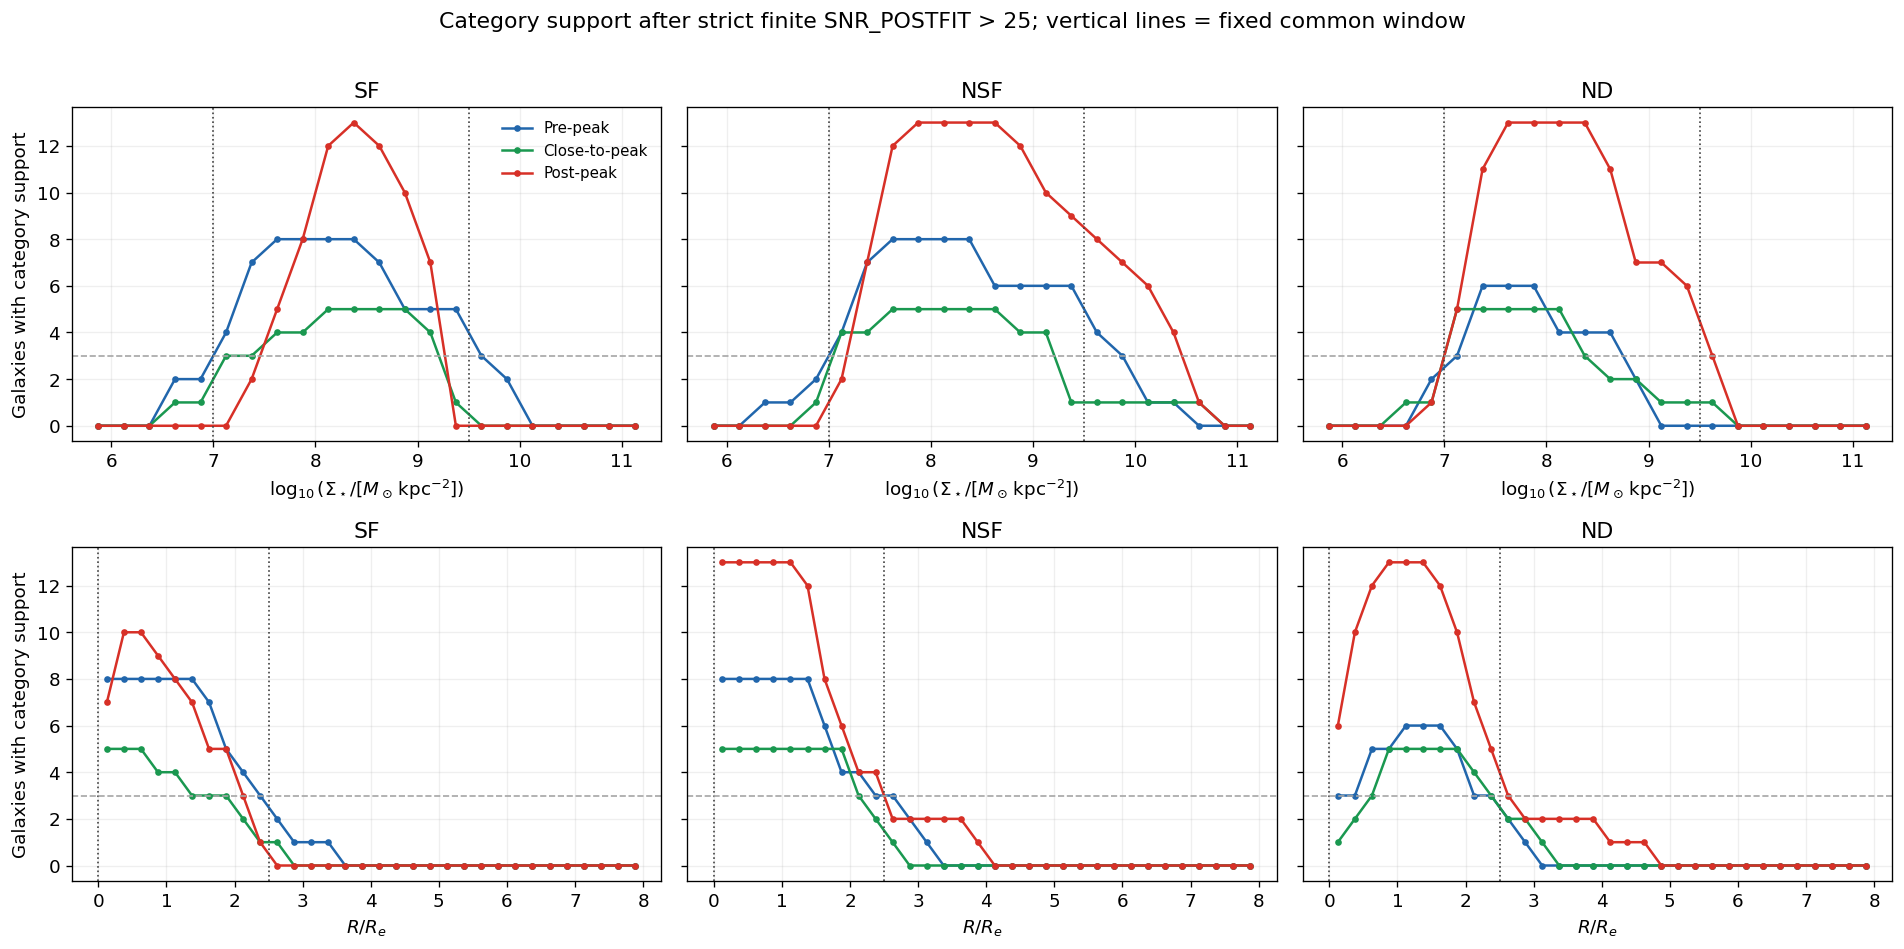

,category,variable,fixed_min,fixed_max
0,SF,log_sigma_star,7.0,9.5
1,SF,radius_re,0.0,2.5
2,NSF,log_sigma_star,7.0,9.5
3,NSF,radius_re,0.0,2.5
4,ND,log_sigma_star,7.0,9.5
5,ND,radius_re,0.0,2.5


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16.0, 7.8), sharex="row", sharey="row")
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, category in enumerate(CATEGORY_ORDER):
        ax = axes[row_index, col_index]
        for stage in STAGE_ORDER:
            sub = STAGE_HALPHA_PROFILES.loc[
                STAGE_HALPHA_PROFILES.stage.eq(stage)
                & STAGE_HALPHA_PROFILES.variable.eq(variable)
                & STAGE_HALPHA_PROFILES.category.eq(category)
            ].sort_values("center")
            ax.plot(
                sub.center, sub.N_gal_category_support,
                color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.5,
                label=STAGE_LABELS[stage],
            )
        lo, hi = COMMON_RELIABLE_RANGES[(category, variable)]
        if np.isfinite(lo):
            ax.axvline(lo, color="0.25", ls=":", lw=1)
            ax.axvline(hi, color="0.25", ls=":", lw=1)
        ax.axhline(MIN_SUPPORT_GALAXIES, color="0.65", ls="--", lw=1)
        ax.set_title(category)
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel("Galaxies with category support")
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle(
    "Category support after strict finite SNR_POSTFIT > 25; "
    "vertical lines = fixed common window", y=1.01,
)
fig.tight_layout()
plt.show()

display(COMMON_RELIABLE_RANGE_TABLE)


## 9. Absolute H$\alpha$ profiles

The profiles use only the fixed reliable range. Curves are equal-galaxy means
of the supported per-galaxy within-category means; bands are whole-galaxy
16--84% intervals. The separate coverage figure shows the galaxy support in
every bin without applying an additional stage-level reliability mask.


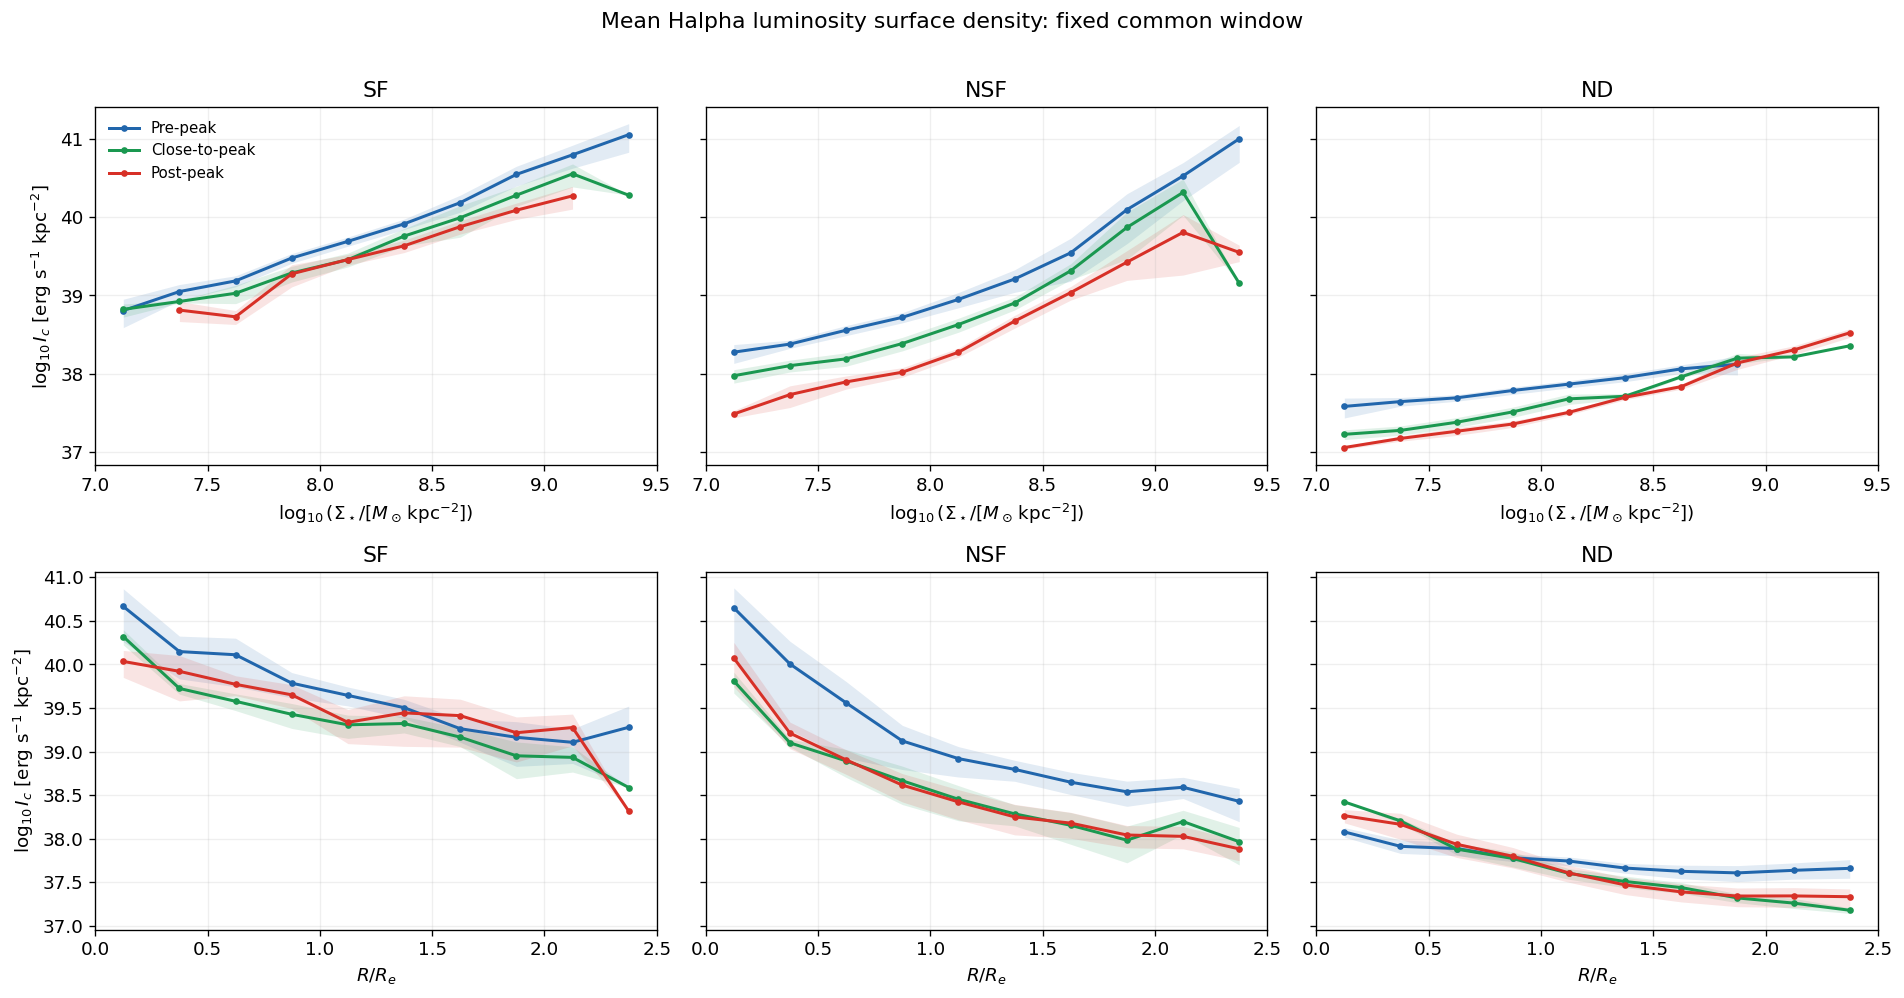

In [9]:
def log_with_interval(frame, metric):
    value = frame[metric].to_numpy(float)
    low = frame[metric + "_lo"].to_numpy(float)
    high = frame[metric + "_hi"].to_numpy(float)
    def positive_log(values):
        result = np.full(values.shape, np.nan)
        good = np.isfinite(values) & (values > 0)
        result[good] = np.log10(values[good])
        return result
    return positive_log(value), positive_log(low), positive_log(high)


def plot_halpha_metric(metric, ylabel, title):
    fig, axes = plt.subplots(
        2, 3, figsize=(16.0, 8.2),
        sharex=False, sharey="row",
    )
    for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
        for col_index, category in enumerate(CATEGORY_ORDER):
            ax = axes[row_index, col_index]
            for stage in STAGE_ORDER:
                sub = HALPHA_BOOTSTRAP.loc[
                    HALPHA_BOOTSTRAP.stage.eq(stage)
                    & HALPHA_BOOTSTRAP.variable.eq(variable)
                    & HALPHA_BOOTSTRAP.category.eq(category)
                ].sort_values("center")
                y, ylo, yhi = log_with_interval(sub, metric)
                shown = sub.in_fixed_reliable_range.to_numpy(bool)
                ax.plot(
                    sub.center.where(shown), np.where(shown, y, np.nan),
                    color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8,
                    label=STAGE_LABELS[stage],
                )
                ax.fill_between(
                    sub.center, ylo, yhi, where=shown,
                    color=STAGE_COLORS[stage], alpha=0.13, linewidth=0,
                )
            lo, hi = COMMON_RELIABLE_RANGES[(category, variable)]
            if np.isfinite(lo) and np.isfinite(hi):
                ax.set_xlim(lo, hi)
            ax.set_title(category)
            ax.set_xlabel(VARIABLE_LABELS[variable])
            if col_index == 0:
                ax.set_ylabel(ylabel)
            ax.grid(alpha=0.2)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle(title, y=1.01)
    fig.tight_layout()
    plt.show()


plot_halpha_metric(
    "mean_intensity",
    r"$\log_{10} I_c$ [erg s$^{-1}$ kpc$^{-2}$]",
    "Mean Halpha luminosity surface density: fixed common window",
)


### Reading the absolute profiles

- $I_c$ is the direct within-category linear mean, averaged equally across
  galaxies that have at least 20 pixels in that category and bin.
- It is not the median spaxel. The later individual-galaxy figure shows the
  robust median-log intensity separately.


## 10. Absolute BPT-line surface-density profiles

A change in a BPT ratio can come from a brighter forbidden line, a fainter
Balmer denominator, or both. To separate these possibilities, this section
measures corrected H$\alpha$, [O III]$\lambda5007$, [N II]$\lambda6583$,
and summed [S II]$\lambda\lambda6716,6731$ surface luminosities on exactly
the same common BPT-valid pixel support. Common support requires detections
of H$\alpha$, H$\beta$, [O III], [N II], and both [S II] lines.

For each line $\ell$, galaxy $g$, category $c$, and bin $b$,

$$
I_{gcb}^{\ell}=\frac{1}{N_{gcb}^{\rm BPT}}
\sum_{p\in(g,c,b,\rm BPT)}\Sigma_{L(\ell),p}.
$$

Stage profiles are equal-galaxy means and bands resample whole galaxies.
Both SF and NSF are shown; ND is excluded because it lacks the Balmer
detections needed for a matched BPT decomposition.


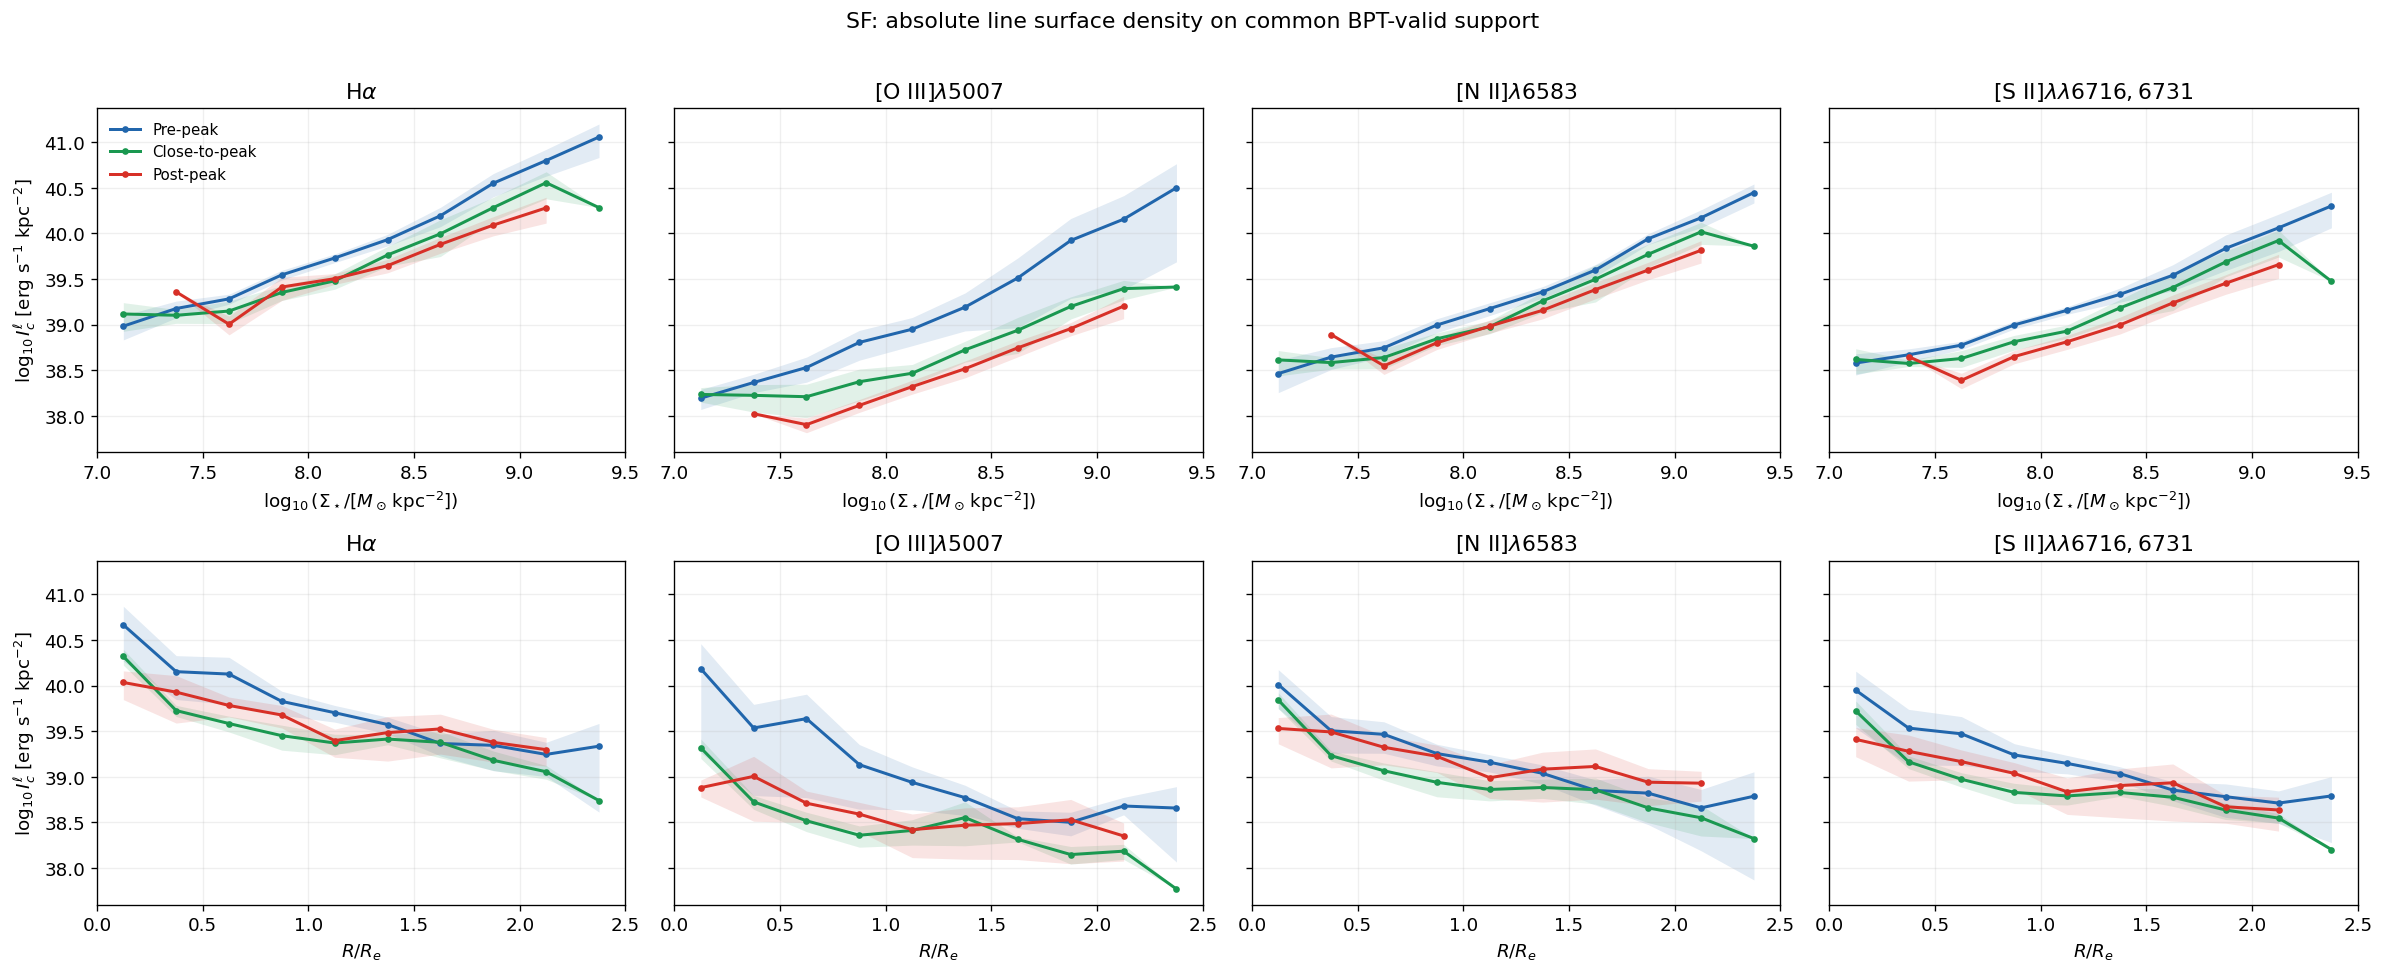

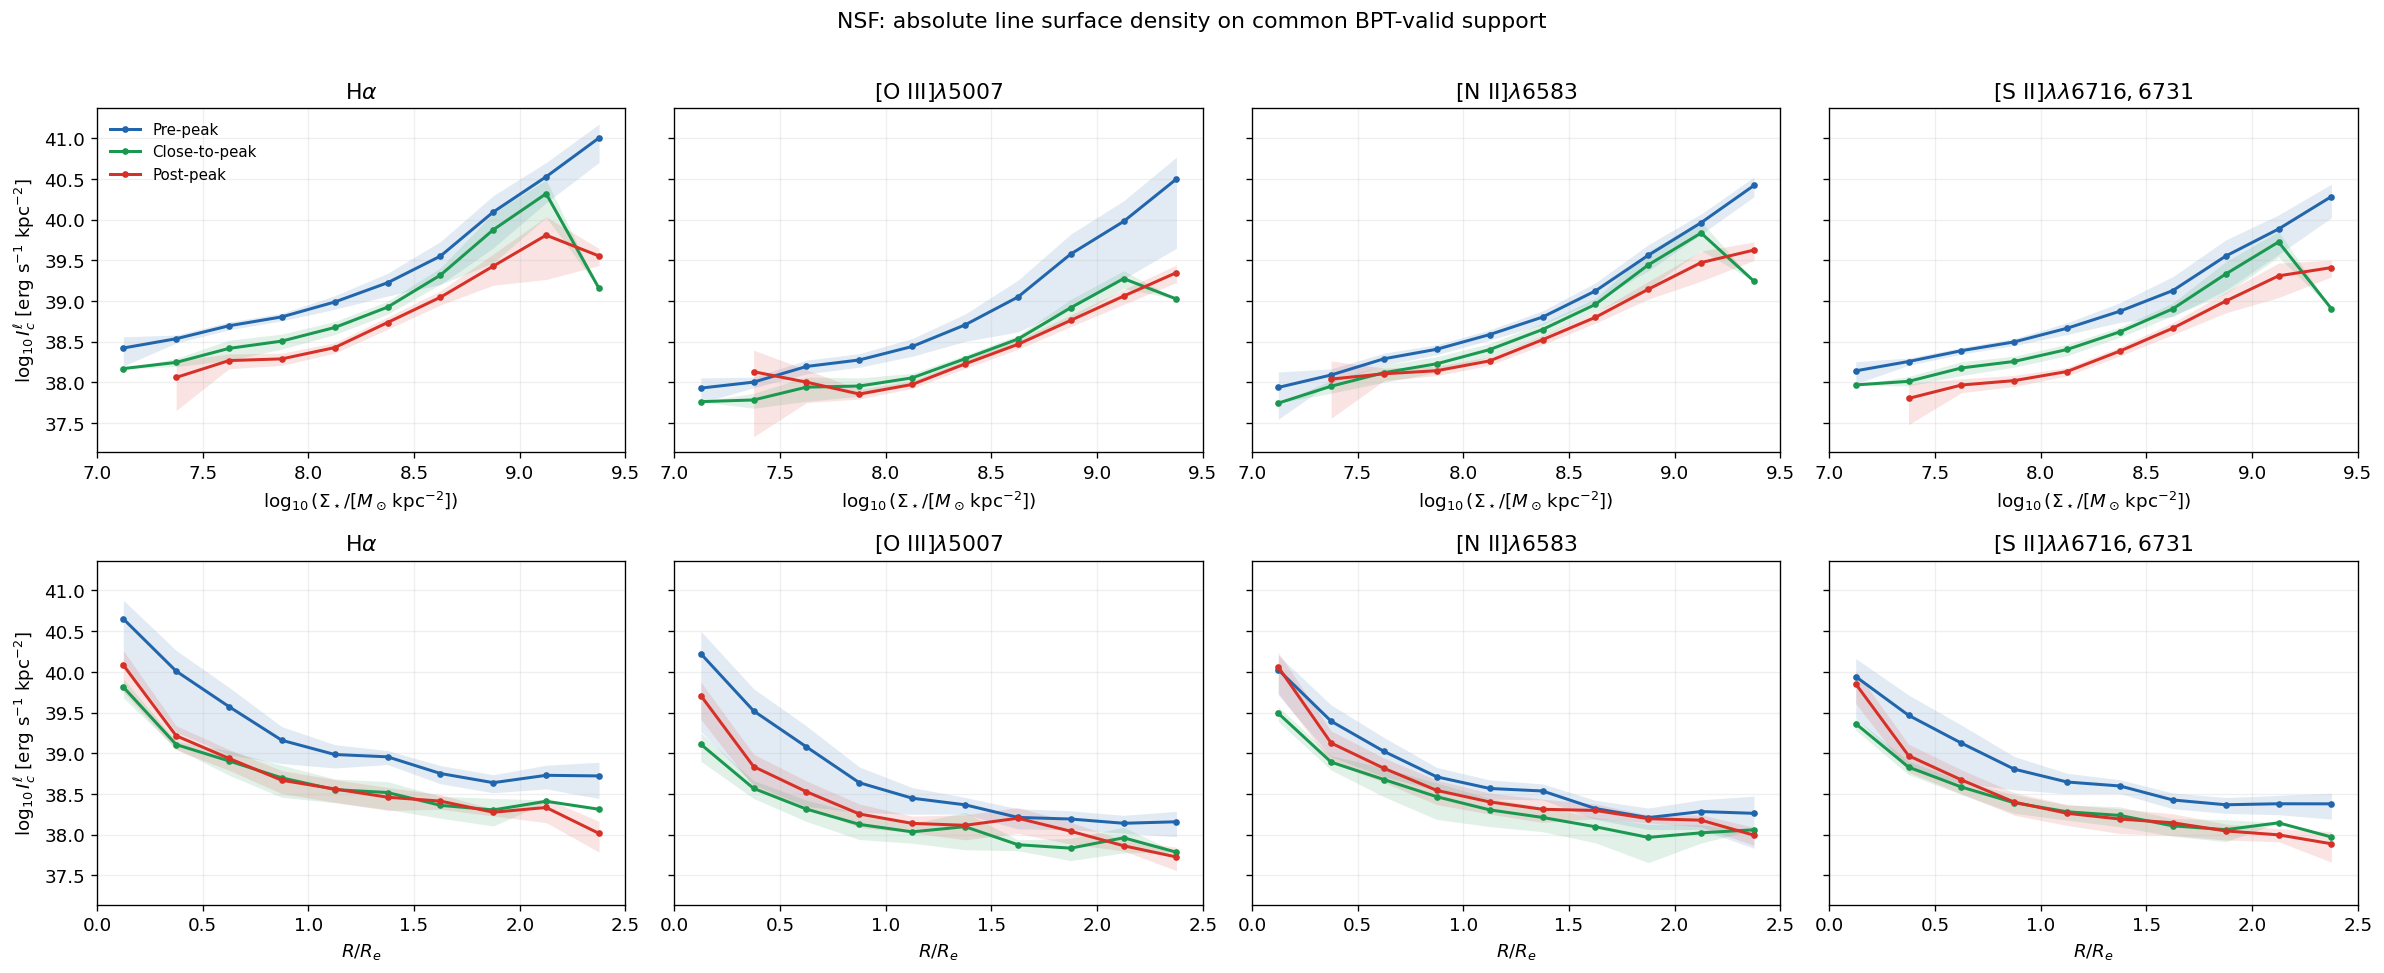

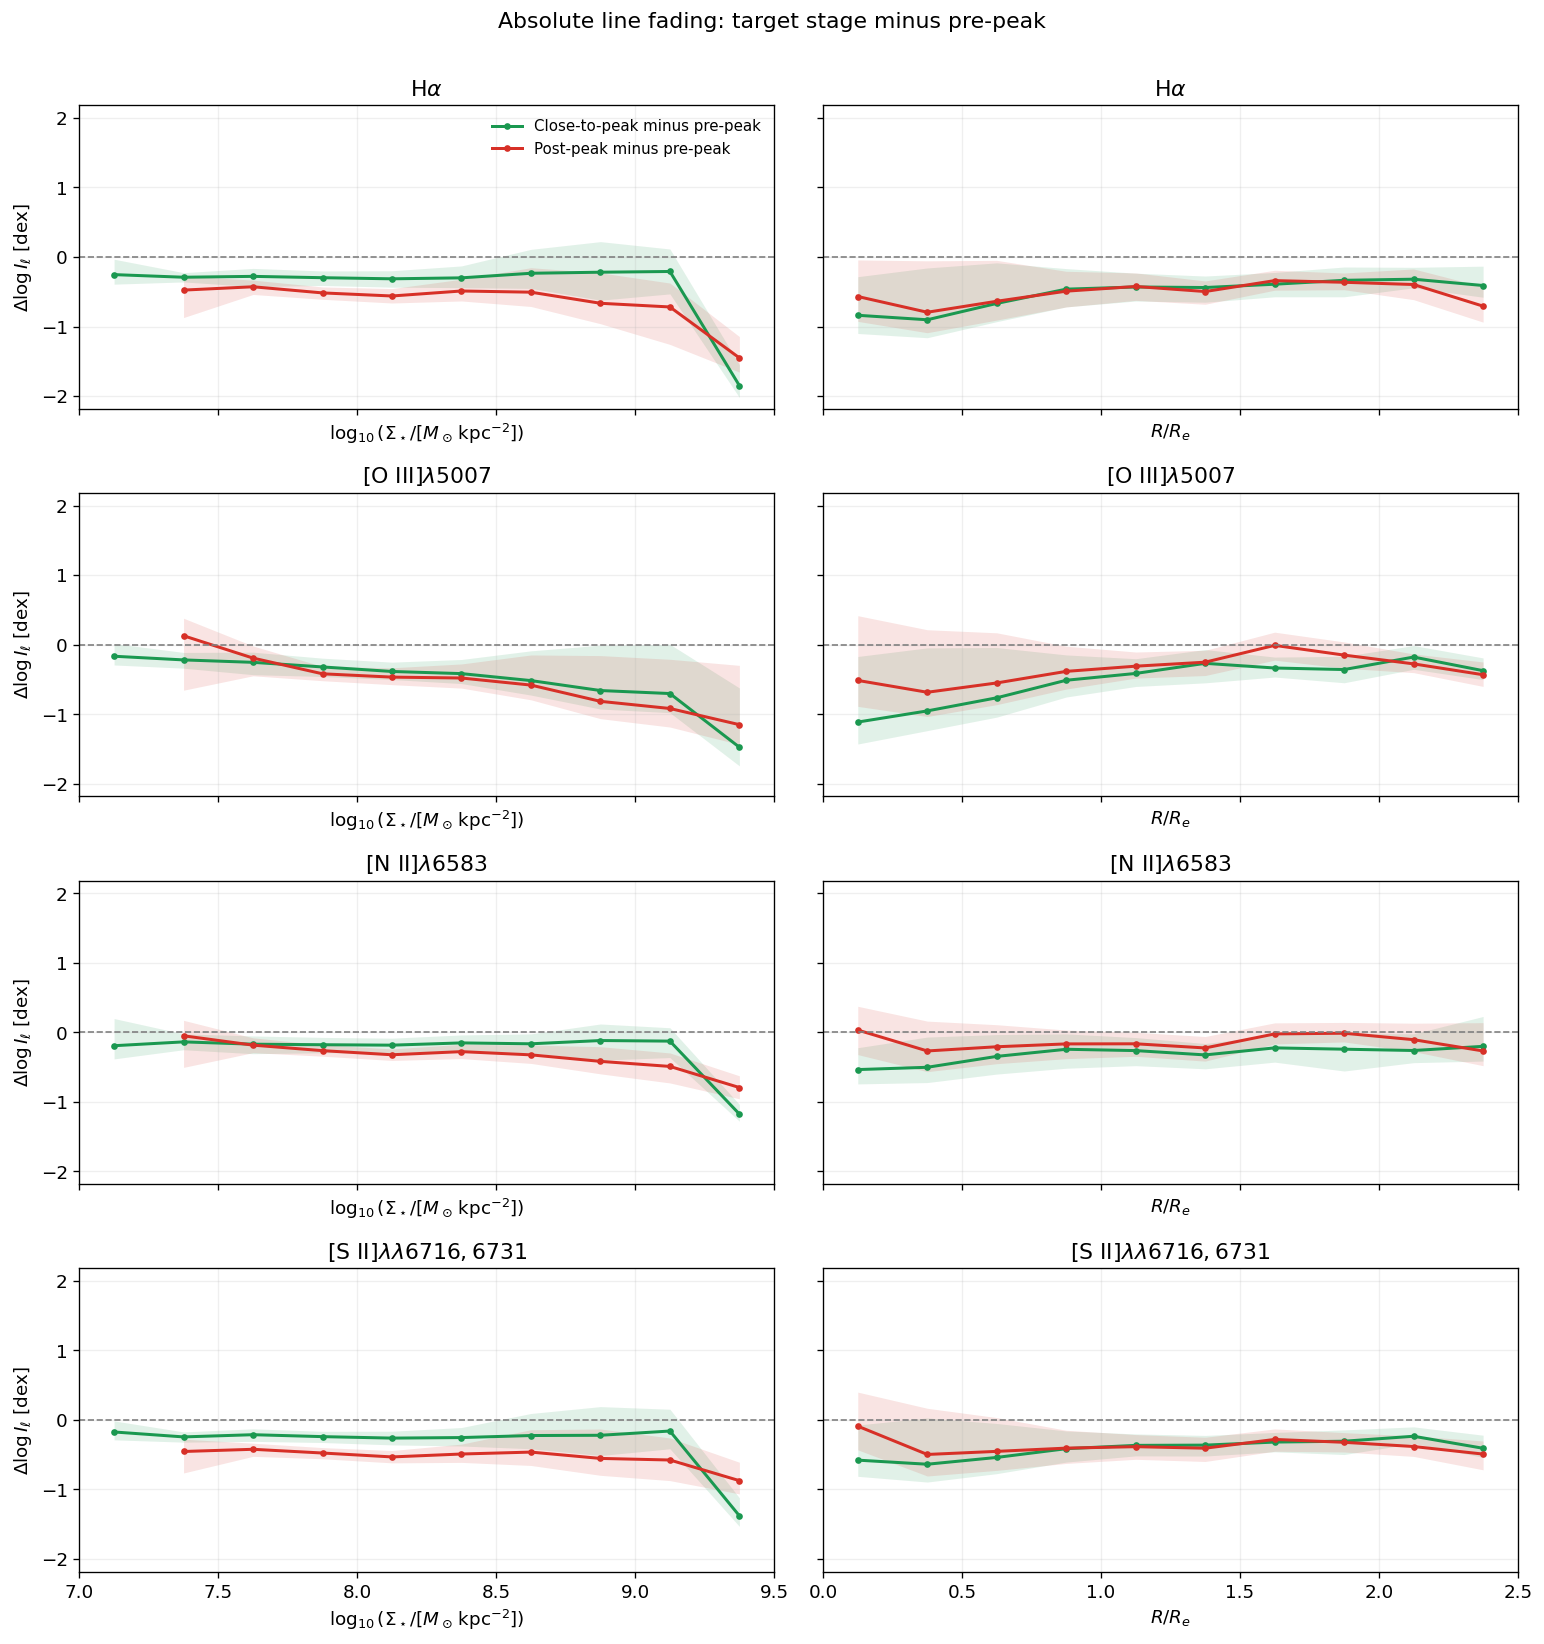

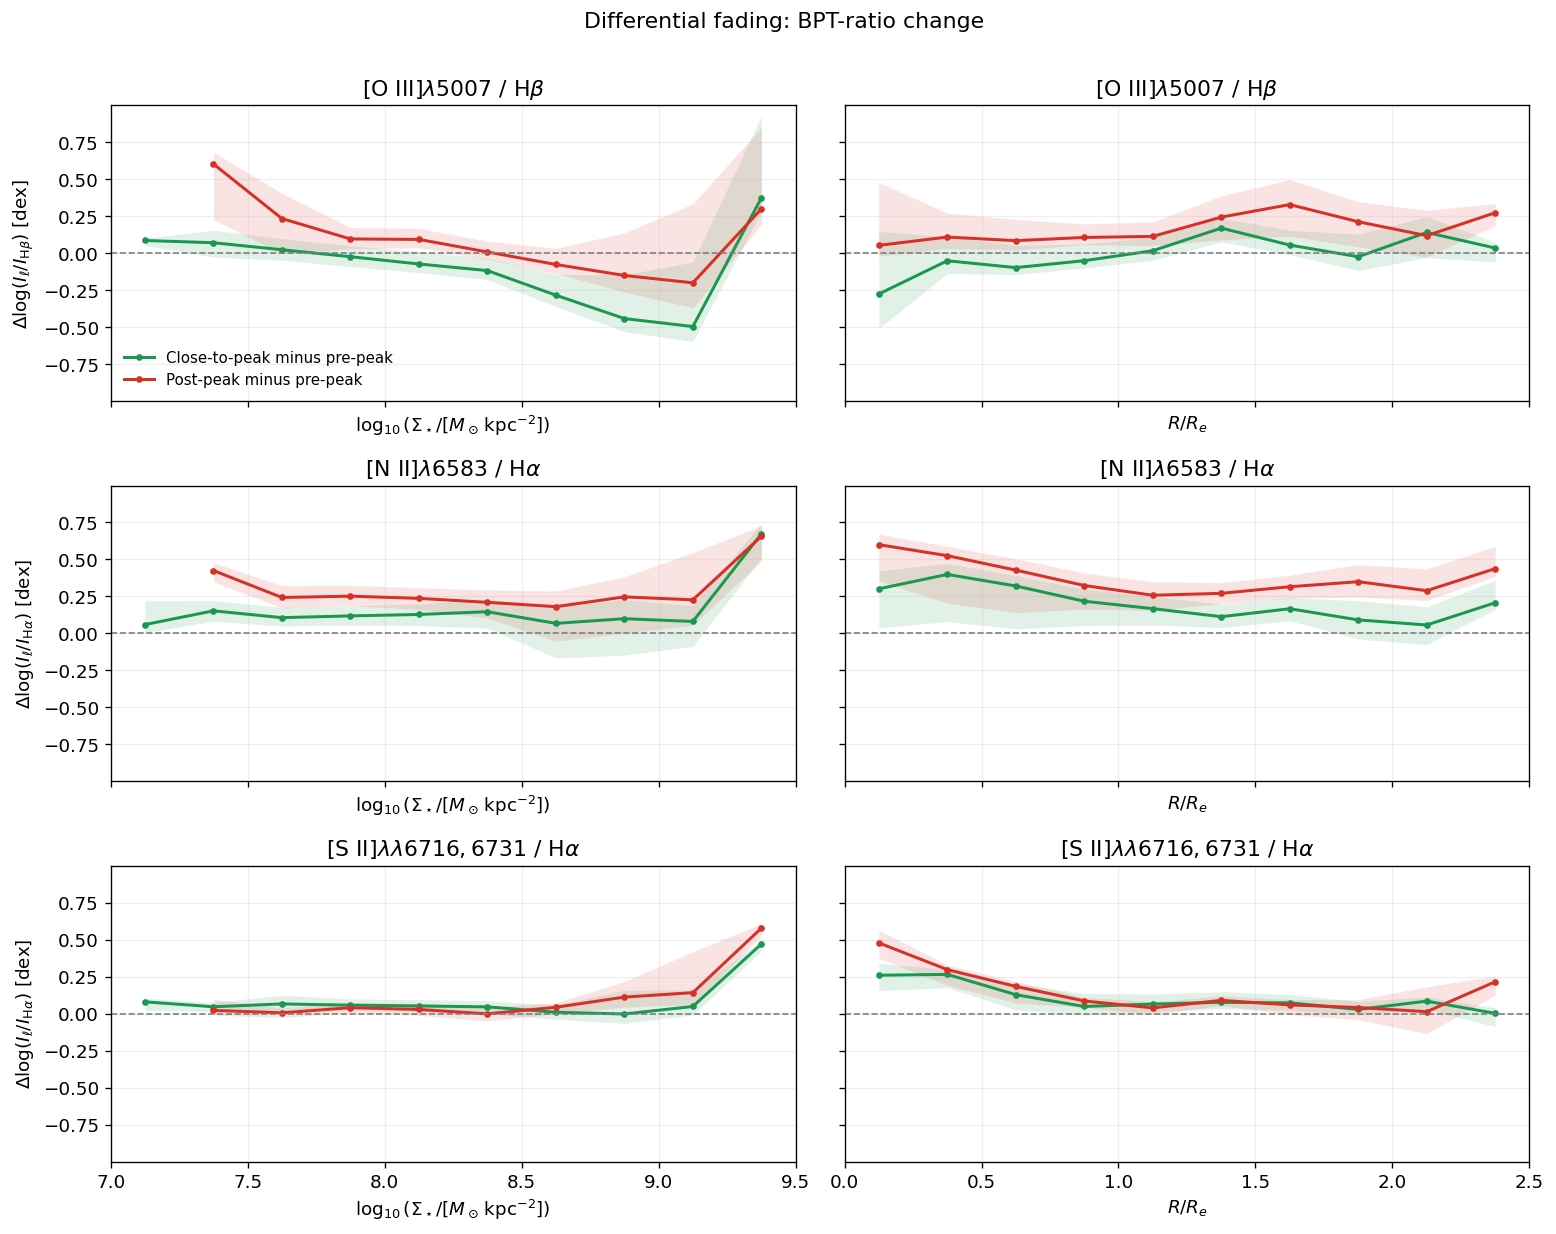

,category,stage_minus_pre,line,variable,N_bins,median_delta_log_I_line,N_bins_CI_above_zero,N_bins_CI_below_zero,median_delta_log_bpt_ratio,N_bins_ratio_CI_above_zero,N_bins_ratio_CI_below_zero
0,NSF,close-to-peak,HA6562,log_sigma_star,10,-0.284,0,7,NaN,0,0
2,NSF,close-to-peak,NII6583,log_sigma_star,10,-0.168,0,7,0.113,7,0
4,NSF,close-to-peak,OIII5006,log_sigma_star,10,-0.401,0,8,-0.048,2,4
6,NSF,close-to-peak,SII_SUM,log_sigma_star,10,-0.232,0,7,0.050,6,0
8,NSF,post-peak,HA6562,log_sigma_star,10,-0.516,0,9,NaN,0,0
10,NSF,post-peak,NII6583,log_sigma_star,10,-0.323,0,8,0.243,8,0
12,NSF,post-peak,OIII5006,log_sigma_star,10,-0.480,0,8,0.094,4,0
14,NSF,post-peak,SII_SUM,log_sigma_star,10,-0.490,0,9,0.040,5,0
1,NSF,close-to-peak,HA6562,radius_re,10,-0.435,0,10,NaN,0,0
3,NSF,close-to-peak,NII6583,radius_re,10,-0.262,0,9,0.188,8,0


### Reading the BPT-line result

For post-peak minus pre-peak NSF, the median fixed-range absolute line change and BPT-ratio change are:

- **Along $\log_{10}(\Sigma_\star/[M_\odot\,\mathrm{kpc}^{-2}])$:**
  - H$\alpha$: $\Delta\log I_\ell=-0.52$ dex; matched BPT-ratio change not applicable.
  - [O III]$\lambda5007$: $\Delta\log I_\ell=-0.48$ dex; $\Delta\log(I_\ell/I_{\mathrm{H}\beta})=+0.09$ dex.
  - [N II]$\lambda6583$: $\Delta\log I_\ell=-0.32$ dex; $\Delta\log(I_\ell/I_{\mathrm{H}\alpha})=+0.24$ dex.
  - [S II]$\lambda\lambda6716,6731$: $\Delta\log I_\ell=-0.49$ dex; $\Delta\log(I_\ell/I_{\mathrm{H}\alpha})=+0.04$ dex.
- **Along $R/R_e$:**
  - H$\alpha$: $\Delta\log I_\ell=-0.49$ dex; matched BPT-ratio change not applicable.
  - [O III]$\lambda5007$: $\Delta\log I_\ell=-0.35$ dex; $\Delta\log(I_\ell/I_{\mathrm{H}\beta})=+0.12$ dex.
  - [N II]$\lambda6583$: $\Delta\log I_\ell=-0.17$ dex; $\Delta\log(I_\ell/I_{\mathrm{H}\alpha})=+0.34$ dex.
  - [S II]$\lambda\lambda6716,6731$: $\Delta\log I_\ell=-0.39$ dex; $\Delta\log(I_\ell/I_{\mathrm{H}\alpha})=+0.09$ dex.

In [10]:
def stage_bpt_line_estimator(per_galaxy):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center", "category"]
    selected = per_galaxy.loc[per_galaxy.category.isin(["SF", "NSF"])]
    for group_keys, group in selected.groupby(keys, observed=True, sort=False):
        base = dict(zip(keys, group_keys))
        supported = group.loc[group.bpt_common_support]
        lo, hi = FIXED_RELIABLE_RANGES[base["variable"]]
        for line in BPT_LINE_ORDER:
            rec = dict(base)
            rec["line"] = line
            rec["N_gal_support"] = int(supported.GALID.nunique())
            rec["mean_line_surface"] = (
                float(supported[f"mean_{line}_within_category"].mean())
                if len(supported) else np.nan
            )
            rec["in_fixed_reliable_range"] = bool(
                rec["center"] >= lo and rec["center"] < hi
            )
            rows.append(rec)
    return pd.DataFrame(rows)


BPT_LINE_PROFILES = stage_bpt_line_estimator(HALPHA_BY_GALAXY_BIN)


def bootstrap_bpt_line_profiles(per_galaxy, n_boot=N_BOOTSTRAP):
    rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = sample.loc[
            sample.stage.eq(stage), "GALID"
        ].sort_values().to_numpy()
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            for category_index, category in enumerate(("SF", "NSF")):
                stage_frame = per_galaxy.loc[
                    per_galaxy.stage.eq(stage)
                    & per_galaxy.variable.eq(variable)
                    & per_galaxy.category.eq(category)
                ]
                # Use shared galaxy-resampling indices across BPT lines so
                # BPT-ratio changes retain their within-galaxy pairing.
                for line in BPT_LINE_ORDER:
                    for bin_index, (lo, hi) in enumerate(zip(
                        COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
                    )):
                        group = stage_frame.loc[
                            np.isclose(stage_frame.bin_left, lo)
                        ].set_index("GALID").reindex(stage_galaxies)
                        supported = group.bpt_common_support.fillna(False).to_numpy(bool)
                        values = np.where(
                            supported,
                            group[f"mean_{line}_within_category"].to_numpy(float),
                            np.nan,
                        )
                        seed = (
                            RANDOM_SEED + 13_000_000 + 1_000_000 * stage_index
                            + 100_000 * variable_index + 10_000 * category_index
                            + bin_index
                        )
                        rng = np.random.default_rng(seed)
                        indices = rng.integers(
                            0, len(stage_galaxies),
                            size=(n_boot, len(stage_galaxies)),
                        )
                        sampled = values[indices]
                        counts = np.isfinite(sampled).sum(axis=1)
                        draws = np.divide(
                            np.nansum(sampled, axis=1), counts,
                            out=np.full(n_boot, np.nan), where=counts > 0,
                        )
                        key = (stage, variable, category, line, float(lo))
                        draws_by_key[key] = draws
                        central = BPT_LINE_PROFILES.loc[
                            BPT_LINE_PROFILES.stage.eq(stage)
                            & BPT_LINE_PROFILES.variable.eq(variable)
                            & BPT_LINE_PROFILES.category.eq(category)
                            & BPT_LINE_PROFILES.line.eq(line)
                            & np.isclose(BPT_LINE_PROFILES.bin_left, lo)
                        ].iloc[0]
                        value_lo, value_hi = finite_percentiles(draws)
                        rows.append({
                            "stage": stage, "variable": variable,
                            "category": category, "line": line,
                            "bin_left": float(lo), "bin_right": float(hi),
                            "center": float((lo + hi) / 2),
                            "N_gal_support": int(central.N_gal_support),
                            "in_fixed_reliable_range": bool(
                                central.in_fixed_reliable_range
                            ),
                            "mean_line_surface": float(central.mean_line_surface),
                            "mean_line_surface_lo": value_lo,
                            "mean_line_surface_hi": value_hi,
                        })
    return pd.DataFrame(rows), draws_by_key


BPT_LINE_BOOTSTRAP, BPT_LINE_BOOTSTRAP_DRAWS = bootstrap_bpt_line_profiles(
    HALPHA_BY_GALAXY_BIN
)


contrast_rows = []
for target_stage in ("close-to-peak", "post-peak"):
    target_rows = BPT_LINE_BOOTSTRAP.loc[BPT_LINE_BOOTSTRAP.stage.eq(target_stage)]
    for target in target_rows.itertuples(index=False):
        reference = BPT_LINE_BOOTSTRAP.loc[
            BPT_LINE_BOOTSTRAP.stage.eq("pre-peak")
            & BPT_LINE_BOOTSTRAP.variable.eq(target.variable)
            & BPT_LINE_BOOTSTRAP.category.eq(target.category)
            & BPT_LINE_BOOTSTRAP.line.eq(target.line)
            & np.isclose(BPT_LINE_BOOTSTRAP.bin_left, target.bin_left)
        ].iloc[0]
        target_draws = BPT_LINE_BOOTSTRAP_DRAWS[(
            target_stage, target.variable, target.category, target.line,
            float(target.bin_left),
        )]
        reference_draws = BPT_LINE_BOOTSTRAP_DRAWS[(
            "pre-peak", target.variable, target.category, target.line,
            float(target.bin_left),
        )]
        target_ha = BPT_LINE_BOOTSTRAP.loc[
            BPT_LINE_BOOTSTRAP.stage.eq(target_stage)
            & BPT_LINE_BOOTSTRAP.variable.eq(target.variable)
            & BPT_LINE_BOOTSTRAP.category.eq(target.category)
            & BPT_LINE_BOOTSTRAP.line.eq("HA6562")
            & np.isclose(BPT_LINE_BOOTSTRAP.bin_left, target.bin_left)
        ].iloc[0]
        reference_ha = BPT_LINE_BOOTSTRAP.loc[
            BPT_LINE_BOOTSTRAP.stage.eq("pre-peak")
            & BPT_LINE_BOOTSTRAP.variable.eq(target.variable)
            & BPT_LINE_BOOTSTRAP.category.eq(target.category)
            & BPT_LINE_BOOTSTRAP.line.eq("HA6562")
            & np.isclose(BPT_LINE_BOOTSTRAP.bin_left, target.bin_left)
        ].iloc[0]
        target_ha_draws = BPT_LINE_BOOTSTRAP_DRAWS[(
            target_stage, target.variable, target.category, "HA6562",
            float(target.bin_left),
        )]
        reference_ha_draws = BPT_LINE_BOOTSTRAP_DRAWS[(
            "pre-peak", target.variable, target.category, "HA6562",
            float(target.bin_left),
        )]
        valid = (
            np.isfinite(target_draws) & (target_draws > 0)
            & np.isfinite(reference_draws) & (reference_draws > 0)
        )
        delta_draws = np.full(len(target_draws), np.nan)
        delta_draws[valid] = (
            np.log10(target_draws[valid]) - np.log10(reference_draws[valid])
        )
        delta_lo, delta_hi = finite_percentiles(delta_draws)
        delta_log_line = (
            np.log10(target.mean_line_surface)
            - np.log10(reference.mean_line_surface)
            if target.mean_line_surface > 0 and reference.mean_line_surface > 0
            else np.nan
        )
        ratio_delta_draws = np.full(len(target_draws), np.nan)
        delta_log_bpt_ratio = np.nan
        if target.line != "HA6562":
            valid_ratio = (
                valid & np.isfinite(target_ha_draws) & (target_ha_draws > 0)
                & np.isfinite(reference_ha_draws) & (reference_ha_draws > 0)
            )
            ratio_delta_draws[valid_ratio] = (
                np.log10(target_draws[valid_ratio] / target_ha_draws[valid_ratio])
                - np.log10(
                    reference_draws[valid_ratio] / reference_ha_draws[valid_ratio]
                )
            )
            if target_ha.mean_line_surface > 0 and reference_ha.mean_line_surface > 0:
                # The corrected Halpha/Hbeta ratio is fixed, so its stage
                # change is zero: delta[OIII/Hbeta] = delta[OIII/Halpha].
                delta_log_bpt_ratio = delta_log_line - (
                    np.log10(target_ha.mean_line_surface)
                    - np.log10(reference_ha.mean_line_surface)
                )
        ratio_delta_lo, ratio_delta_hi = finite_percentiles(ratio_delta_draws)
        contrast_rows.append({
            "stage": target_stage, "variable": target.variable,
            "category": target.category, "line": target.line,
            "bin_left": target.bin_left, "bin_right": target.bin_right,
            "center": target.center,
            "in_fixed_reliable_range": bool(target.in_fixed_reliable_range),
            "delta_log_I_line": delta_log_line,
            "delta_log_I_line_lo": delta_lo,
            "delta_log_I_line_hi": delta_hi,
            "delta_log_bpt_ratio": delta_log_bpt_ratio,
            "delta_log_bpt_ratio_lo": ratio_delta_lo,
            "delta_log_bpt_ratio_hi": ratio_delta_hi,
        })
BPT_LINE_STAGE_CONTRASTS = pd.DataFrame(contrast_rows)


summary_rows = []
for keys, group in BPT_LINE_STAGE_CONTRASTS.loc[
    BPT_LINE_STAGE_CONTRASTS.in_fixed_reliable_range
].groupby(["category", "stage", "line", "variable"], observed=True):
    category, stage, line, variable = keys
    summary_rows.append({
        "category": category, "stage_minus_pre": stage,
        "line": line, "variable": variable,
        "N_bins": int(len(group)),
        "median_delta_log_I_line": float(group.delta_log_I_line.median()),
        "N_bins_CI_above_zero": int(group.delta_log_I_line_lo.gt(0).sum()),
        "N_bins_CI_below_zero": int(group.delta_log_I_line_hi.lt(0).sum()),
        "median_delta_log_bpt_ratio": float(
            group.delta_log_bpt_ratio.median()
        ),
        "N_bins_ratio_CI_above_zero": int(
            group.delta_log_bpt_ratio_lo.gt(0).sum()
        ),
        "N_bins_ratio_CI_below_zero": int(
            group.delta_log_bpt_ratio_hi.lt(0).sum()
        ),
    })
BPT_LINE_CONTRAST_SUMMARY = pd.DataFrame(summary_rows)


def plot_bpt_line_profiles(category):
    fig, axes = plt.subplots(2, 4, figsize=(20.0, 8.0), sharex=False, sharey=True)
    for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
        for col_index, line in enumerate(BPT_LINE_ORDER):
            ax = axes[row_index, col_index]
            for stage in STAGE_ORDER:
                sub = BPT_LINE_BOOTSTRAP.loc[
                    BPT_LINE_BOOTSTRAP.stage.eq(stage)
                    & BPT_LINE_BOOTSTRAP.variable.eq(variable)
                    & BPT_LINE_BOOTSTRAP.category.eq(category)
                    & BPT_LINE_BOOTSTRAP.line.eq(line)
                ].sort_values("center")
                y, ylo, yhi = log_with_interval(sub, "mean_line_surface")
                shown = sub.in_fixed_reliable_range.to_numpy(bool)
                ax.plot(
                    sub.center.where(shown), np.where(shown, y, np.nan),
                    color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8,
                    label=STAGE_LABELS[stage],
                )
                ax.fill_between(
                    sub.center, ylo, yhi, where=shown,
                    color=STAGE_COLORS[stage], alpha=0.13, linewidth=0,
                )
            lo, hi = FIXED_RELIABLE_RANGES[variable]
            ax.set_xlim(lo, hi)
            ax.set_title(BPT_LINE_LABELS[line])
            ax.set_xlabel(VARIABLE_LABELS[variable])
            if col_index == 0:
                ax.set_ylabel(
                    r"$\log_{10} I_c^\ell$ [erg s$^{-1}$ kpc$^{-2}$]"
                )
            ax.grid(alpha=0.2)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle(
        f"{category}: absolute line surface density on common BPT-valid support",
        y=1.01,
    )
    fig.tight_layout()
    plt.show()


for category in ("SF", "NSF"):
    plot_bpt_line_profiles(category)


def symmetric_contrast_limits(frame, interval_columns, padding=0.08):
    selected = frame.loc[frame.in_fixed_reliable_range, interval_columns]
    values = selected.to_numpy(float).ravel()
    finite = values[np.isfinite(values)]
    limit = float(np.max(np.abs(finite))) if finite.size else 1.0
    limit = max(limit * (1.0 + padding), 0.1)
    return -limit, limit


nsf_stage_contrasts = BPT_LINE_STAGE_CONTRASTS.loc[
    BPT_LINE_STAGE_CONTRASTS.category.eq("NSF")
]
absolute_contrast_ylim = symmetric_contrast_limits(
    nsf_stage_contrasts,
    ["delta_log_I_line_lo", "delta_log_I_line_hi"],
)
fig, axes = plt.subplots(
    len(BPT_LINE_ORDER), 2, figsize=(13.0, 3.4 * len(BPT_LINE_ORDER)),
    sharex="col", sharey=True,
)
for row_index, line in enumerate(BPT_LINE_ORDER):
    for col_index, variable in enumerate(("log_sigma_star", "radius_re")):
        ax = axes[row_index, col_index]
        for stage in ("close-to-peak", "post-peak"):
            sub = nsf_stage_contrasts.loc[
                nsf_stage_contrasts.stage.eq(stage)
                & nsf_stage_contrasts.variable.eq(variable)
                & nsf_stage_contrasts.line.eq(line)
                & nsf_stage_contrasts.in_fixed_reliable_range
            ].sort_values("center")
            ax.plot(
                sub.center, sub.delta_log_I_line,
                color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8,
                label=f"{STAGE_LABELS[stage]} minus pre-peak",
            )
            ax.fill_between(
                sub.center, sub.delta_log_I_line_lo, sub.delta_log_I_line_hi,
                color=STAGE_COLORS[stage], alpha=0.13, linewidth=0,
            )
        lo, hi = FIXED_RELIABLE_RANGES[variable]
        ax.set_xlim(lo, hi)
        ax.set_ylim(*absolute_contrast_ylim)
        ax.axhline(0, color="0.5", ls="--", lw=1)
        ax.set_title(BPT_LINE_LABELS[line])
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel(r"$\Delta\log I_\ell$ [dex]")
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Absolute line fading: target stage minus pre-peak", y=1.005)
fig.tight_layout()
plt.show()


forbidden_lines = tuple(line for line in BPT_LINE_ORDER if line != "HA6562")
BPT_RATIO_DENOMINATOR_LABELS = {
    "OIII5006": r"H$\beta$",
    "NII6583": r"H$\alpha$",
    "SII_SUM": r"H$\alpha$",
}
BPT_RATIO_DENOMINATOR_TEX = {
    "OIII5006": r"\mathrm{H}\beta",
    "NII6583": r"\mathrm{H}\alpha",
    "SII_SUM": r"\mathrm{H}\alpha",
}
ratio_contrast_ylim = symmetric_contrast_limits(
    nsf_stage_contrasts.loc[nsf_stage_contrasts.line.isin(forbidden_lines)],
    ["delta_log_bpt_ratio_lo", "delta_log_bpt_ratio_hi"],
)
fig, axes = plt.subplots(
    len(forbidden_lines), 2, figsize=(13.0, 3.4 * len(forbidden_lines)),
    sharex="col", sharey=True,
)
for row_index, line in enumerate(forbidden_lines):
    for col_index, variable in enumerate(("log_sigma_star", "radius_re")):
        ax = axes[row_index, col_index]
        for stage in ("close-to-peak", "post-peak"):
            sub = nsf_stage_contrasts.loc[
                nsf_stage_contrasts.stage.eq(stage)
                & nsf_stage_contrasts.variable.eq(variable)
                & nsf_stage_contrasts.line.eq(line)
                & nsf_stage_contrasts.in_fixed_reliable_range
            ].sort_values("center")
            ax.plot(
                sub.center, sub.delta_log_bpt_ratio,
                color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8,
                label=f"{STAGE_LABELS[stage]} minus pre-peak",
            )
            ax.fill_between(
                sub.center, sub.delta_log_bpt_ratio_lo,
                sub.delta_log_bpt_ratio_hi,
                color=STAGE_COLORS[stage], alpha=0.13, linewidth=0,
            )
        lo, hi = FIXED_RELIABLE_RANGES[variable]
        ax.set_xlim(lo, hi)
        ax.set_ylim(*ratio_contrast_ylim)
        ax.axhline(0, color="0.5", ls="--", lw=1)
        ax.set_title(
            BPT_LINE_LABELS[line] + " / " + BPT_RATIO_DENOMINATOR_LABELS[line]
        )
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            denominator_tex = BPT_RATIO_DENOMINATOR_TEX[line]
            ax.set_ylabel(
                rf"$\Delta\log(I_\ell/I_{{{denominator_tex}}})$ [dex]"
            )
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Differential fading: BPT-ratio change", y=1.005)
fig.tight_layout()
plt.show()

display(BPT_LINE_CONTRAST_SUMMARY.loc[
    BPT_LINE_CONTRAST_SUMMARY.category.eq("NSF")
].sort_values(["variable", "stage_minus_pre", "line"]).round(3))

from IPython.display import Markdown

bpt_result_lines = [
    "### Reading the BPT-line result",
    "",
    "For post-peak minus pre-peak NSF, the median fixed-range absolute line change "
    "and BPT-ratio change are:",
    "",
]
post_nsf = BPT_LINE_CONTRAST_SUMMARY.loc[
    BPT_LINE_CONTRAST_SUMMARY.category.eq("NSF")
    & BPT_LINE_CONTRAST_SUMMARY.stage_minus_pre.eq("post-peak")
]
for variable in ("log_sigma_star", "radius_re"):
    bpt_result_lines.append(f"- **Along {VARIABLE_LABELS[variable]}:**")
    for line in BPT_LINE_ORDER:
        row = post_nsf.loc[
            post_nsf.variable.eq(variable) & post_nsf.line.eq(line)
        ].iloc[0]
        ratio_text = (
            "; matched BPT-ratio change not applicable"
            if line == "HA6562"
            else (
                rf"; $\Delta\log(I_\ell/I_{{{BPT_RATIO_DENOMINATOR_TEX[line]}}})"
                f"={row.median_delta_log_bpt_ratio:+.2f}$ dex"
            )
        )
        bpt_result_lines.append(
            f"  - {BPT_LINE_LABELS[line]}: "
            rf"$\Delta\log I_\ell={row.median_delta_log_I_line:+.2f}$ dex"
            + ratio_text + "."
        )
display(Markdown("\n".join(bpt_result_lines)))


### Reading the absolute BPT-line profiles

Interpret the post-minus-pre contrasts on common BPT-valid pixel support:

- forbidden-line intensity rising while matched H$\alpha$ falls supports
  genuine enhancement of that forbidden line plus Balmer dimming;
- forbidden-line intensity remaining stable while H$\alpha$ falls supports
  primarily denominator-driven movement;
- both declining, with H$\alpha$ declining faster, still raises the ratio
  through differential fading rather than new forbidden-line luminosity.

For the high-ionisation branch, corrected H$\alpha$/H$\beta$ is fixed by
the adopted Balmer-decrement correction, so the stage change in
[O III]/H$\alpha$ is equivalent to that in [O III]/H$\beta$.

This is a direct absolute-flux decomposition, but common-line detection and
the NSF selection itself still condition the sample. Cross-sectional infall
stages do not track the same spaxels through time.


## 11. Occupancy-weighted H$\alpha$ profiles

For each galaxy, category, and bin, define the category H$\alpha$ budget
per unit usable area as

$$
J_{gcb}=\frac{\sum_{p\in c}\Sigma_{L(\mathrm{H}\alpha),p}}{N_{gub}}
       =F_{gcb}I_{gcb}.
$$

The stage curve is the equal-galaxy mean
$J_{scb}=G_{sb}^{-1}\sum_g J_{gcb}$ over galaxies with a usable bin. A
galaxy with zero pixels in a category contributes $J_{gcb}=0$. This is
computed per galaxy before averaging; it is not the product of the stage
mean occupancy and stage mean conditional intensity. Bands are 16--84%
whole-galaxy bootstrap intervals. ND $J_c$ remains an upper-limit
raw-flux/floor proxy because ND lacks a Balmer-decrement correction.


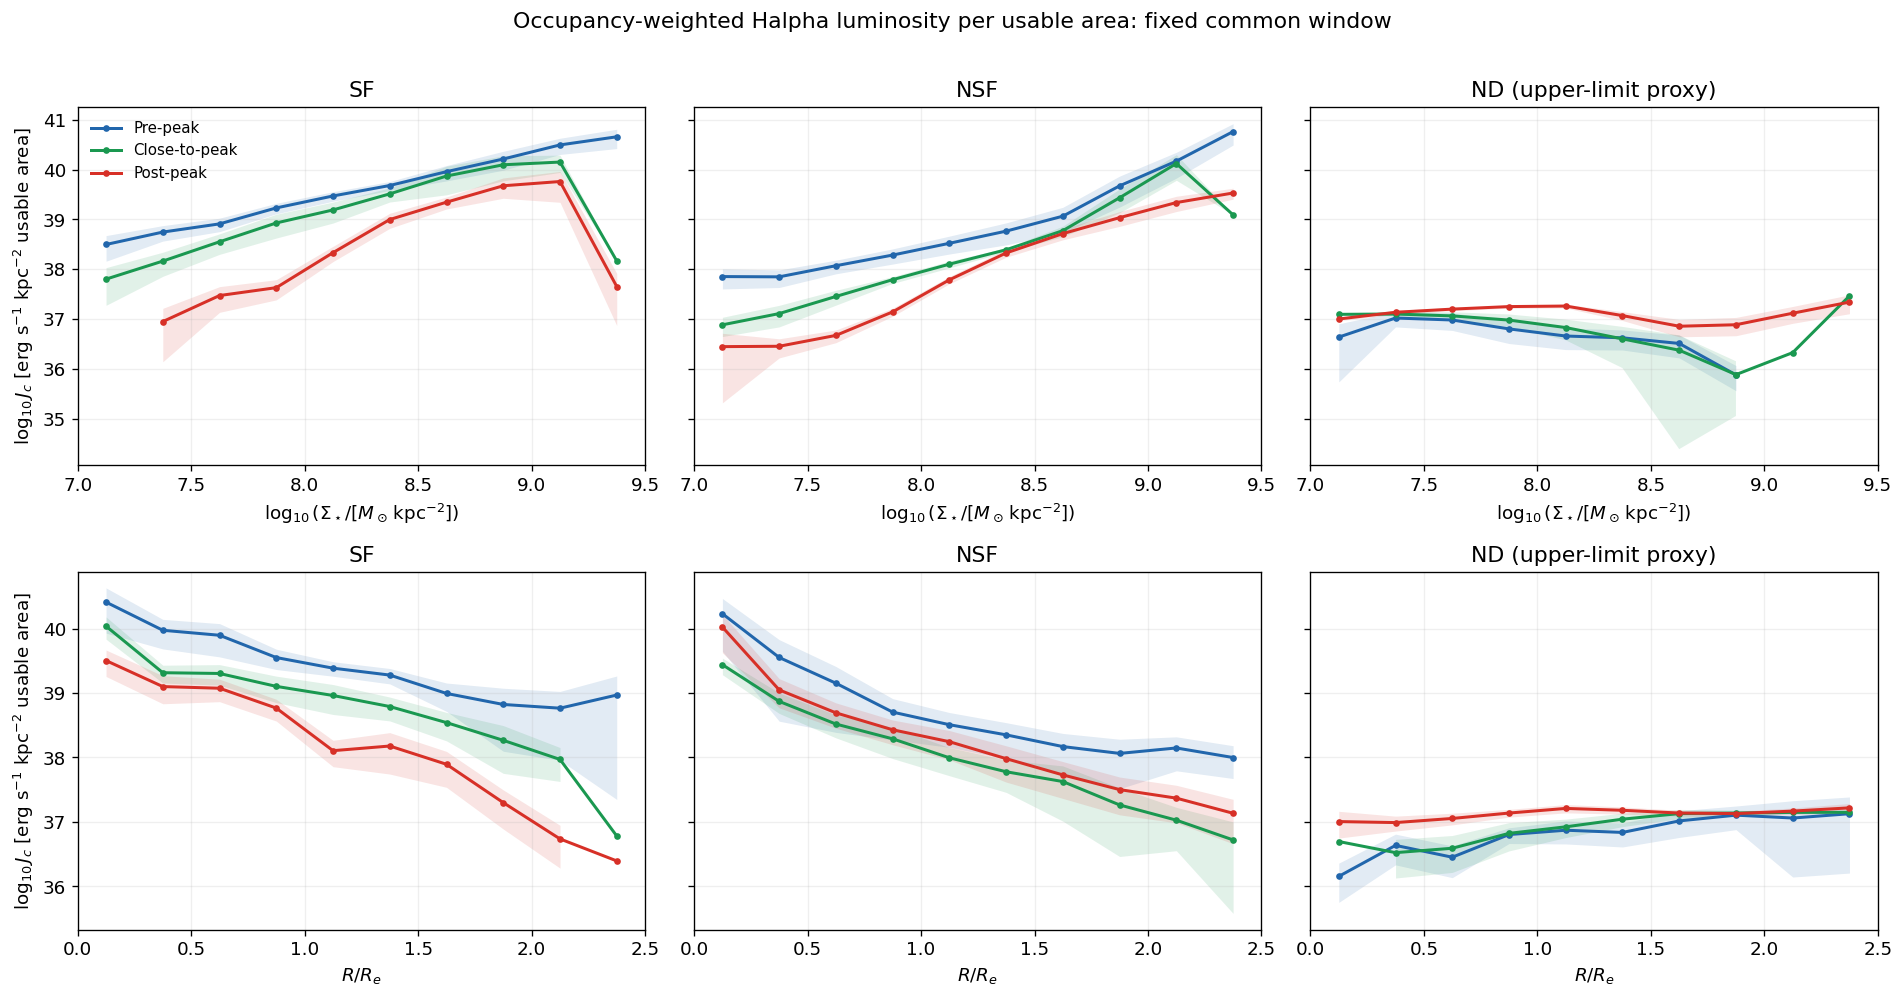

In [11]:
def add_occupancy_weighted_halpha(per_galaxy):
    result = per_galaxy.copy()
    result["j_lha_per_usable"] = np.nan
    eligible = result.eligible_usable.fillna(False).to_numpy(bool)
    has_category = eligible & result.N_category.gt(0).to_numpy(bool)
    has_zero_category = eligible & result.N_category.eq(0).to_numpy(bool)
    result.loc[has_zero_category, "j_lha_per_usable"] = 0.0
    result.loc[has_category, "j_lha_per_usable"] = (
        result.loc[has_category, "f_category"].to_numpy(float)
        * result.loc[has_category, "lha_mean_within_category"].to_numpy(float)
    )
    measured = result.loc[eligible, "j_lha_per_usable"]
    if not (np.isfinite(measured).all() and measured.ge(0).all()):
        raise AssertionError("Invalid occupancy-weighted Halpha measurement")
    return result


HALPHA_BY_GALAXY_BIN = add_occupancy_weighted_halpha(HALPHA_BY_GALAXY_BIN)


def stage_j_estimator(per_galaxy):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center", "category"]
    for group_keys, group in per_galaxy.groupby(keys, observed=True, sort=False):
        rec = dict(zip(keys, group_keys))
        eligible = group.loc[group.eligible_usable]
        rec["N_gal_usable"] = int(eligible.GALID.nunique())
        rec["j_mean"] = (
            float(eligible.j_lha_per_usable.mean()) if len(eligible) else np.nan
        )
        lo, hi = FIXED_RELIABLE_RANGES[rec["variable"]]
        rec["in_fixed_reliable_range"] = bool(
            rec["center"] >= lo and rec["center"] < hi
        )
        rows.append(rec)
    return pd.DataFrame(rows)


J_HALPHA_PROFILES = stage_j_estimator(HALPHA_BY_GALAXY_BIN)


def bootstrap_j_profiles(per_galaxy, n_boot=N_BOOTSTRAP):
    rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = sample.loc[
            sample.stage.eq(stage), "GALID"
        ].sort_values().to_numpy()
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            for category_index, category in enumerate(CATEGORY_ORDER):
                stage_frame = per_galaxy.loc[
                    per_galaxy.stage.eq(stage)
                    & per_galaxy.variable.eq(variable)
                    & per_galaxy.category.eq(category)
                ]
                for bin_index, (lo, hi) in enumerate(zip(
                    COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
                )):
                    group = stage_frame.loc[
                        np.isclose(stage_frame.bin_left, lo)
                    ].set_index("GALID").reindex(stage_galaxies)
                    eligible = group.eligible_usable.fillna(False).to_numpy(bool)
                    j_values = np.where(
                        eligible, group.j_lha_per_usable.to_numpy(float), np.nan
                    )
                    seed = (
                        RANDOM_SEED + 5_000_000 + 1_000_000 * stage_index
                        + 100_000 * variable_index + 10_000 * category_index + bin_index
                    )
                    rng = np.random.default_rng(seed)
                    indices = rng.integers(
                        0, len(stage_galaxies), size=(n_boot, len(stage_galaxies))
                    )
                    sampled = j_values[indices]
                    counts = np.isfinite(sampled).sum(axis=1)
                    draws = np.divide(
                        np.nansum(sampled, axis=1), counts,
                        out=np.full(n_boot, np.nan), where=counts > 0,
                    )
                    key = (stage, variable, category, float(lo))
                    draws_by_key[key] = draws
                    central = J_HALPHA_PROFILES.loc[
                        J_HALPHA_PROFILES.stage.eq(stage)
                        & J_HALPHA_PROFILES.variable.eq(variable)
                        & J_HALPHA_PROFILES.category.eq(category)
                        & np.isclose(J_HALPHA_PROFILES.bin_left, lo)
                    ].iloc[0]
                    j_lo, j_hi = finite_percentiles(draws)
                    rows.append({
                        "stage": stage, "variable": variable, "category": category,
                        "bin_left": float(lo), "bin_right": float(hi),
                        "center": float((lo + hi) / 2),
                        "N_gal_usable": int(central.N_gal_usable),
                        "in_fixed_reliable_range": bool(central.in_fixed_reliable_range),
                        "j_mean": float(central.j_mean),
                        "j_mean_lo": j_lo, "j_mean_hi": j_hi,
                    })
    return pd.DataFrame(rows), draws_by_key


J_HALPHA_BOOTSTRAP, J_HALPHA_BOOTSTRAP_DRAWS = bootstrap_j_profiles(
    HALPHA_BY_GALAXY_BIN
)


fig, axes = plt.subplots(
    2, 3, figsize=(16.0, 8.2), sharex=False, sharey="row"
)
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, category in enumerate(CATEGORY_ORDER):
        ax = axes[row_index, col_index]
        for stage in STAGE_ORDER:
            sub = J_HALPHA_BOOTSTRAP.loc[
                J_HALPHA_BOOTSTRAP.stage.eq(stage)
                & J_HALPHA_BOOTSTRAP.variable.eq(variable)
                & J_HALPHA_BOOTSTRAP.category.eq(category)
            ].sort_values("center")
            y, ylo, yhi = log_with_interval(sub, "j_mean")
            shown = sub.in_fixed_reliable_range.to_numpy(bool)
            ax.plot(
                sub.center.where(shown), np.where(shown, y, np.nan),
                color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8,
                label=STAGE_LABELS[stage],
            )
            ax.fill_between(
                sub.center, ylo, yhi, where=shown,
                color=STAGE_COLORS[stage], alpha=0.13, linewidth=0,
            )
        lo, hi = COMMON_RELIABLE_RANGES[(category, variable)]
        ax.set_xlim(lo, hi)
        ax.set_title(category + (" (upper-limit proxy)" if category == "ND" else ""))
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel(
                r"$\log_{10} J_c$ [erg s$^{-1}$ kpc$^{-2}$ usable area]"
            )
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle(
    "Occupancy-weighted Halpha luminosity per usable area: fixed common window",
    y=1.01,
)
fig.tight_layout()
plt.show()


### Reading the occupancy-weighted profiles

- $J_{\rm SF}$, $J_{\rm NSF}$, and $J_{\rm ND}$ show how much of the
  total H$\alpha$ budget per usable area is assigned to each observational
  category.
- A category can occupy more area while its $J_c$ declines; that is the
  direct signature expected when relative emergence is driven by fading or
  reclassification rather than added H$\alpha$ power.
- Compare $J_c$ with both $F_c$ and $I_c$: none of the three alone identifies
  a unique ionisation mechanism.


## 12. H$\alpha$ emission-share profiles

Two normalised views complement the absolute $J_c$ profiles:

$$
q_{g,c}^{\rm budget}=\frac{J_{g,c}}{J_{g,\rm SF}+J_{g,\rm NSF}+J_{g,\rm ND}},
\qquad
q_{g,c}^{\rm det}=\frac{J_{g,c}}{J_{g,\rm SF}+J_{g,\rm NSF}}
\quad(c=\mathrm{SF,NSF}).
$$

Each fraction is formed within a galaxy before equal-galaxy stage averaging;
it is not the ratio of stage-mean $J_c$ values. The three-category quantity
is a mixed/censored bookkeeping share because $J_{\rm ND}$ is an upper-limit
raw-flux/floor proxy. The detected-only SF/NSF split has consistent corrected
H$\alpha$ ordinates but deliberately excludes ND.


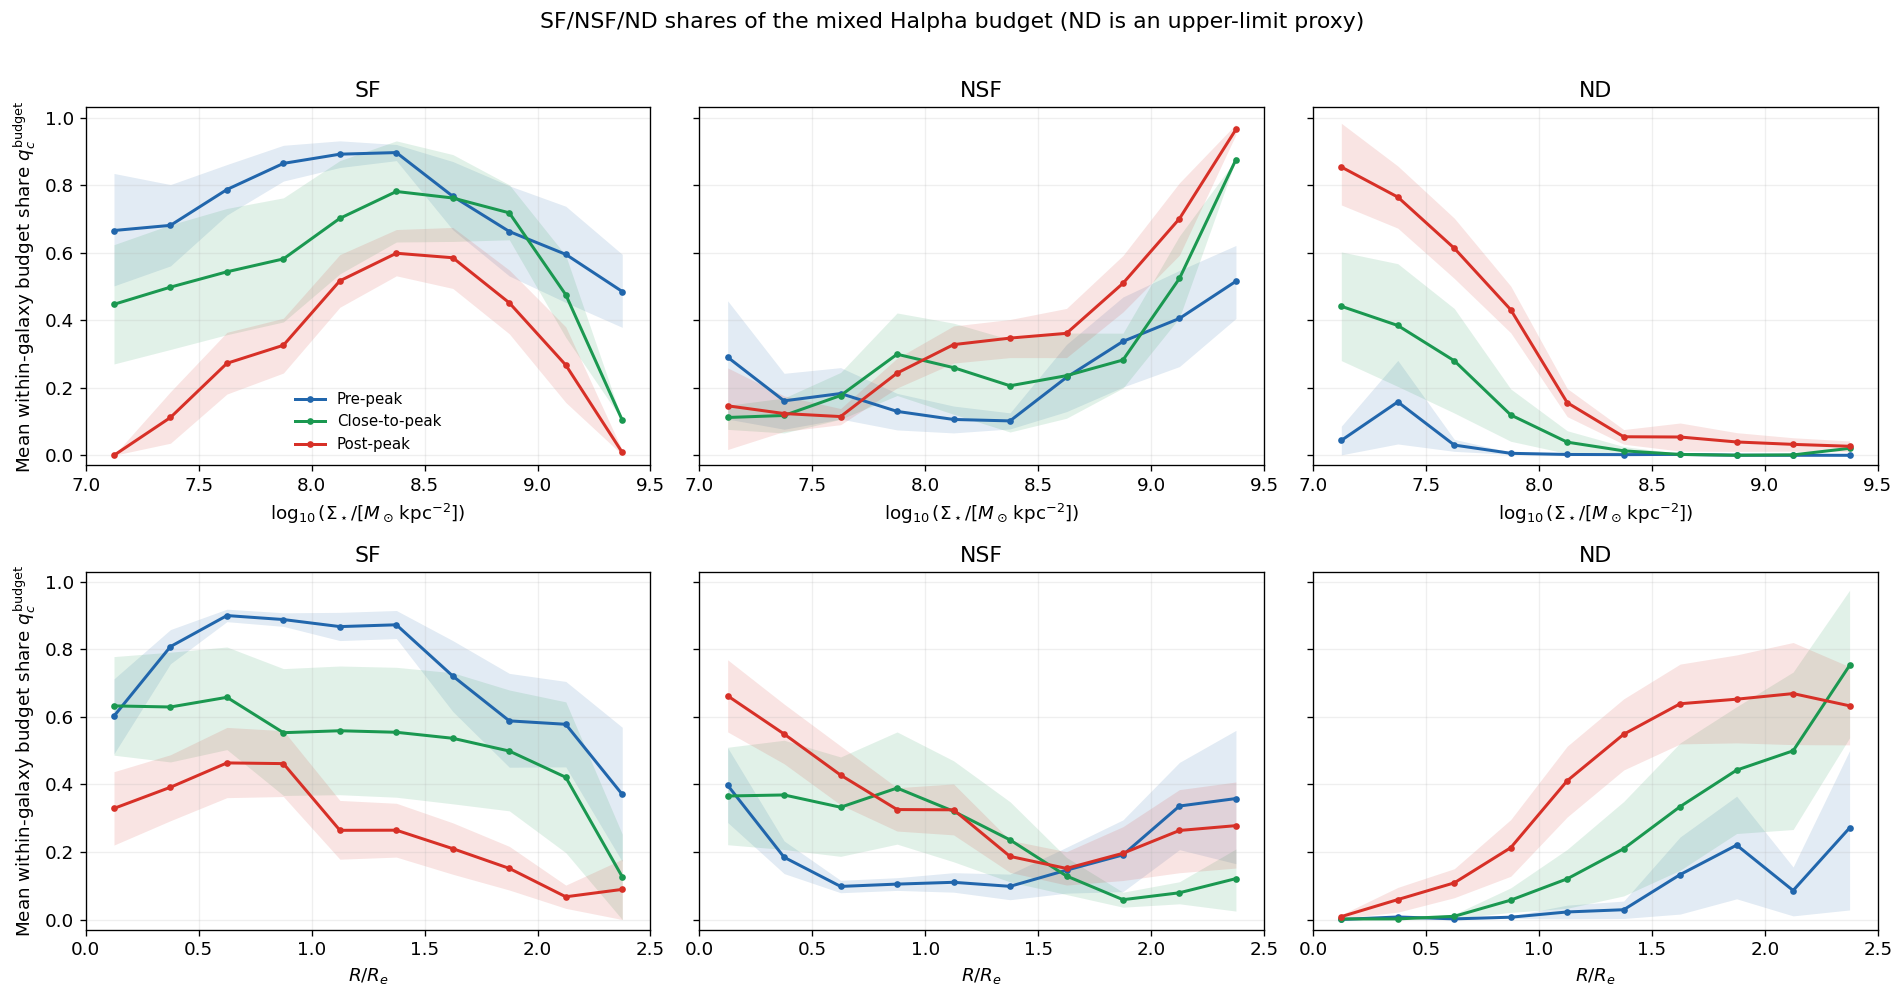

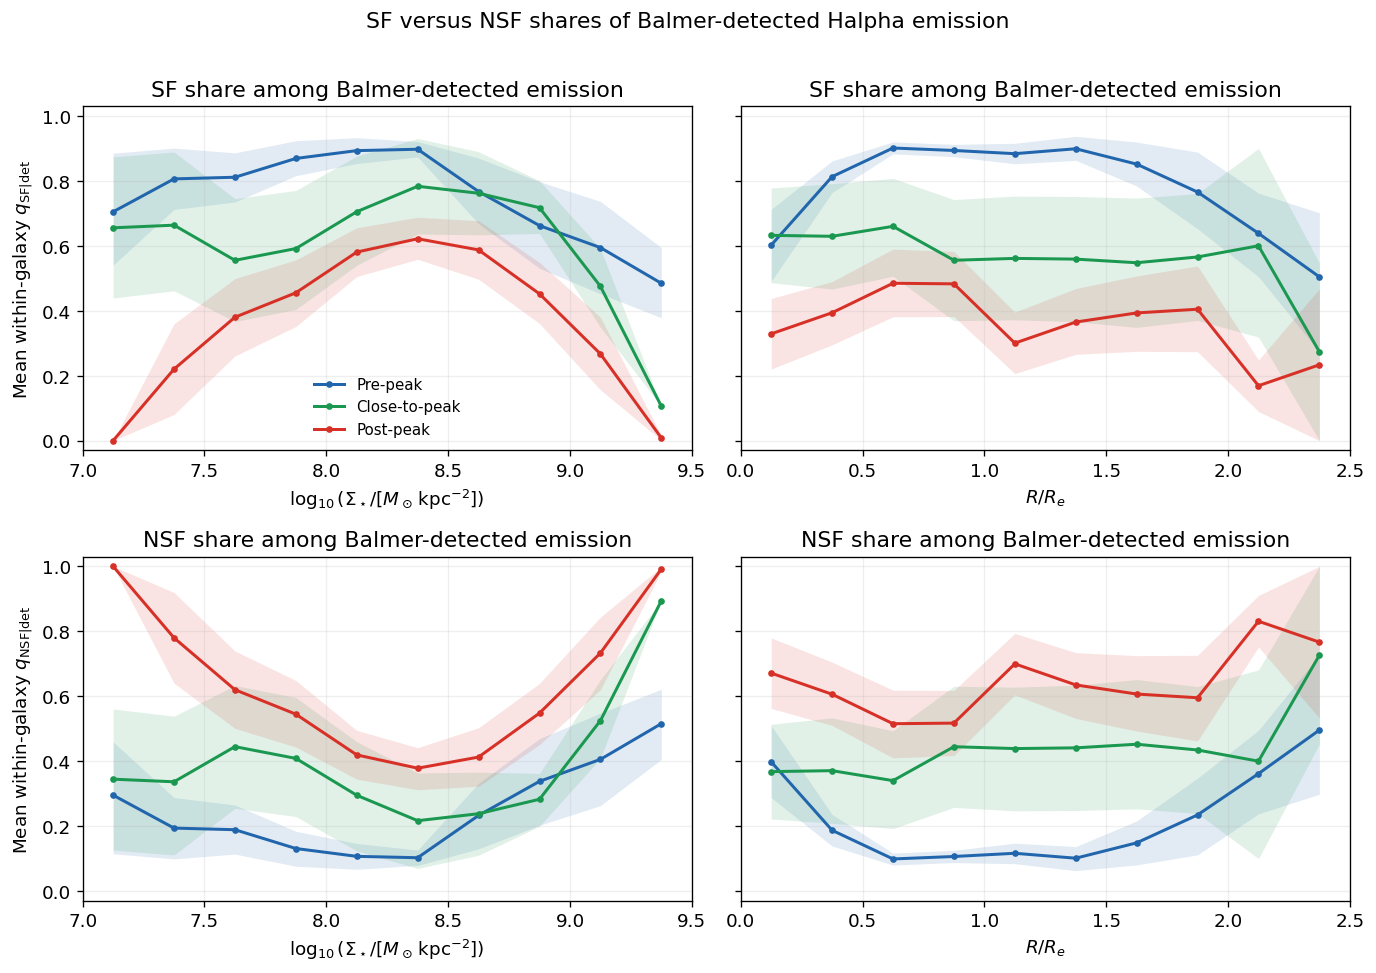

In [12]:
def build_halpha_share_table(per_galaxy):
    index_columns = [
        "GALID", "stage", "variable", "bin_left", "bin_right",
        "center", "N_usable", "eligible_usable",
    ]
    wide = per_galaxy.pivot(
        index=index_columns, columns="category", values="j_lha_per_usable"
    ).reset_index()
    wide.columns.name = None

    budget_total = wide[list(CATEGORY_ORDER)].sum(axis=1, min_count=1)
    good_budget = np.isfinite(budget_total) & budget_total.gt(0)
    for category in CATEGORY_ORDER:
        metric = f"q_budget_{category}"
        wide[metric] = np.nan
        wide.loc[good_budget, metric] = (
            wide.loc[good_budget, category] / budget_total.loc[good_budget]
        )

    detected_total = wide[["SF", "NSF"]].sum(axis=1, min_count=1)
    good_detected = np.isfinite(detected_total) & detected_total.gt(0)
    for category in ("SF", "NSF"):
        metric = f"q_detected_{category}"
        wide[metric] = np.nan
        wide.loc[good_detected, metric] = (
            wide.loc[good_detected, category] / detected_total.loc[good_detected]
        )
    return wide


HALPHA_Q_BY_GALAXY_BIN = build_halpha_share_table(HALPHA_BY_GALAXY_BIN)
Q_BUDGET_METRICS = tuple(f"q_budget_{category}" for category in CATEGORY_ORDER)
Q_DETECTED_METRICS = ("q_detected_SF", "q_detected_NSF")
Q_METRICS = Q_BUDGET_METRICS + Q_DETECTED_METRICS


def stage_q_estimator(per_galaxy_q):
    rows = []
    keys = ["stage", "variable", "bin_left", "bin_right", "center"]
    for group_keys, group in per_galaxy_q.groupby(keys, observed=True, sort=False):
        rec = dict(zip(keys, group_keys))
        for metric in Q_METRICS:
            finite = group[metric].dropna()
            rec[metric] = float(finite.mean()) if len(finite) else np.nan
            rec[f"N_gal_{metric}"] = int(len(finite))
        lo, hi = FIXED_RELIABLE_RANGES[rec["variable"]]
        rec["in_fixed_reliable_range"] = bool(
            rec["center"] >= lo and rec["center"] < hi
        )
        rows.append(rec)
    return pd.DataFrame(rows)


HALPHA_Q_PROFILES = stage_q_estimator(HALPHA_Q_BY_GALAXY_BIN)


def bootstrap_q_profiles(per_galaxy_q, n_boot=N_BOOTSTRAP):
    rows = []
    draws_by_key = {}
    for stage_index, stage in enumerate(STAGE_ORDER):
        stage_galaxies = sample.loc[
            sample.stage.eq(stage), "GALID"
        ].sort_values().to_numpy()
        for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
            stage_frame = per_galaxy_q.loc[
                per_galaxy_q.stage.eq(stage) & per_galaxy_q.variable.eq(variable)
            ]
            for bin_index, (lo, hi) in enumerate(zip(
                COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
            )):
                group = stage_frame.loc[
                    np.isclose(stage_frame.bin_left, lo)
                ].set_index("GALID").reindex(stage_galaxies)
                seed = (
                    RANDOM_SEED + 9_000_000 + 1_000_000 * stage_index
                    + 100_000 * variable_index + bin_index
                )
                rng = np.random.default_rng(seed)
                indices = rng.integers(
                    0, len(stage_galaxies), size=(n_boot, len(stage_galaxies))
                )
                central = HALPHA_Q_PROFILES.loc[
                    HALPHA_Q_PROFILES.stage.eq(stage)
                    & HALPHA_Q_PROFILES.variable.eq(variable)
                    & np.isclose(HALPHA_Q_PROFILES.bin_left, lo)
                ].iloc[0]
                rec = {
                    "stage": stage, "variable": variable,
                    "bin_left": float(lo), "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                    "in_fixed_reliable_range": bool(
                        central.in_fixed_reliable_range
                    ),
                }
                for metric in Q_METRICS:
                    values = group[metric].to_numpy(float)
                    sampled = values[indices]
                    counts = np.isfinite(sampled).sum(axis=1)
                    draws = np.divide(
                        np.nansum(sampled, axis=1), counts,
                        out=np.full(n_boot, np.nan), where=counts > 0,
                    )
                    draws_by_key[(stage, variable, float(lo), metric)] = draws
                    rec[metric] = float(central[metric])
                    rec[f"{metric}_lo"], rec[f"{metric}_hi"] = (
                        finite_percentiles(draws)
                    )
                    rec[f"N_gal_{metric}"] = int(central[f"N_gal_{metric}"])
                rows.append(rec)
    return pd.DataFrame(rows), draws_by_key


HALPHA_Q_BOOTSTRAP, HALPHA_Q_BOOTSTRAP_DRAWS = bootstrap_q_profiles(
    HALPHA_Q_BY_GALAXY_BIN
)


def plot_q_profile(ax, variable, metric, title):
    for stage in STAGE_ORDER:
        sub = HALPHA_Q_BOOTSTRAP.loc[
            HALPHA_Q_BOOTSTRAP.stage.eq(stage)
            & HALPHA_Q_BOOTSTRAP.variable.eq(variable)
        ].sort_values("center")
        shown = sub.in_fixed_reliable_range.to_numpy(bool)
        y = sub[metric].to_numpy(float)
        ylo = sub[f"{metric}_lo"].to_numpy(float)
        yhi = sub[f"{metric}_hi"].to_numpy(float)
        ax.plot(
            sub.center.where(shown), np.where(shown, y, np.nan),
            color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.8,
            label=STAGE_LABELS[stage],
        )
        ax.fill_between(
            sub.center, ylo, yhi, where=shown,
            color=STAGE_COLORS[stage], alpha=0.13, linewidth=0,
        )
    lo, hi = FIXED_RELIABLE_RANGES[variable]
    ax.set_xlim(lo, hi)
    ax.set_ylim(-0.03, 1.03)
    ax.set_title(title)
    ax.set_xlabel(VARIABLE_LABELS[variable])
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(
    2, 3, figsize=(16.0, 8.2), sharex=False, sharey=True
)
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, category in enumerate(CATEGORY_ORDER):
        plot_q_profile(
            axes[row_index, col_index], variable, f"q_budget_{category}", category
        )
        if col_index == 0:
            axes[row_index, col_index].set_ylabel(
                r"Mean within-galaxy budget share $q_c^{\rm budget}$"
            )
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle(
    "SF/NSF/ND shares of the mixed Halpha budget (ND is an upper-limit proxy)",
    y=1.01,
)
fig.tight_layout()
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(11.6, 8.0), sharey=True)
for row_index, category in enumerate(("SF", "NSF")):
    for col_index, variable in enumerate(("log_sigma_star", "radius_re")):
        plot_q_profile(
            axes[row_index, col_index], variable, f"q_detected_{category}",
            f"{category} share among Balmer-detected emission",
        )
        if col_index == 0:
            axes[row_index, col_index].set_ylabel(
                rf"Mean within-galaxy $q_{{\rm {category}|det}}$"
            )
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("SF versus NSF shares of Balmer-detected Halpha emission", y=1.01)
fig.tight_layout()
plt.show()


### Reading the emission-share profiles

- $q_c^{\rm budget}$ describes compositional redistribution across all three
  observational categories, but ND prevents it from being interpreted as a
  fully corrected physical H$\alpha$ fraction.
- $q_{\rm NSF|det}$ cleanly asks what fraction of Balmer-detected H$\alpha$
  is assigned to NSF rather than SF; $q_{\rm SF|det}=1-q_{\rm NSF|det}$.
- Rising $q_{\rm NSF|det}$ can result from falling SF emission even if
  $J_{\rm NSF}$ is constant or declining. Therefore the $q$ profiles show
  relative dominance, while the adjacent $J$ profiles test whether the NSF
  H$\alpha$ contribution itself is enhanced.


## 13. NSF fraction and H$\alpha$ surface-density contrasts

Only bins inside the fixed reliable NSF range drive interpretation.

- **Area change without a brightness change:** $\Delta\log F_{\rm NSF}$
  changes while $\Delta\log I_{\rm NSF}\simeq0$.
- **Brighter NSF regions:** $\Delta\log I_{\rm NSF}>0$, preferably alongside
  concordant excitation/kinematic
  changes.
- **Dimming plus area change:** $\Delta\log I_{\rm NSF}<0$.

These are phenomenological signatures, not unique causal labels.


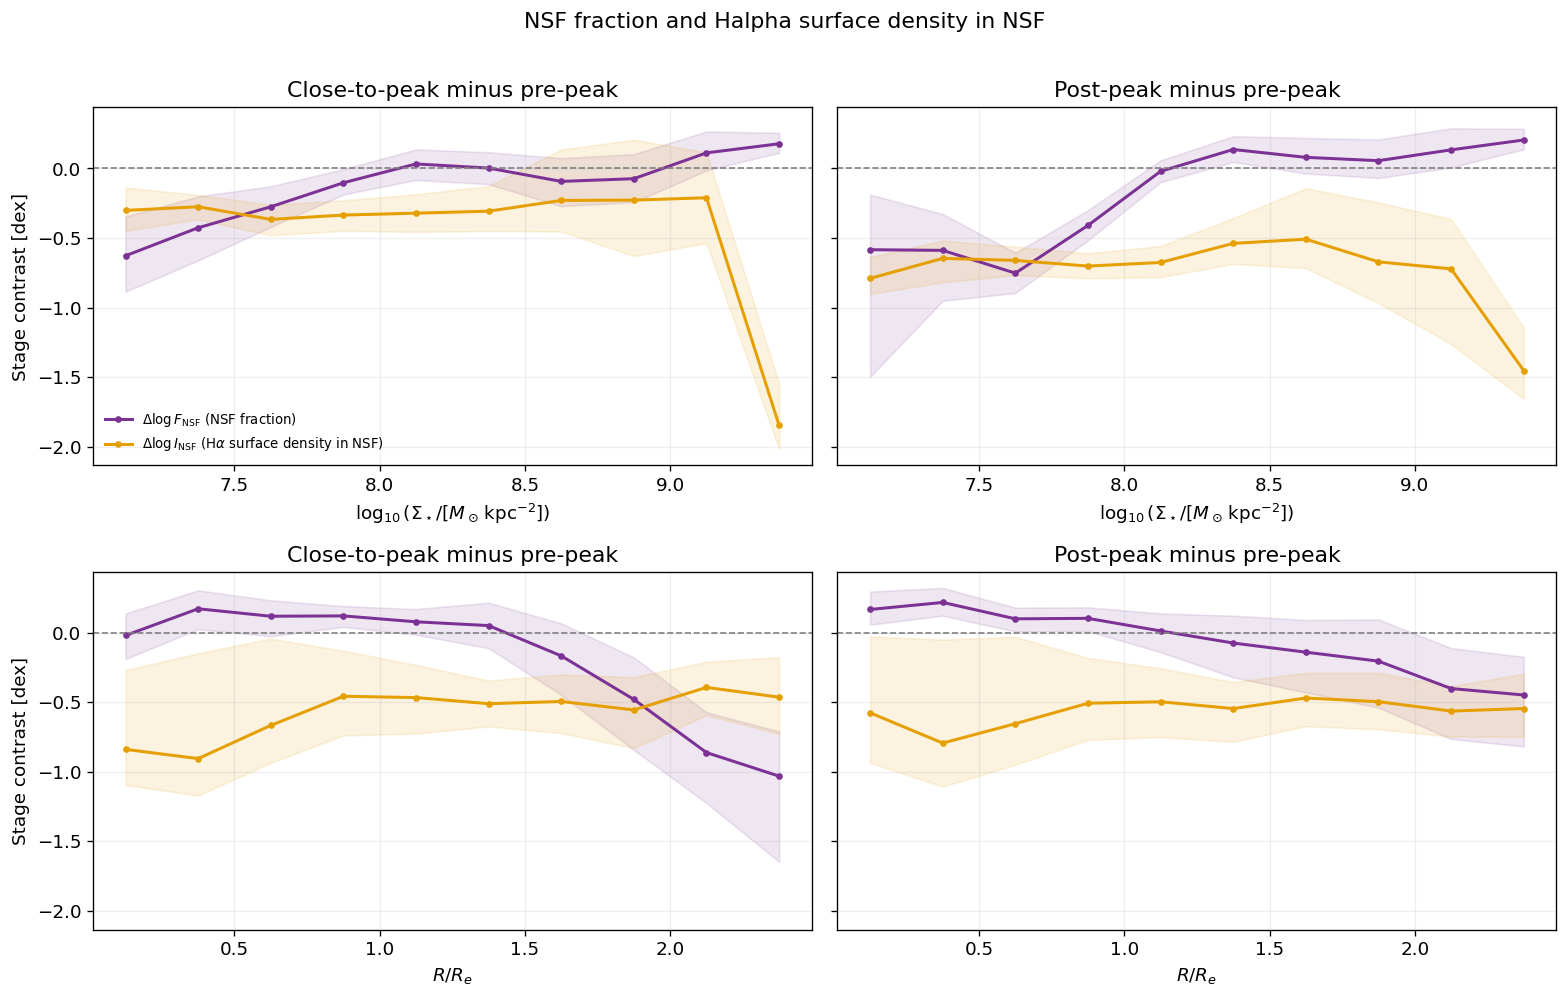

,stage_minus_pre,variable,N_bins_in_fixed_range,median_delta_log_F,median_delta_log_I,N_bins_I_CI_above_zero,N_bins_I_CI_below_zero
0,close-to-peak,log_sigma_star,10,-0.083,-0.304,0,7
1,close-to-peak,radius_re,10,0.016,-0.502,0,10
2,post-peak,log_sigma_star,10,0.018,-0.674,0,10
3,post-peak,radius_re,10,-0.031,-0.545,0,10


,stage,variable,bin_left,bin_right,delta_log_F,delta_log_F_lo,delta_log_F_hi,delta_log_I,delta_log_I_lo,delta_log_I_hi
5,close-to-peak,log_sigma_star,7.00,7.25,-0.628,-0.886,-0.344,-0.302,-0.449,-0.138
6,close-to-peak,log_sigma_star,7.25,7.50,-0.426,-0.662,-0.201,-0.275,-0.366,-0.190
7,close-to-peak,log_sigma_star,7.50,7.75,-0.276,-0.420,-0.128,-0.366,-0.480,-0.261
8,close-to-peak,log_sigma_star,7.75,8.00,-0.103,-0.187,-0.005,-0.335,-0.448,-0.229
9,close-to-peak,log_sigma_star,8.00,8.25,0.033,-0.083,0.137,-0.321,-0.456,-0.186
10,close-to-peak,log_sigma_star,8.25,8.50,0.003,-0.113,0.117,-0.307,-0.450,-0.126
11,close-to-peak,log_sigma_star,8.50,8.75,-0.093,-0.271,0.074,-0.230,-0.453,0.136
12,close-to-peak,log_sigma_star,8.75,9.00,-0.073,-0.243,0.103,-0.227,-0.629,0.207
13,close-to-peak,log_sigma_star,9.00,9.25,0.112,-0.015,0.266,-0.211,-0.537,0.115
14,close-to-peak,log_sigma_star,9.25,9.50,0.178,0.113,0.256,-1.848,-2.018,-1.550


In [13]:
CONTRAST_COLORS = {"F": "#7b3294", "I": "#e69f00"}
CONTRAST_LABELS = {
    "F": r"$\Delta\log F_{\rm NSF}$ (NSF fraction)",
    "I": r"$\Delta\log I_{\rm NSF}$ (H$\alpha$ surface density in NSF)",
}

fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.2), sharex="row", sharey=True)
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, stage in enumerate(("close-to-peak", "post-peak")):
        ax = axes[row_index, col_index]
        sub = NSF_STAGE_CONTRASTS.loc[
            NSF_STAGE_CONTRASTS.stage.eq(stage)
            & NSF_STAGE_CONTRASTS.variable.eq(variable)
            & NSF_STAGE_CONTRASTS.in_fixed_reliable_range
        ].sort_values("center")
        for short in ("F", "I"):
            y = sub[f"delta_log_{short}"].to_numpy(float)
            ylo = sub[f"delta_log_{short}_lo"].to_numpy(float)
            yhi = sub[f"delta_log_{short}_hi"].to_numpy(float)
            ax.plot(
                sub.center, y, color=CONTRAST_COLORS[short], marker="o", ms=3,
                lw=1.8, label=CONTRAST_LABELS[short],
            )
            ax.fill_between(sub.center, ylo, yhi, color=CONTRAST_COLORS[short], alpha=0.12)
        ax.axhline(0, color="0.5", ls="--", lw=1)
        ax.set_title(f"{STAGE_LABELS[stage]} minus pre-peak")
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel("Stage contrast [dex]")
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=8)
fig.suptitle("NSF fraction and Halpha surface density in NSF", y=1.01)
fig.tight_layout()
plt.show()

summary_rows = []
for (stage, variable), group in NSF_STAGE_CONTRASTS.loc[
    NSF_STAGE_CONTRASTS.in_fixed_reliable_range
].groupby(["stage", "variable"], observed=True):
    summary_rows.append({
        "stage_minus_pre": stage,
        "variable": variable,
        "N_bins_in_fixed_range": len(group),
        "median_delta_log_F": float(group.delta_log_F.median()),
        "median_delta_log_I": float(group.delta_log_I.median()),
        "N_bins_I_CI_above_zero": int(group.delta_log_I_lo.gt(0).sum()),
        "N_bins_I_CI_below_zero": int(group.delta_log_I_hi.lt(0).sum()),
    })
NSF_CONTRAST_SUMMARY = pd.DataFrame(summary_rows)
display(NSF_CONTRAST_SUMMARY.round(3))
display(NSF_STAGE_CONTRASTS.loc[
    NSF_STAGE_CONTRASTS.in_fixed_reliable_range,
    [
        "stage", "variable", "bin_left", "bin_right",
        "delta_log_F", "delta_log_F_lo", "delta_log_F_hi",
        "delta_log_I", "delta_log_I_lo", "delta_log_I_hi",
    ],
].sort_values(["variable", "stage", "bin_left"]).round(3))


## 14. Supporting excitation and kinematic contrasts

For each galaxy/bin with at least 20 SF and 20 NSF diagnostic pixels, form

$$
\Delta D_g=\mathrm{median}(D_{\rm NSF})-\mathrm{median}(D_{\rm SF}).
$$

Stage curves are equal-galaxy means and bands are whole-galaxy bootstrap
intervals. [O III]/H$\beta$ traces the high-ionisation excitation response,
whereas the low-ionisation ratios are sensitive to different excitation in NSF
relative to SF; positive dispersion contrast means broader
intrinsic H$\alpha$. These are not independent classifiers: the SF/NSF split
already includes BPT, EW, and dispersion gates.


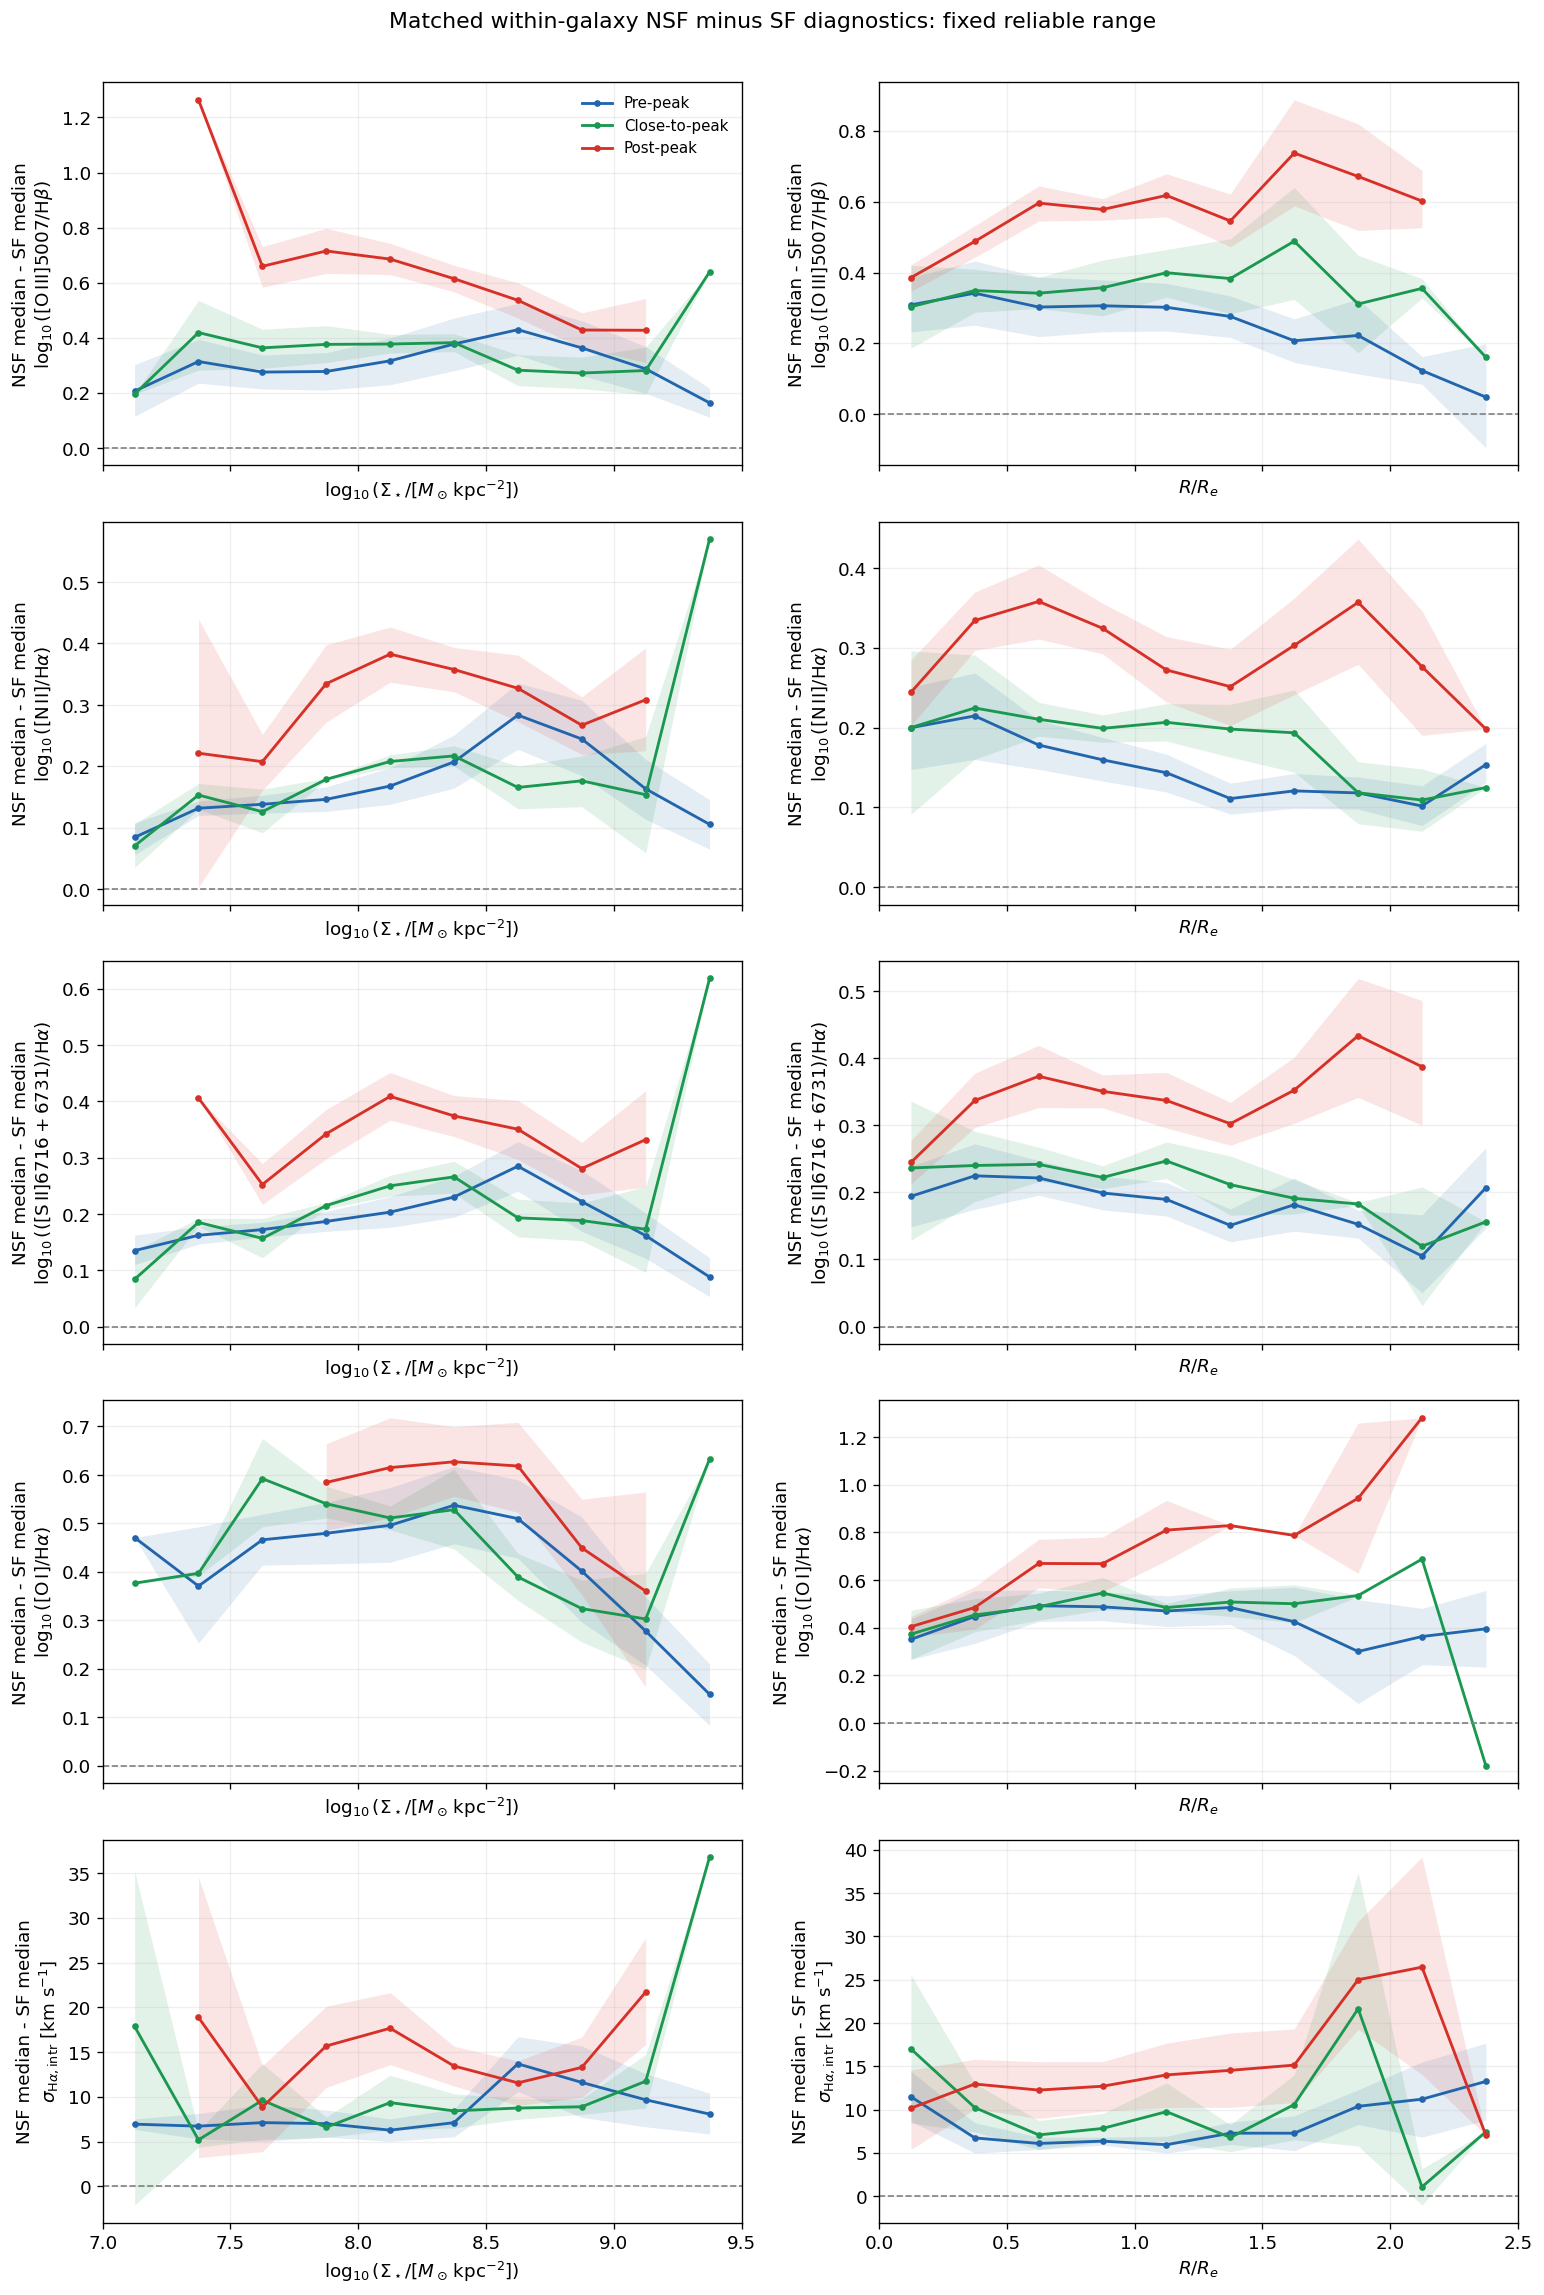

N_bins_with_any_galaxy
diagnostic  stage                                
log_OIII_Hb pre-peak                           27
            close-to-peak                      21
            post-peak                          17
log_NII_Ha  pre-peak                           27
            close-to-peak                      22
            post-peak                          18
log_SII_Ha  pre-peak                           27
            close-to-peak                      21
            post-peak                          17
log_OI_Ha   pre-peak                           26
            close-to-peak                      21
            post-peak                          15
sigma_Ha    pre-peak                           27
            close-to-peak                      22
            post-peak                          18

,diagnostic,stage,variable,N_bins_in_fixed_range,median_NSF_minus_SF,N_bins_CI_above_zero,N_bins_CI_below_zero
0,log_NII_Ha,close-to-peak,log_sigma_star,10,0.171,10,0
1,log_NII_Ha,close-to-peak,radius_re,10,0.199,10,0
2,log_NII_Ha,post-peak,log_sigma_star,10,0.318,8,0
3,log_NII_Ha,post-peak,radius_re,10,0.290,10,0
4,log_NII_Ha,pre-peak,log_sigma_star,10,0.155,10,0
5,log_NII_Ha,pre-peak,radius_re,10,0.149,10,0
6,log_OIII_Hb,close-to-peak,log_sigma_star,10,0.370,10,0
7,log_OIII_Hb,close-to-peak,radius_re,10,0.352,10,0
8,log_OIII_Hb,post-peak,log_sigma_star,10,0.637,8,0
9,log_OIII_Hb,post-peak,radius_re,10,0.596,9,0


In [14]:
contrast_rows = []
id_columns = ["GALID", "stage", "variable", "bin_left", "bin_right", "center"]
sf_rows = HALPHA_BY_GALAXY_BIN.loc[HALPHA_BY_GALAXY_BIN.category.eq("SF")].set_index(id_columns)
nsf_rows = HALPHA_BY_GALAXY_BIN.loc[HALPHA_BY_GALAXY_BIN.category.eq("NSF")].set_index(id_columns)
for diagnostic in DIAGNOSTIC_ORDER:
    joined = sf_rows[[f"N_{diagnostic}", f"median_{diagnostic}"]].join(
        nsf_rows[[f"N_{diagnostic}", f"median_{diagnostic}"]],
        lsuffix="_SF", rsuffix="_NSF", how="inner", validate="one_to_one",
    ).reset_index()
    supported = (
        joined[f"N_{diagnostic}_SF"].ge(DIAGNOSTIC_MIN_PIXELS_PER_BIN)
        & joined[f"N_{diagnostic}_NSF"].ge(DIAGNOSTIC_MIN_PIXELS_PER_BIN)
    )
    for row in joined.loc[supported].itertuples(index=False):
        contrast_rows.append({
            "GALID": row.GALID,
            "stage": row.stage,
            "variable": row.variable,
            "bin_left": row.bin_left,
            "bin_right": row.bin_right,
            "center": row.center,
            "diagnostic": diagnostic,
            "delta_NSF_minus_SF": (
                getattr(row, f"median_{diagnostic}_NSF")
                - getattr(row, f"median_{diagnostic}_SF")
            ),
        })

DIAGNOSTIC_CONTRAST_BY_GALAXY = pd.DataFrame(contrast_rows)
diag_profile_rows = []
for stage_index, stage in enumerate(STAGE_ORDER):
    stage_galaxies = sample.loc[sample.stage.eq(stage), "GALID"].sort_values().to_numpy()
    for variable_index, variable in enumerate(("log_sigma_star", "radius_re")):
        for diag_index, diagnostic in enumerate(DIAGNOSTIC_ORDER):
            for bin_index, (lo, hi) in enumerate(zip(
                COMMON_EDGES[variable][:-1], COMMON_EDGES[variable][1:]
            )):
                group = DIAGNOSTIC_CONTRAST_BY_GALAXY.loc[
                    DIAGNOSTIC_CONTRAST_BY_GALAXY.stage.eq(stage)
                    & DIAGNOSTIC_CONTRAST_BY_GALAXY.variable.eq(variable)
                    & DIAGNOSTIC_CONTRAST_BY_GALAXY.diagnostic.eq(diagnostic)
                    & np.isclose(DIAGNOSTIC_CONTRAST_BY_GALAXY.bin_left, lo)
                ].set_index("GALID").reindex(stage_galaxies)
                values = group.delta_NSF_minus_SF.to_numpy(float)
                central = float(np.nanmean(values)) if np.isfinite(values).any() else np.nan
                n_support = int(np.isfinite(values).sum())
                seed = (
                    RANDOM_SEED + 4_000_000 + 100_000 * stage_index
                    + 10_000 * variable_index + 1_000 * diag_index + bin_index
                )
                rng = np.random.default_rng(seed)
                indices = rng.integers(0, len(stage_galaxies), size=(N_BOOTSTRAP, len(stage_galaxies)))
                sample_values = values[indices]
                counts = np.isfinite(sample_values).sum(axis=1)
                boot = np.divide(
                    np.nansum(sample_values, axis=1), counts,
                    out=np.full(N_BOOTSTRAP, np.nan), where=counts > 0,
                )
                low, high = finite_percentiles(boot)
                diag_profile_rows.append({
                    "stage": stage, "variable": variable, "diagnostic": diagnostic,
                    "bin_left": float(lo), "bin_right": float(hi),
                    "center": float((lo + hi) / 2),
                    "N_gal_support": n_support,
                    "fraction_stage_support": n_support / len(stage_galaxies),
                    "delta_NSF_minus_SF": central,
                    "delta_lo": low, "delta_hi": high,
                })

DIAGNOSTIC_CONTRAST_PROFILES = pd.DataFrame(diag_profile_rows)

def plot_diagnostic_contrasts():
    fig, axes = plt.subplots(
        len(DIAGNOSTIC_ORDER), 2,
        figsize=(13.0, 3.8 * len(DIAGNOSTIC_ORDER)), sharex="col",
    )
    for row_index, diagnostic in enumerate(DIAGNOSTIC_ORDER):
        for col_index, variable in enumerate(("log_sigma_star", "radius_re")):
            ax = axes[row_index, col_index]
            lo, hi = COMMON_RELIABLE_RANGES[("NSF", variable)]
            for stage in STAGE_ORDER:
                sub = DIAGNOSTIC_CONTRAST_PROFILES.loc[
                    DIAGNOSTIC_CONTRAST_PROFILES.stage.eq(stage)
                    & DIAGNOSTIC_CONTRAST_PROFILES.variable.eq(variable)
                    & DIAGNOSTIC_CONTRAST_PROFILES.diagnostic.eq(diagnostic)
                ].sort_values("center")
                in_range = (
                    sub.center.ge(lo).to_numpy(bool)
                    & sub.center.lt(hi).to_numpy(bool)
                    if np.isfinite(lo) and np.isfinite(hi)
                    else np.zeros(len(sub), dtype=bool)
                )
                shown = in_range
                ax.plot(
                    sub.center.where(shown),
                    sub.delta_NSF_minus_SF.where(shown),
                    color=STAGE_COLORS[stage], marker="o", ms=3, lw=1.7,
                    alpha=1.0, label=STAGE_LABELS[stage],
                )
                ax.fill_between(
                    sub.center, sub.delta_lo, sub.delta_hi, where=shown,
                    color=STAGE_COLORS[stage], alpha=0.12, linewidth=0,
                )
            if np.isfinite(lo) and np.isfinite(hi):
                ax.set_xlim(lo, hi)
            ax.axhline(0, color="0.5", ls="--", lw=1)
            ax.set_xlabel(VARIABLE_LABELS[variable])
            ax.set_ylabel("NSF median - SF median\n" + DIAGNOSTIC_LABELS[diagnostic])
            ax.grid(alpha=0.2)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle(
        "Matched within-galaxy NSF minus SF diagnostics: fixed reliable range",
        y=1.005,
    )
    fig.tight_layout()
    plt.show()


plot_diagnostic_contrasts()

display(DIAGNOSTIC_CONTRAST_PROFILES.groupby(["diagnostic", "stage"], observed=True).agg(
    N_bins_with_any_galaxy=("N_gal_support", lambda values: int((values > 0).sum())),
).reindex(pd.MultiIndex.from_product([DIAGNOSTIC_ORDER, STAGE_ORDER], names=["diagnostic", "stage"])))

diagnostic_summary_rows = []
for (diagnostic, stage, variable), group in DIAGNOSTIC_CONTRAST_PROFILES.groupby(
    ["diagnostic", "stage", "variable"], observed=True
):
    lo, hi = COMMON_RELIABLE_RANGES[("NSF", variable)]
    use = group.center.ge(lo) & group.center.lt(hi)
    selected = group.loc[use]
    diagnostic_summary_rows.append({
        "diagnostic": diagnostic,
        "stage": stage,
        "variable": variable,
        "N_bins_in_fixed_range": len(selected),
        "median_NSF_minus_SF": (
            float(selected.delta_NSF_minus_SF.median()) if len(selected) else np.nan
        ),
        "N_bins_CI_above_zero": int(selected.delta_lo.gt(0).sum()),
        "N_bins_CI_below_zero": int(selected.delta_hi.lt(0).sum()),
    })
DIAGNOSTIC_SUMMARY = pd.DataFrame(diagnostic_summary_rows)
display(DIAGNOSTIC_SUMMARY.round(3))


### Reading the diagnostic contrasts

The diagnostic figure uses every available bin inside the fixed reliable range.

- A positive NSF--SF contrast confirms that NSF occupies a different
  excitation/kinematic regime, but is partly expected by construction.
- The useful environmental evidence is whether that contrast itself changes
  coherently across stages and at fixed $\Sigma_\star$ or $R/R_e$.
- [O III]/H$\beta$ provides a high-ionisation counterpart to the
  low-ionisation-line ratios. [O I] is typically the most support-limited
  diagnostic; do not interpolate
  through bins that fail the displayed galaxy-support rule.
- None of these ratios separates DIG, shocks, AGN, HOLMES, or outflows uniquely.


## 15. Individual-galaxy sensitivity check

Thin curves show each galaxy's median corrected H$\alpha$ intensity using the
fixed project colour table; line style marks stage. Thick curves are the
stage-level median of galaxy medians. This checks whether a stage curve is a
population tendency or a small-number feature.


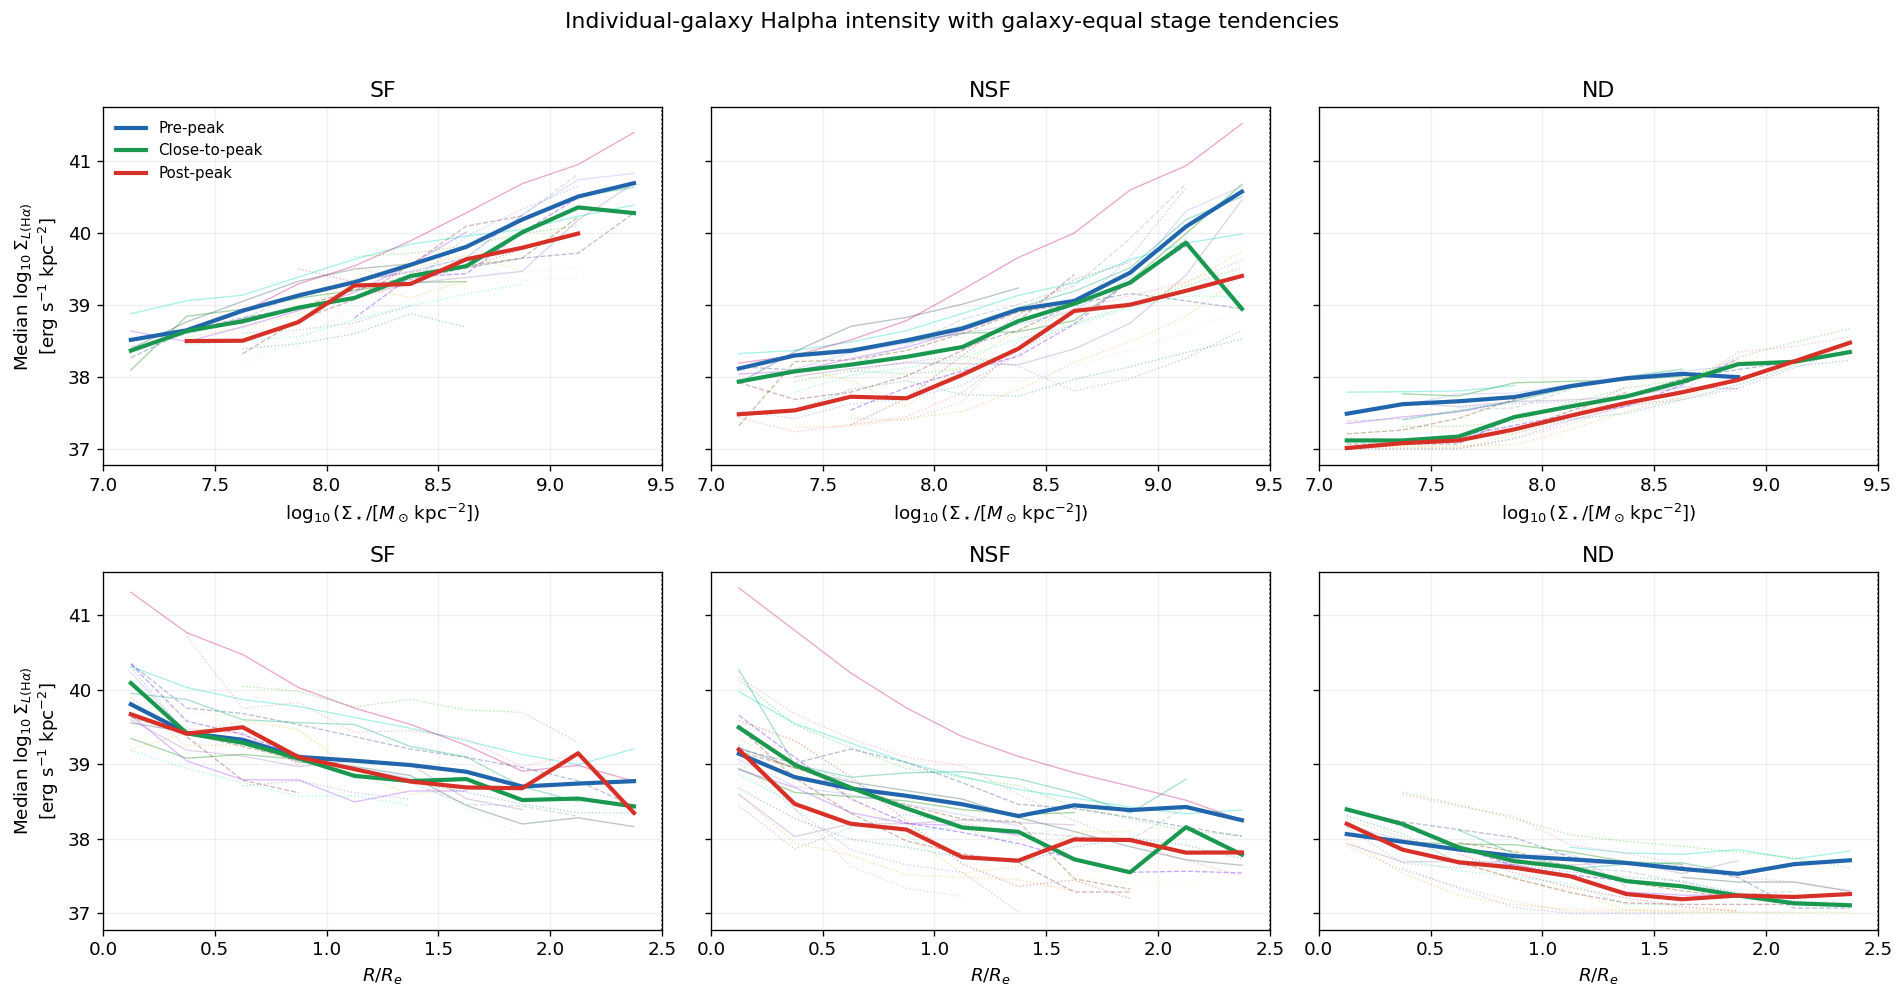

In [15]:
STAGE_LINESTYLES = {"pre-peak": "-", "close-to-peak": "--", "post-peak": ":"}
fig, axes = plt.subplots(2, 3, figsize=(16.0, 8.2), sharex="row", sharey="row")
for row_index, variable in enumerate(("log_sigma_star", "radius_re")):
    for col_index, category in enumerate(CATEGORY_ORDER):
        ax = axes[row_index, col_index]
        lo, hi = COMMON_RELIABLE_RANGES[(category, variable)]
        individual = HALPHA_BY_GALAXY_BIN.loc[
            HALPHA_BY_GALAXY_BIN.variable.eq(variable)
            & HALPHA_BY_GALAXY_BIN.category.eq(category)
            & HALPHA_BY_GALAXY_BIN.category_support
            & HALPHA_BY_GALAXY_BIN.center.ge(lo)
            & HALPHA_BY_GALAXY_BIN.center.lt(hi)
        ]
        for (galid, stage), group in individual.groupby(["GALID", "stage"], observed=True):
            ax.plot(
                group.center, group.median_log_lha_within_category,
                color=GALAXY_COLORS[galid], ls=STAGE_LINESTYLES[stage],
                lw=0.8, alpha=0.35,
            )
        for stage in STAGE_ORDER:
            stage_profile = HALPHA_BOOTSTRAP.loc[
                HALPHA_BOOTSTRAP.stage.eq(stage)
                & HALPHA_BOOTSTRAP.variable.eq(variable)
                & HALPHA_BOOTSTRAP.category.eq(category)
                & HALPHA_BOOTSTRAP.in_fixed_reliable_range
            ].sort_values("center")
            ax.plot(
                stage_profile.center,
                stage_profile.typical_median_log_intensity,
                color=STAGE_COLORS[stage], lw=2.5,
                label=STAGE_LABELS[stage],
            )
        if np.isfinite(lo):
            ax.axvline(lo, color="0.25", ls=":", lw=1)
            ax.axvline(hi, color="0.25", ls=":", lw=1)
            ax.set_xlim(lo, hi)
        ax.set_title(category)
        ax.set_xlabel(VARIABLE_LABELS[variable])
        if col_index == 0:
            ax.set_ylabel(r"Median $\log_{10}\Sigma_{L(\mathrm{H}\alpha)}$" + "\n" + r"[erg s$^{-1}$ kpc$^{-2}$]")
        ax.grid(alpha=0.2)
axes[0, 0].legend(frameon=False, fontsize=9)
fig.suptitle("Individual-galaxy Halpha intensity with galaxy-equal stage tendencies", y=1.01)
fig.tight_layout()
plt.show()


## 16. Numerical verification and output-driven synthesis

The checks below validate the live sample, strict cut, category partition,
provenance consistency, bootstrap centring, finite units, and support ranges.
Passing bookkeeping does not establish a
physical mechanism; the synthesis reports what the measured profiles support.


In [16]:
verification = {}

verification["all_three_stages_present"] = set(sample.stage) == set(STAGE_ORDER)
verification["strict_snr_cut"] = bool(all_retained_strict)
verification["category_accounting"] = bool(
    HALPHA_BY_GALAXY_BIN.groupby(
        ["GALID", "variable", "bin_left"], observed=True
    ).N_category.sum().equals(
        HALPHA_BY_GALAXY_BIN.groupby(
            ["GALID", "variable", "bin_left"], observed=True
        ).N_usable.first()
    )
)
for column in ("CUT_SN", "NOISE", "DIST_MPC", "SFRCOEF", "SFRIMF", "DUSTLAW", "BPTMODE"):
    verification[f"provenance_constant_{column}"] = HALPHA_PROVENANCE[column].nunique(dropna=False) == 1

central_columns = [
    "stage", "variable", "category", "bin_left",
    "occupancy", "mean_intensity",
    "typical_median_log_intensity",
]
central_compare = HALPHA_BOOTSTRAP[central_columns].merge(
    STAGE_HALPHA_PROFILES[central_columns],
    on=["stage", "variable", "category", "bin_left"],
    suffixes=("_boot", "_direct"), validate="one_to_one",
)
for metric in (
    "occupancy", "mean_intensity",
    "typical_median_log_intensity",
):
    verification[f"bootstrap_central_matches_{metric}"] = bool(np.allclose(
        central_compare[f"{metric}_boot"], central_compare[f"{metric}_direct"],
        equal_nan=True, rtol=1e-12, atol=0,
    ))

verification["fixed_ranges_are_exact"] = all(
    COMMON_RELIABLE_RANGES[(category, variable)] == FIXED_RELIABLE_RANGES[variable]
    for category in CATEGORY_ORDER
    for variable in ("log_sigma_star", "radius_re")
)
verification["finite_positive_measured_Halpha"] = bool(
    np.isfinite(HALPHA_BY_GALAXY_BIN.loc[
        HALPHA_BY_GALAXY_BIN.category.isin(["SF", "NSF"])
        & HALPHA_BY_GALAXY_BIN.N_category.gt(0),
        "lha_mean_within_category",
    ]).all()
    and HALPHA_BY_GALAXY_BIN.loc[
        HALPHA_BY_GALAXY_BIN.category.isin(["SF", "NSF"])
        & HALPHA_BY_GALAXY_BIN.N_category.gt(0),
        "lha_mean_within_category",
    ].gt(0).all()
)
eligible_j = HALPHA_BY_GALAXY_BIN.eligible_usable
positive_category_j = eligible_j & HALPHA_BY_GALAXY_BIN.N_category.gt(0)
zero_category_j = eligible_j & HALPHA_BY_GALAXY_BIN.N_category.eq(0)
verification["j_matches_per_galaxy_F_times_I"] = bool(np.allclose(
    HALPHA_BY_GALAXY_BIN.loc[positive_category_j, "j_lha_per_usable"],
    HALPHA_BY_GALAXY_BIN.loc[positive_category_j, "f_category"]
    * HALPHA_BY_GALAXY_BIN.loc[positive_category_j, "lha_mean_within_category"],
    rtol=1e-12, atol=0,
))
verification["zero_occupancy_contributes_zero_j"] = bool(
    HALPHA_BY_GALAXY_BIN.loc[zero_category_j, "j_lha_per_usable"].eq(0).all()
)
j_central_compare = J_HALPHA_BOOTSTRAP[[
    "stage", "variable", "category", "bin_left", "j_mean",
]].merge(
    J_HALPHA_PROFILES[[
        "stage", "variable", "category", "bin_left", "j_mean",
    ]],
    on=["stage", "variable", "category", "bin_left"],
    suffixes=("_boot", "_direct"), validate="one_to_one",
)
verification["bootstrap_central_matches_j_mean"] = bool(np.allclose(
    j_central_compare.j_mean_boot, j_central_compare.j_mean_direct,
    equal_nan=True, rtol=1e-12, atol=0,
))
budget_q = HALPHA_Q_BY_GALAXY_BIN[list(Q_BUDGET_METRICS)]
detected_q = HALPHA_Q_BY_GALAXY_BIN[list(Q_DETECTED_METRICS)]
budget_supported = budget_q.notna().all(axis=1)
detected_supported = detected_q.notna().all(axis=1)
verification["q_budget_closes_per_galaxy"] = bool(np.allclose(
    budget_q.loc[budget_supported].sum(axis=1), 1.0, rtol=0, atol=1e-12,
))
verification["q_detected_closes_per_galaxy"] = bool(np.allclose(
    detected_q.loc[detected_supported].sum(axis=1), 1.0, rtol=0, atol=1e-12,
))
all_q_values = HALPHA_Q_BY_GALAXY_BIN[list(Q_METRICS)].to_numpy(float)
finite_q_values = all_q_values[np.isfinite(all_q_values)]
verification["all_q_values_in_unit_interval"] = bool(
    np.all((finite_q_values >= 0) & (finite_q_values <= 1))
)
q_central_compare = HALPHA_Q_BOOTSTRAP[[
    "stage", "variable", "bin_left", *Q_METRICS,
]].merge(
    HALPHA_Q_PROFILES[[
        "stage", "variable", "bin_left", *Q_METRICS,
    ]],
    on=["stage", "variable", "bin_left"],
    suffixes=("_boot", "_direct"), validate="one_to_one",
)
verification["bootstrap_central_matches_all_q_means"] = all(
    np.allclose(
        q_central_compare[f"{metric}_boot"],
        q_central_compare[f"{metric}_direct"],
        equal_nan=True, rtol=1e-12, atol=0,
    )
    for metric in Q_METRICS
)
verification["bpt_line_set_is_exact"] = set(BPT_LINE_BOOTSTRAP.line) == set(
    BPT_LINE_ORDER
)
verification["bpt_common_support_excludes_nd"] = bool(
    ~HALPHA_BY_GALAXY_BIN.loc[
        HALPHA_BY_GALAXY_BIN.category.eq("ND"), "bpt_common_support"
    ].any()
)
supported_bpt = HALPHA_BY_GALAXY_BIN.bpt_common_support
bpt_line_columns = [
    f"mean_{line}_within_category" for line in BPT_LINE_ORDER
]
bpt_values = HALPHA_BY_GALAXY_BIN.loc[supported_bpt, bpt_line_columns].to_numpy(float)
verification["finite_positive_bpt_line_means"] = bool(
    np.isfinite(bpt_values).all() and np.all(bpt_values > 0)
)
bpt_central_compare = BPT_LINE_BOOTSTRAP[[
    "stage", "variable", "category", "line", "bin_left",
    "mean_line_surface",
]].merge(
    BPT_LINE_PROFILES[[
        "stage", "variable", "category", "line", "bin_left",
        "mean_line_surface",
    ]],
    on=["stage", "variable", "category", "line", "bin_left"],
    suffixes=("_boot", "_direct"), validate="one_to_one",
)
verification["bootstrap_central_matches_bpt_line_means"] = bool(np.allclose(
    bpt_central_compare.mean_line_surface_boot,
    bpt_central_compare.mean_line_surface_direct,
    equal_nan=True, rtol=1e-12, atol=0,
))
forbidden_contrasts = BPT_LINE_STAGE_CONTRASTS.loc[
    BPT_LINE_STAGE_CONTRASTS.line.ne("HA6562")
]
ha_contrasts = BPT_LINE_STAGE_CONTRASTS.loc[
    BPT_LINE_STAGE_CONTRASTS.line.eq("HA6562"),
    ["stage", "variable", "category", "bin_left", "delta_log_I_line"],
].rename(columns={"delta_log_I_line": "delta_log_I_Ha_matched"})
ratio_identity = forbidden_contrasts.merge(
    ha_contrasts,
    on=["stage", "variable", "category", "bin_left"],
    how="left", validate="many_to_one",
)
verification["bpt_ratio_change_matches_line_minus_balmer_reference"] = bool(np.allclose(
    ratio_identity.delta_log_bpt_ratio,
    ratio_identity.delta_log_I_line - ratio_identity.delta_log_I_Ha_matched,
    equal_nan=True, rtol=1e-12, atol=0,
))

VERIFICATION_TABLE = pd.Series(verification, name="passed").to_frame()
display(VERIFICATION_TABLE)
if not VERIFICATION_TABLE.passed.all():
    raise AssertionError("Halpha category verification failed")

display(HALPHA_PROVENANCE.drop(columns=["SFRNOTE"]).drop_duplicates().reset_index(drop=True))
display(COMMON_RELIABLE_RANGE_TABLE)
display(NSF_CONTRAST_SUMMARY.round(3))
print("HALPHA_CATEGORY_VERIFICATION_OK")


,passed
all_three_stages_present,True
strict_snr_cut,True
category_accounting,True
provenance_constant_CUT_SN,True
provenance_constant_NOISE,True
provenance_constant_DIST_MPC,True
provenance_constant_SFRCOEF,True
provenance_constant_SFRIMF,True
provenance_constant_DUSTLAW,True
provenance_constant_BPTMODE,True


,GALID,CUT_SN,NOISE,DIST_MPC,DISTREF,SFRCOEF,SFRIMF,DUSTLAW,BPTMODE
0,NGC4298,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
1,NGC4424,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
2,NGC4501,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
3,NGC4654,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
4,NGC4694,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
5,IC3392,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
6,NGC4064,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
7,NGC4293,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
8,NGC4380,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both
9,NGC4394,3,20,16.5,Fixed MAUVE paper distance scale,4.983582e-42,Chabrier,calzetti,both


,category,variable,fixed_min,fixed_max
0,SF,log_sigma_star,7.0,9.5
1,SF,radius_re,0.0,2.5
2,NSF,log_sigma_star,7.0,9.5
3,NSF,radius_re,0.0,2.5
4,ND,log_sigma_star,7.0,9.5
5,ND,radius_re,0.0,2.5


,stage_minus_pre,variable,N_bins_in_fixed_range,median_delta_log_F,median_delta_log_I,N_bins_I_CI_above_zero,N_bins_I_CI_below_zero
0,close-to-peak,log_sigma_star,10,-0.083,-0.304,0,7
1,close-to-peak,radius_re,10,0.016,-0.502,0,10
2,post-peak,log_sigma_star,10,0.018,-0.674,0,10
3,post-peak,radius_re,10,-0.031,-0.545,0,10


HALPHA_CATEGORY_VERIFICATION_OK


In [17]:
from IPython.display import Markdown


def axis_name(variable):
    return "log stellar-mass surface density" if variable == "log_sigma_star" else "R/Re"


lines = [
    "## Reading the measured result",
    "",
    "The fixed-range NSF fraction and Halpha surface-density contrasts in NSF are the central result:",
    "",
]
for row in NSF_CONTRAST_SUMMARY.itertuples(index=False):
    stage_label = STAGE_LABELS[row.stage_minus_pre]
    lines.append(
        f"- **{stage_label} minus pre-peak along {axis_name(row.variable)}:** "
        f"median across {row.N_bins_in_fixed_range} fixed-range bins "
        f"$\\Delta\\log F_{{\\rm NSF}}={row.median_delta_log_F:+.2f}$ dex and "
        f"$\\Delta\\log I_{{\\rm NSF}}={row.median_delta_log_I:+.2f}$ dex. "
        f"The per-bin bootstrap interval for $\\Delta\\log I_{{\\rm NSF}}$ is "
        f"entirely above zero in {row.N_bins_I_CI_above_zero} bins and entirely "
        f"below zero in {row.N_bins_I_CI_below_zero} bins."
    )

lines.extend([
    "",
    "Interpretation must follow the plotted bin-by-bin intervals, not only these medians. "
    "A near-zero Halpha surface-density change in NSF with a changing NSF fraction supports an "
    "area-redistribution description; a coherently positive intensity change "
    "supports added/enhanced Halpha emission. The diagnostic contrasts can strengthen "
    "that phenomenology but cannot identify DIG, shocks, AGN, HOLMES, or outflows uniquely.",
])

lines.extend([
    "",
    "### Supporting diagnostic pattern",
    "",
])
for diagnostic in DIAGNOSTIC_ORDER:
    for variable in ("log_sigma_star", "radius_re"):
        sub = DIAGNOSTIC_SUMMARY.loc[
            DIAGNOSTIC_SUMMARY.diagnostic.eq(diagnostic)
            & DIAGNOSTIC_SUMMARY.variable.eq(variable)
        ].set_index("stage").reindex(STAGE_ORDER)
        values = ", ".join(
            f"{STAGE_LABELS[stage]} {sub.loc[stage, 'median_NSF_minus_SF']:+.2f}"
            for stage in STAGE_ORDER
            if np.isfinite(sub.loc[stage, "median_NSF_minus_SF"])
        )
        lines.append(
            f"- Along {axis_name(variable)}, the median fixed-range NSF-SF "
            f"contrast in {DIAGNOSTIC_LABELS[diagnostic]} is: {values}."
        )
lines.extend([
    "",
    "These positive NSF-SF excitation/dispersion offsets show that the categories "
    "differ observationally. [O III]/Hbeta provides the high-ionisation view, "
    "while the low-ionisation-line offsets provide a complementary view. These "
    "offsets are supplementary evidence only; the ratios do not identify a unique "
    "ionisation source.",
])
display(Markdown("\n".join(lines)))


## Reading the measured result

The fixed-range NSF fraction and Halpha surface-density contrasts in NSF are the central result:

- **Close-to-peak minus pre-peak along log stellar-mass surface density:** median across 10 fixed-range bins $\Delta\log F_{\rm NSF}=-0.08$ dex and $\Delta\log I_{\rm NSF}=-0.30$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm NSF}$ is entirely above zero in 0 bins and entirely below zero in 7 bins.
- **Close-to-peak minus pre-peak along R/Re:** median across 10 fixed-range bins $\Delta\log F_{\rm NSF}=+0.02$ dex and $\Delta\log I_{\rm NSF}=-0.50$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm NSF}$ is entirely above zero in 0 bins and entirely below zero in 10 bins.
- **Post-peak minus pre-peak along log stellar-mass surface density:** median across 10 fixed-range bins $\Delta\log F_{\rm NSF}=+0.02$ dex and $\Delta\log I_{\rm NSF}=-0.67$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm NSF}$ is entirely above zero in 0 bins and entirely below zero in 10 bins.
- **Post-peak minus pre-peak along R/Re:** median across 10 fixed-range bins $\Delta\log F_{\rm NSF}=-0.03$ dex and $\Delta\log I_{\rm NSF}=-0.55$ dex. The per-bin bootstrap interval for $\Delta\log I_{\rm NSF}$ is entirely above zero in 0 bins and entirely below zero in 10 bins.

Interpretation must follow the plotted bin-by-bin intervals, not only these medians. A near-zero Halpha surface-density change in NSF with a changing NSF fraction supports an area-redistribution description; a coherently positive intensity change supports added/enhanced Halpha emission. The diagnostic contrasts can strengthen that phenomenology but cannot identify DIG, shocks, AGN, HOLMES, or outflows uniquely.

### Supporting diagnostic pattern

- Along log stellar-mass surface density, the median fixed-range NSF-SF contrast in $\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)$ is: Pre-peak +0.30, Close-to-peak +0.37, Post-peak +0.64.
- Along R/Re, the median fixed-range NSF-SF contrast in $\log_{10}([\mathrm{O\,III}]5007/\mathrm{H}\beta)$ is: Pre-peak +0.29, Close-to-peak +0.35, Post-peak +0.60.
- Along log stellar-mass surface density, the median fixed-range NSF-SF contrast in $\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$ is: Pre-peak +0.15, Close-to-peak +0.17, Post-peak +0.32.
- Along R/Re, the median fixed-range NSF-SF contrast in $\log_{10}([\mathrm{N\,II}]/\mathrm{H}\alpha)$ is: Pre-peak +0.15, Close-to-peak +0.20, Post-peak +0.29.
- Along log stellar-mass surface density, the median fixed-range NSF-SF contrast in $\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$ is: Pre-peak +0.18, Close-to-peak +0.19, Post-peak +0.35.
- Along R/Re, the median fixed-range NSF-SF contrast in $\log_{10}(([\mathrm{S\,II}]6716+6731)/\mathrm{H}\alpha)$ is: Pre-peak +0.19, Close-to-peak +0.22, Post-peak +0.35.
- Along log stellar-mass surface density, the median fixed-range NSF-SF contrast in $\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$ is: Pre-peak +0.47, Close-to-peak +0.45, Post-peak +0.60.
- Along R/Re, the median fixed-range NSF-SF contrast in $\log_{10}([\mathrm{O\,I}]/\mathrm{H}\alpha)$ is: Pre-peak +0.44, Close-to-peak +0.49, Post-peak +0.79.
- Along log stellar-mass surface density, the median fixed-range NSF-SF contrast in $\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$] is: Pre-peak +7.12, Close-to-peak +9.12, Post-peak +14.56.
- Along R/Re, the median fixed-range NSF-SF contrast in $\sigma_{\mathrm{H}\alpha,\mathrm{intr}}$ [km s$^{-1}$] is: Pre-peak +7.26, Close-to-peak +8.78, Post-peak +13.47.

These positive NSF-SF excitation/dispersion offsets show that the categories differ observationally. [O III]/Hbeta provides the high-ionisation view, while the low-ionisation-line offsets provide a complementary view. These offsets are supplementary evidence only; the ratios do not identify a unique ionisation source.